In [198]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import date2num, DateFormatter
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, ListedColormap, TwoSlopeNorm, LogNorm
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import numpy as np
import glob
import datetime
import pytz
%matplotlib inline
n = 20
colors = plt.cm.turbo(np.linspace(0,1,n))
from datetime import timedelta

import metpy.calc as calc
from metpy.units import units
style = "/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle"
import datetime
plt.style.use(style)
import matplotlib
import matplotlib.dates as md
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12)
from matplotlib.ticker import MultipleLocator
import matplotlib.gridspec as gridspec
import scipy.stats as stats
# import plotly.express as px

Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 15 ("xtick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 16 ("ytick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 27 ('axes.edgecolor:222222')


### Import styles and colors

In [199]:
from palettable.cartocolors.qualitative import Prism_8
from palettable.cartocolors.qualitative import Safe_10
from palettable.matplotlib import Viridis_10
from palettable.colorbrewer.diverging import PRGn_4
from palettable.cmocean.sequential import Phase_10
from palettable.cmocean.sequential import Deep_10
from palettable.cmocean.sequential import Speed_10
from palettable.cmocean.sequential import Deep_8
from palettable.lightbartlein.diverging import RedYellowBlue_10_r
from palettable.lightbartlein.diverging import BlueDarkRed12_10
from palettable.mycarta import LinearL_10
from palettable.cmocean.sequential import Tempo_10_r
from palettable.cmocean.sequential import Haline_10
from palettable.cmocean.sequential import Ice_10_r
from palettable.colorbrewer.sequential import YlGnBu_9_r
from palettable.colorbrewer.sequential import YlGnBu_9
from palettable.cmocean.sequential import Dense_10
from palettable.colorbrewer.sequential import GnBu_9_r
from palettable.colorbrewer.sequential import YlGn_9
from palettable.colorbrewer.sequential import GnBu_9_r
from palettable.colorbrewer.diverging import BrBG_11
from palettable.colorbrewer.diverging import RdBu_10_r
from palettable.colorbrewer.sequential import Blues_9_r
from palettable.cartocolors.sequential import Teal_7_r

cluster_c = PRGn_4.mpl_colors
cluster_colors = cluster_c[2], cluster_c[0], cluster_c[3], cluster_c[1]
cluster_colors2 = [cluster_colors[0], cluster_colors[2], cluster_colors[3], cluster_colors[1]] 
cluster_cmap = mcolors.LinearSegmentedColormap.from_list('ClusterCmap',colors = cluster_colors)
cluster_cmap2 = mcolors.LinearSegmentedColormap.from_list('ClusterCmap2',colors = cluster_colors2)
YlGnBu_r2_colors = YlGnBu_9_r.mpl_colors
YGB_r3 = [YlGnBu_r2_colors[i] for i in range(0,7)]
YGB_cmap = mcolors.LinearSegmentedColormap.from_list('YGBCmap',colors = YGB_r3)

YlGnBu_colors = YlGnBu_9.mpl_colors
YGB = [YlGnBu_colors[i] for i in range(2,9)]
YGB_cmap_r = mcolors.LinearSegmentedColormap.from_list('YGBCmap_r',colors = YGB)
YGB = [YlGnBu_colors[i] for i in range(1,8)]
YGB_cmap_r2 = mcolors.LinearSegmentedColormap.from_list('YGBCmap_r',colors = YGB)

GB_r2_colors = GnBu_9_r.mpl_colors
GB_r3 = [GB_r2_colors[i] for i in range(0,7)]
GB_cmap = mcolors.LinearSegmentedColormap.from_list('GBCmap',colors = GB_r3)

BrBu_colors = BrBG_11.mpl_colors

BrBu_deep = [BrBu_colors[i] for i in range(0,4)]
BrBu_deep.append(BrBu_colors[5])
BrBu_deep.extend(BrBu_colors[i] for i in range(7,11))
BrBu_deep_r = BrBu_deep[::-1]
# print(BrBu_deep)
BrBu_cmap = mcolors.LinearSegmentedColormap.from_list('BrBuCmap',colors = BrBu_deep)
BrBu_cmap_r = mcolors.LinearSegmentedColormap.from_list('BrBu_rCmap',colors = BrBu_deep_r)
viridis = Viridis_10.mpl_colors
Phase10 = Phase_10.mpl_colormap
Deep10 = Deep_10.mpl_colormap
v10_cmap = mcolors.LinearSegmentedColormap.from_list('v10Cmap',colors = viridis)
c_l= [viridis[7], viridis[2],viridis[4],viridis[8], viridis[6]]
c_v = [c_l[3], c_l[0], c_l[4], c_l[2], c_l[1], viridis[1], viridis[0]]
color_cb = Safe_10.mpl_colors
prism = Prism_8.mpl_colors
blue = prism[1]
green = prism[3]
purple = prism[0]
red = prism[7]
orange = prism[6]
yellow = prism[5]
gray = "#303039"
color_list = [blue, green, purple, red, orange, yellow, gray]
style = "/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle"
plt.style.use(style)

Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 15 ("xtick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 16 ("ytick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 27 ('axes.edgecolor:222222')


## Load the data and define paths

In [3]:
dataPath = (
    "/Users/cneumaie/OneDrive - Colostate/Research/Drone_Profiles/00_Data/"
)

figPath = "/Users/cneumaie/OneDrive - Colostate/Research/Drone_Profiles/02_Figures/"

In [4]:
sfc_filePath = '/Users/cneumaie/Downloads/'

In [5]:
soil_rain = pd.read_csv(f"{sfc_filePath}soil_rain_CPPassageTimes_v2.csv")


In [6]:
# soil_rain

In [7]:
sgrc_rain = pd.read_csv(f"{dataPath}SGRC_disdrometer_CPtimes.csv")

In [8]:
# CP_profile_log = pd.read_csv(f"{dataPath}CP_prof_log_BACS2_v24_test.csv")
CP_profile_log = pd.read_csv(f"{dataPath}CP_prof_log_BACS2_v25_test.csv")

In [9]:
def replace_none_with_zero(my_dict, mode =0):
    if mode ==0:
        for key, value in my_dict.items():
            for count,i in enumerate(value):
                if i is None:
                    # print("test")
                    value[count] = 0
                    my_dict[key] = value
    elif mode ==1:
        for count, value in enumerate(my_dict):
                if value is None:
                    my_dict[count] = 0
    return my_dict

In [10]:
post_CP_log = CP_profile_log

In [11]:
pd.Timedelta(post_CP_log["delta_time"].iloc[0])

Timedelta('0 days 01:13:26')

In [12]:
post_CP_log = post_CP_log[pd.to_timedelta(post_CP_log["delta_time"]) > pd.Timedelta(minutes = 0)]

In [13]:
post_CP_log["4cluster_minmax_CPonly"]= post_CP_log["4cluster_minmax_CPonly"]+1
post_CP_log["3cluster_minmax_CPonly"]= post_CP_log["3cluster_minmax_CPonly"]+1
post_CP_log["4cluster_minmax_CPonly_mode1"]= post_CP_log["4cluster_minmax_CPonly_mode1"]+1
post_CP_log["3cluster_minmax_CPonly_mode1"]= post_CP_log["3cluster_minmax_CPonly_mode1"]+1
post_CP_log["4cluster_minmax_CPonly_mode0"]= post_CP_log["4cluster_minmax_CPonly_mode0"]+1
post_CP_log["4cluster_minmax_CPonly_mode1_maxP"]= post_CP_log["4cluster_minmax_CPonly_mode1_maxP"]+1
post_CP_log["4cluster_minmax_CPonly_mode1_v2"]= post_CP_log["4cluster_minmax_CPonly_mode1_v2"]+1
post_CP_log["4cluster_minmax_CPonly_mode1_zonly"]= post_CP_log["4cluster_minmax_CPonly_mode1_zonly"]+1


/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/284665986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["4cluster_minmax_CPonly"]= post_CP_log["4cluster_minmax_CPonly"]+1
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/284665986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["3cluster_minmax_CPonly"]= post_CP_log["3cluster_minmax_CPonly"]+1
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/284665986.py:3: SettingWithCopyWarn

## preparing bins

In [14]:
value_map = {1:1, 3:2, 4:3, 2:4}
value_map_labels = {1:"NTCM", 3:"NTDM", 4:"STCM", 2:"STDM"}

post_CP_log["4cluster_minmax_CPonly_mode1_zonly2"] = post_CP_log["4cluster_minmax_CPonly_mode1_zonly"].replace(value_map)
post_CP_log["4cluster_minmax_CPonly_mode1_zonly2_labels"] = post_CP_log["4cluster_minmax_CPonly_mode1_zonly"].replace(value_map_labels)


/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1132793379.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["4cluster_minmax_CPonly_mode1_zonly2"] = post_CP_log["4cluster_minmax_CPonly_mode1_zonly"].replace(value_map)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1132793379.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["4cluster_minmax_CPonly_mode1_zonly2_labels"] = post_CP_log["4cluster_minmax_CPonly_mode1_zonly"].replace(value_map_labels

In [15]:
# bins = [-15,-7,-3,0]
bins = [0,3,7,15]

# labels_dT = [ r'7<$\Delta$T<15',
#   r'3<$\Delta$T<7',
#   r'0<$\Delta$T<3' ]
# labels_dT = [r'0<$\Delta$T<3' , r'3<$\Delta$T<7', r'7<$\Delta$T<15']
labels_dT = [r'0-3' , r'3-7', r'7-15']
post_CP_log["dT_bins"] = pd.cut(-post_CP_log["min dT"],bins, labels = labels_dT)


/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1907536424.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["dT_bins"] = pd.cut(-post_CP_log["min dT"],bins, labels = labels_dT)


In [179]:
# bins = [-15,-10,-5,-1,0]
bins = [-1,0,3,7,15]
bins = [-1,1,3,15]
labels_dT2 = ["<1", r'1-3' , r'3-15']
# labels_dt2 = [ r'-15<$\Delta$T<-10',r'-10<$\Delta$T<-5', r'-5<$\Delta$T<-1',
#            r'-1<$\Delta$T<0']
post_CP_log["dT2_bins"] = pd.cut(-post_CP_log["dT"],bins, labels = labels_dT2)

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/3653644295.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["dT2_bins"] = pd.cut(-post_CP_log["dT"],bins, labels = labels_dT2)


In [17]:
bins = [-6,-3,0,3]
# bins = [-3,0,3,6]
labels_MR = [ r'-6<$\Delta$MR<-3', r'-3<$\Delta$MR<0', 
              r'$\Delta$MR>0']
labels_MR = [ r'-6 - -3', r'-3 - 0', 
              r'0 - 3']
# labels_MR = ['-3 - 0', '0 - 3', '3 - 6']
post_CP_log["dMR_bins"] = pd.cut(post_CP_log["max dMR"],bins, labels = labels_MR)


/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1948537165.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["dMR_bins"] = pd.cut(post_CP_log["max dMR"],bins, labels = labels_MR)


In [175]:
bins = [-6,-1,0,3]

labels_dMR = [ r'-6<$\Delta$MR<-3', r'-3<$\Delta$MR<0', 
              r'$\Delta$MR>0']
labels_dMR = [ r'-6 - -1', r'-1 - 0', 
              r'0 - 3']
post_CP_log["dMR2_bins"] = pd.cut(post_CP_log["dMR"],bins, labels = labels_dMR)

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/3218143062.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["dMR2_bins"] = pd.cut(post_CP_log["dMR"],bins, labels = labels_dMR)


In [118]:
bins = [
    pd.Timedelta(minutes = 0),
    pd.Timedelta(minutes = 30),
    pd.Timedelta(minutes = 50),
    pd.Timedelta(hours = 4)
]
labels_time = ['0-30', '30-60', '60-120']
post_CP_log["dtime_bins"] = pd.cut(post_CP_log["delta_time"],bins, labels = labels_time)

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/2153571010.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["dtime_bins"] = pd.cut(post_CP_log["delta_time"],bins, labels = labels_time)


In [323]:
df_grouped_counts

4cluster_minmax_CPonly_mode1_zonly2_labels,NTCM,NTDM,STCM,STDM
PS,,,,
Iso,12.0,10.0,1.0,NaN
Multi,47.0,34.0,29.0,30.0


## Scatterlpot timeseries preperation

In [30]:
cp0 = post_CP_log[post_CP_log["CP_id"]==0].sort_values("delta_time")

In [31]:
post_CP_log["delta_time"] = pd.to_timedelta(post_CP_log["delta_time"])
post_CP_log2 = post_CP_log.dropna(subset = "4cluster_minmax_CPonly_mode1_zonly2")


value_map = {}      # original value -> compressed value
next_label = 0
temp_list = []

for value in post_CP_log2.CP_id.values:
    if value not in value_map:
        value_map[value] = next_label
        next_label += 1

    temp_list.append(value_map[value])

post_CP_log2["CP_id"] = temp_list

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1758312824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["delta_time"] = pd.to_timedelta(post_CP_log["delta_time"])
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1758312824.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log2["CP_id"] = temp_list


In [32]:
dT_list = [-15,-10,-5,-1]
dT2_list = dT_list
post_CP_log2["dT2_bins_c"] = post_CP_log2["dT2_bins"].replace({labels_dt2[i]:dT2_list[i] for i in range(len(dT_list))})
post_CP_log3 = post_CP_log2.dropna(subset = "dT2_bins_c")
post_CP_log3 = post_CP_log2.dropna(subset = "dBZ")

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/3126081313.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  post_CP_log2["dT2_bins_c"] = post_CP_log2["dT2_bins"].replace({labels_dt2[i]:dT2_list[i] for i in range(len(dT_list))})
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/3126081313.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  post_CP_log2["dT2_bins_c"] = post_CP_log2["dT2_bins"].replace({labels_dt2[i]:dT2_list[i] for i in range(len(dT_list))})
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykerne

In [33]:
# soil_rain_dict = {}
cp_id_dict = {}
cp_id_list = []
soil_rain["CP_id"] = np.nan
for i in range(post_CP_log["CP_id"].max()+1):
# for i in range(2,3):
    soil_rain_dt = soil_rain[(pd.to_timedelta(soil_rain[f"CP {i} dt"]) >= -pd.Timedelta(days = 0, hours = 0,minutes = 30)) & (pd.to_timedelta(soil_rain[f"CP {i} dt"]) <= pd.Timedelta(days = 0, hours = 2,minutes = 5))]
    soil_rain_dt = soil_rain_dt[["Rainfall_mm","Rain_rate_mm_hr",f"CP {i} dt"]]
    soil_rain_dt["dt"] = soil_rain_dt[f"CP {i} dt"]
    soil_rain_dt["CP_id"] = i
    cp_id_dict[f"{i}"] = soil_rain_dt
    cp_id_list.append(soil_rain_dt)

    

In [34]:
sr_long_v3 = pd.concat(cp_id_list)

In [35]:
sr_long_v3["Rainfall"] = np.where(sr_long_v3["Rainfall_mm"] > 0, 1, 0)
sr_long_v3["Rain"] = np.where(sr_long_v3["Rain_rate_mm_hr"] > 0, 1, 0)

In [36]:
CP_ids_profile = post_CP_log["CP_id"].unique()

In [37]:
sr_long_v4 = sr_long_v3[sr_long_v3.CP_id.isin(CP_ids_profile)]

In [38]:
next_label = 0
temp_list = []

for value in sr_long_v4.CP_id.values:
    if value not in value_map:
        value_map[value] = next_label
        next_label += 1

    temp_list.append(value_map[value])

sr_long_v4["CP_id_2"] = temp_list

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/215502062.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sr_long_v4["CP_id_2"] = temp_list


In [39]:

sgrc_cp_id_dict = {}
sgrc_cp_id_list = []
sgrc_rain["CP_id"] = np.nan
for i in range(post_CP_log["CP_id"].max()+1):
    sgrc_rain_dt = sgrc_rain[(pd.to_timedelta(sgrc_rain[f"CP {i} dt"]) >= -pd.Timedelta(days = 0, hours = 0,minutes = 30)) & (pd.to_timedelta(sgrc_rain[f"CP {i} dt"]) <= pd.Timedelta(days = 0, hours = 2,minutes = 5))]
    sgrc_rain_dt = sgrc_rain_dt[["Rainfall_mm","Rain_rate_mm_hr",f"CP {i} dt"]]
    sgrc_rain_dt["dt"] = sgrc_rain_dt[f"CP {i} dt"]
    sgrc_rain_dt["CP_id"] = i
    sgrc_cp_id_dict[f"{i}"] = sgrc_rain_dt
    sgrc_cp_id_list.append(sgrc_rain_dt)

In [44]:
sgrc_long = pd.concat(sgrc_cp_id_list)

In [45]:
sgrc_long.CP_id.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28])

In [46]:
sgrc_long["Rainfall"] = np.where(sgrc_long["Rainfall_mm"] > 0, 1, 0)
sgrc_long["Rain"] = np.where(sgrc_long["Rain_rate_mm_hr"] > 0, 1, 0)

In [47]:
sgrc_long_v1 = sgrc_long[sgrc_long.CP_id.isin(CP_ids_profile)]

In [48]:
next_label = 0
temp_list = []

for value in sgrc_long_v1.CP_id.values:
    if value not in value_map:
        value_map[value] = next_label
        next_label += 1

    temp_list.append(value_map[value])

sgrc_long_v1["CP_id_2"] = temp_list

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1513147376.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sgrc_long_v1["CP_id_2"] = temp_list


In [49]:
# x = pd.to_timedelta(sr_long_v4.dt)

In [50]:
# sr_long_v4

In [51]:
x = pd.to_timedelta(sr_long_v4.dt)
x2 = x.dt.total_seconds() / 60

In [52]:
x_flights = post_CP_log2["delta_time"].dt.total_seconds()/60

In [53]:
sr_long_v5 = sr_long_v4.copy()
sr_long_v5[sr_long_v5["Rain_rate_mm_hr"]==0]= np.nan
sgrc_long_v2 = sgrc_long_v1.copy()
sgrc_long_v2[sgrc_long_v2["Rain_rate_mm_hr"]==0]= np.nan

In [54]:
sr_long_v5["Rain"] = np.where(sr_long_v5["Rain_rate_mm_hr"] > 0, 1, 0)
sgrc_long_v2["Rain"] = np.where(sgrc_long_v2["Rain_rate_mm_hr"] > 0, 1, 0)

### Code for plotting figure 5

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1306390782.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = post_CP_log.groupby("dtime_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/1306390782.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_counts = post_CP_log.groupby("dtime_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels"

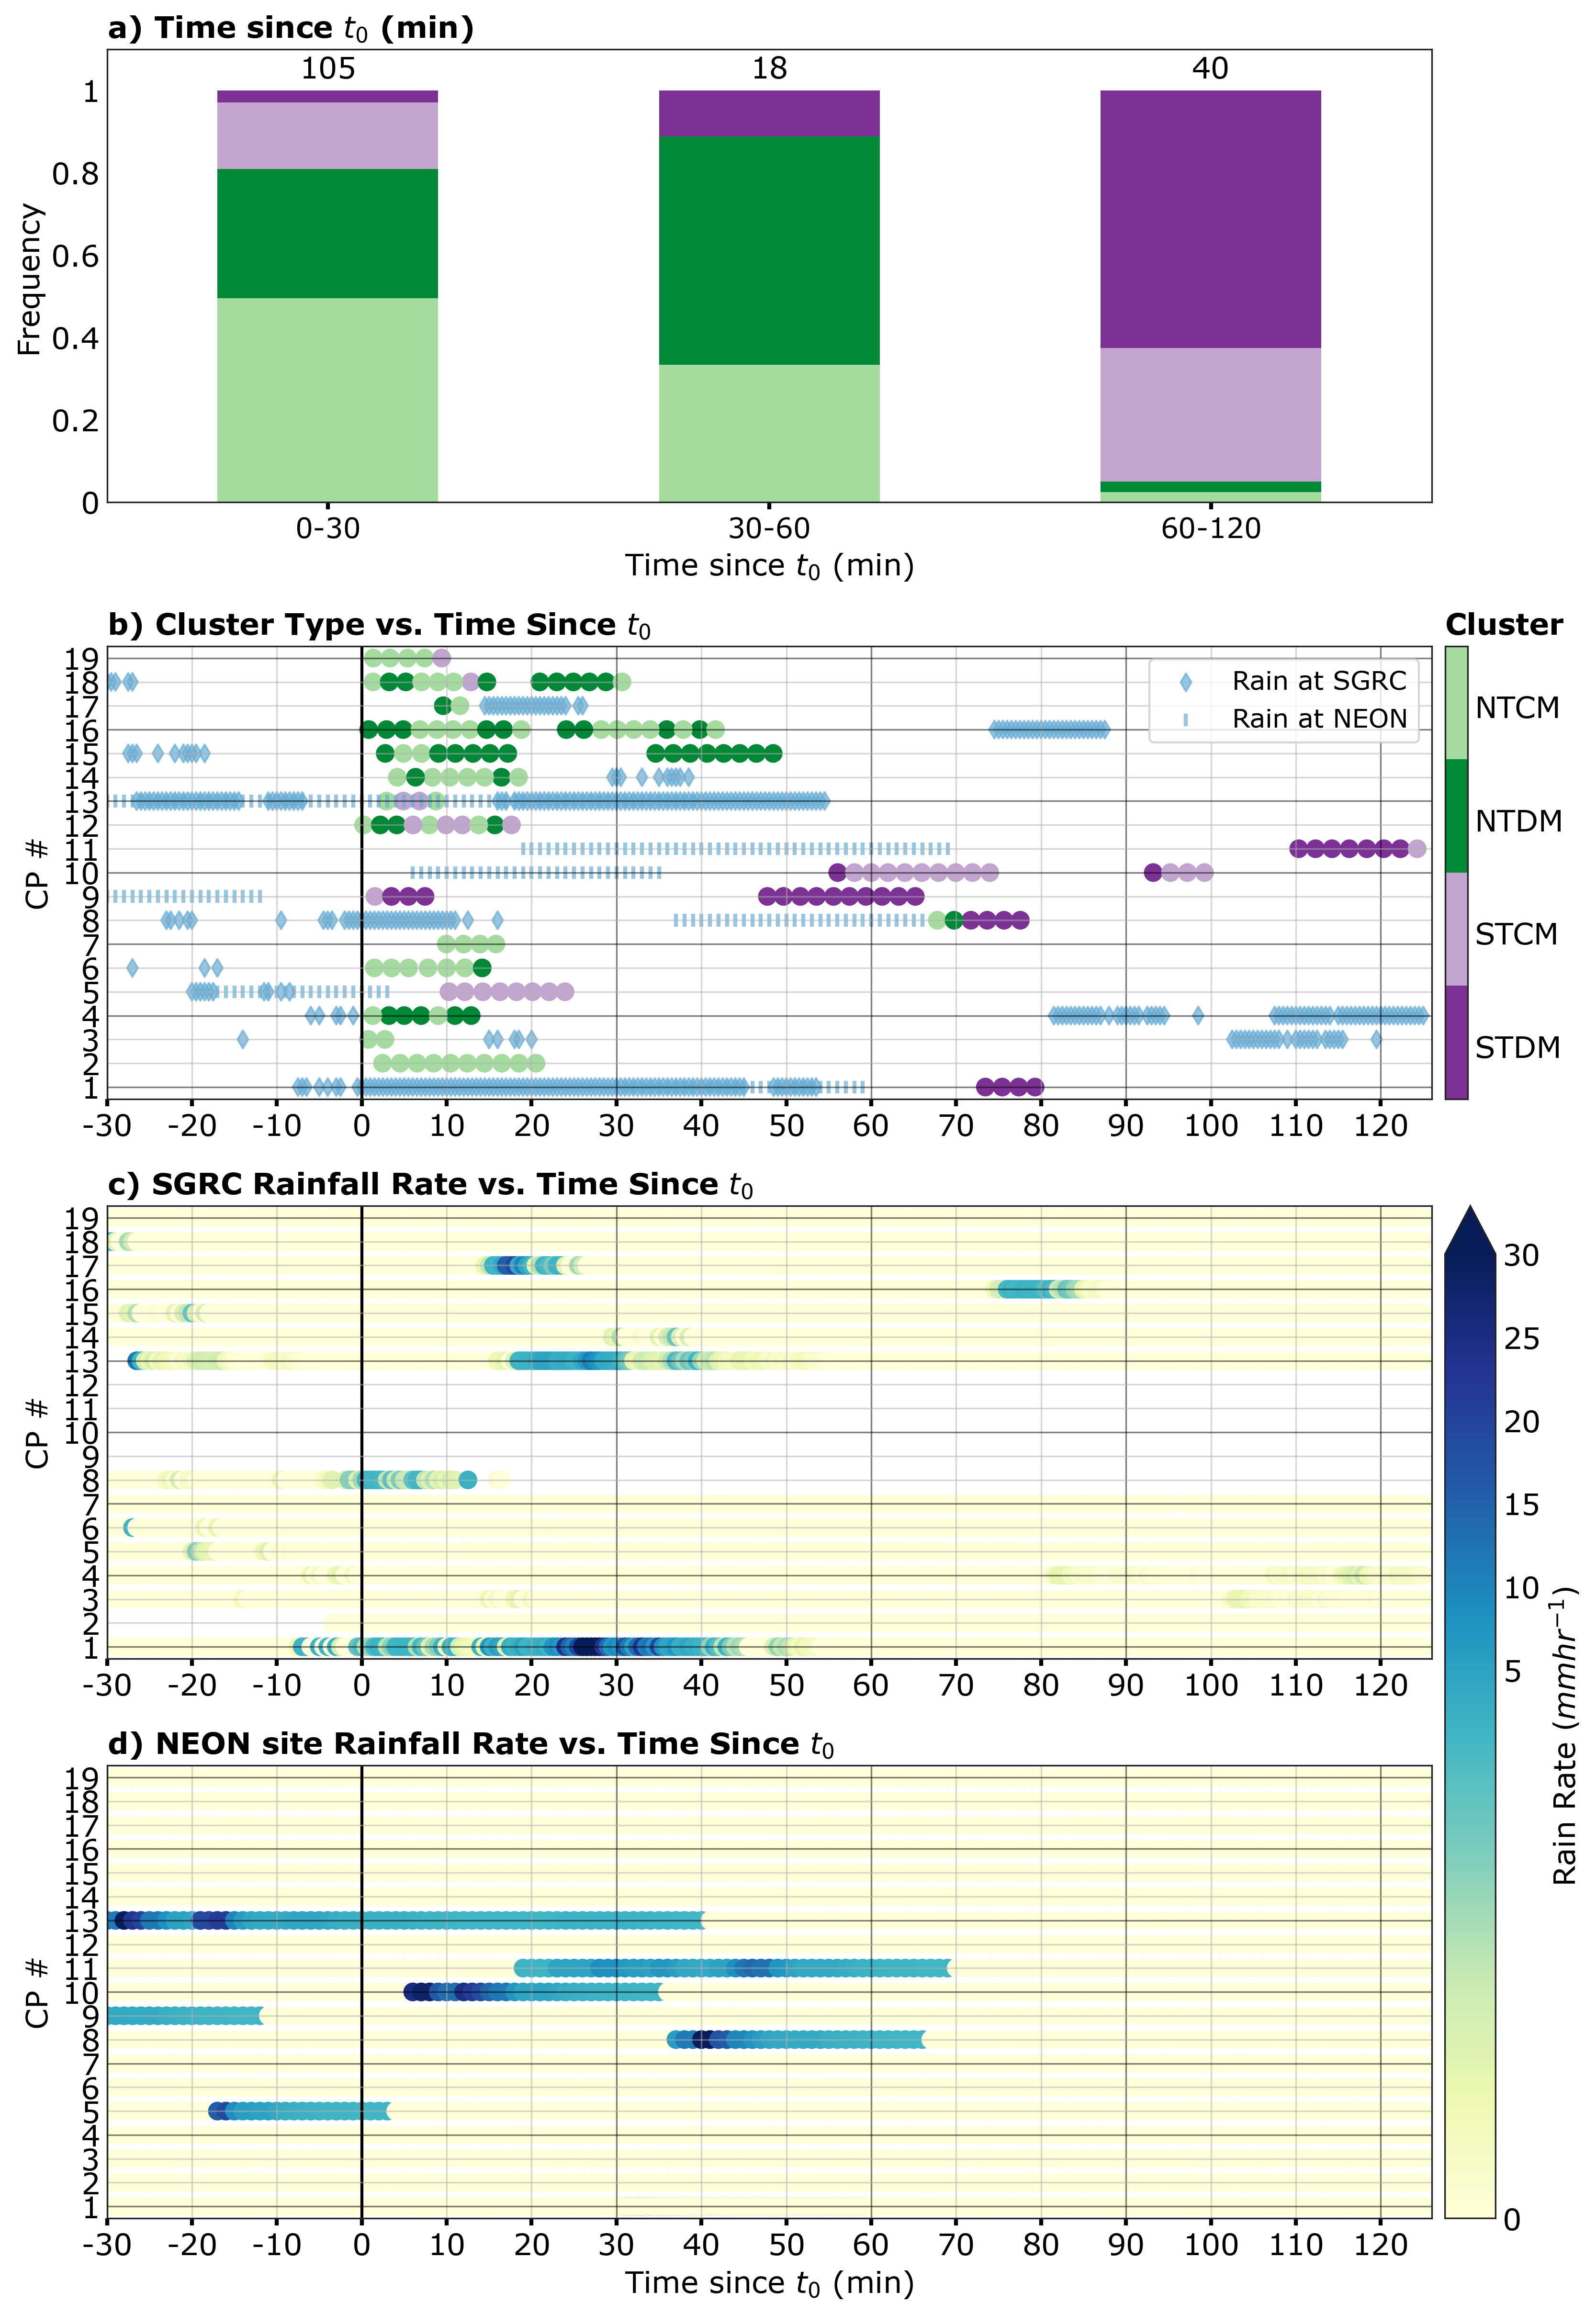

In [290]:
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14)
fig, axes = plt.subplots(4,1,facecolor = "white", figsize = (11,16), constrained_layout = "False")

ax0 = axes[0]

cmap = cluster_cmap2
# cmap = plt.get_cmap(cluster_cmap, 4)
cmap = mcolors.ListedColormap(cluster_colors2)

df_grouped = post_CP_log.groupby("dtime_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("dtime_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("dtime_bins").sum().iloc[i].sum())

# for p in ax.patches:
#     ax.annotate(str(p.get_height()), # (p.get_x() * 1.005, p.get_height() * 1.005))
cmap = YGB_cmap_r2
cmap = cluster_cmap2
bar = df_grouped.plot.bar(stacked=True, cmap = cmap, ax=ax0)

ax0.bar_label(bar.containers[-1], padding=3, labels = counts, fontsize = 15)
# ax1.legend(bbox_to_anchor=(0.9, -0.12),ncols = 2, fontsize = 20,columnspacing = 0.5, fancybox = False)
ax0.legend().remove()
ax0.set_xlabel("")
ax0.tick_params(axis='x', labelrotation= 0)

ax0.set_title(r"a) Time since $t_0$ (min)", fontsize = 15)
ax0.set_xlabel("Time since $t_0$ (min)", fontsize = 15)
ax0.set_ylabel("Frequency", fontsize =15)
ax0.set_yticklabels([0,0.2,0.4,0.6,0.8,1], fontsize = 15)
# fig.subplots_adjust(wspace=0.0, hspace=0.0)
ax0.set_ylim(0,1.1)

ax = axes[1]
cmap = cluster_cmap2
divnorm = TwoSlopeNorm(vmin = 0, vcenter = 1, vmax=30)
divnorm = TwoSlopeNorm(vmin = 0, vcenter = 1, vmax=2)
# cmap = plt.get_cmap(cluster_cmap, 4)
sgrc_x2 = pd.to_timedelta(sgrc_long_v1.dt).dt.total_seconds()/60
cmap = mcolors.ListedColormap(cluster_colors2)
norm = plt.Normalize(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly"].min(), post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2"].max())
scatter = ax.scatter(x_flights, post_CP_log2["CP_id"]+1, c = post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2"], cmap = cmap, s = 70)#, vmin = 1, vmax = 4)
# precip = ax.scatter(sgrc_x2, sgrc_long_v2.CP_id_2, c = sgrc_long_v2.Rain_rate_mm_hr, cmap = YlGnBu_9.mpl_colormap,marker = "d", norm = divnorm, s = 40, alpha = 0.7)
# ax.scatter(x2, sr_long_v5.CP_id_2, c = sr_long_v5.Rain_rate_mm_hr, cmap = YlGnBu_9.mpl_colormap, marker = '|', norm = divnorm, s = 40, alpha = 0.7, edgecolors = "black")
precip = ax.scatter(sgrc_x2, sgrc_long_v2.CP_id_2+1, c = sgrc_long_v2.Rain, cmap = "Blues",marker = "d", norm = divnorm, s = 40, alpha = 0.7)
ax.scatter(x2, sr_long_v5.CP_id_2+1, c = sr_long_v5.Rain, cmap = 'Blues', marker = '|', norm = divnorm, s = 40, alpha = 0.7, edgecolors = "black")
## ax.set_xlim(datetime.datetime(2022,5,29,13,00), datetime.datetime(2022,5,29,16,15))
# sm = ScalarMappable(norm = norm, cmap = cmap)
# sm.set_array([])
# cbar = fig.colorbar(scatter, ticks = np.arange(1.4,4,0.75),ax =[axes[0],axes[1]], pad = 0.01)
cbar = fig.colorbar(scatter, ax =ax, ticks = np.arange(1.4,4,0.75),pad = 0.01)
cbar.ax.set_yticklabels(["NTCM","NTDM", "STCM", "STDM"], fontsize = 15)
cbar.ax.invert_yaxis()
cbar.ax.set_title("Cluster", fontsize = 15)
# cbar2 = fig.colorbar(precip, ax = ax, pad = 0.03)
# cbar2.ax.set_title(f"Rain Rate \n(mm/hr)", fontsize = 15)
# cbar2.ax.set_yticklabels(np.arange(0,31,5), fontsize = 15)
shape_handles = [
    # plt.scatter([0], [0], marker='o', color='k' , s=70, label='Cluster'),
    plt.scatter([0], [0], marker='d', color='#6aaed6', s=40, label='Rain at SGRC', alpha = 0.7),
    plt.scatter([0], [0], marker='|', color='#6aaed6', s=40, label='Rain at NEON', alpha = 0.7)
]
# Adding the second legend removes the first, so we manually re-add the first one
# ax.add_artist(legend1)
ax.legend(handles=shape_handles, loc='upper right', facecolor = "white", frameon = True, fontsize = 13)
leg_label_list = []
leg_label_list2 = []
prev_temp_iop = 0
count2 = 1
for i in range(post_CP_log2["CP_id"].max()+1):
    df_temp = post_CP_log2[post_CP_log2["CP_id"] == i]
    if len(df_temp)== 0:
        leg_label_list.append(" ")
    else:
        df_temp=df_temp.iloc[0]
        iop_temp =  df_temp["IOP"]
        count2 +=1
        if iop_temp != prev_temp_iop:
            count = 1
        else:
            count+=1
        ## leg_label_list.append("CP: "+str(df_temp["CP_id"]+1)+ " IOP: " + str(df_temp["IOP"]))
        leg_label_list.append("IOP" + str(df_temp["IOP"]) + " CP" +str(count))
        leg_label_list2.append("CP" + str(count2))
        prev_temp_iop = iop_temp



ax.set_title(r"b) Cluster Type vs. Time Since $t_0$", fontsize = 15)
one_minute = 1e9 * 60 
# ax.set_xticks(one_minute * np.arange(0, 126, 10), labels = np.arange(0, 126, 10))
ax.set_xticks(np.arange(-30,121,10), labels = np.arange(-30,121,10), fontsize = 15)
# ax.grid(alpha = 0.3)
# ax.set_yticks(np.arange(0,19),labels = leg_label_list, fontsize = 15)
ax.set_yticks(np.arange(1,20,1), labels = np.arange(1,20,1), fontsize = 15)
# ax.set_yticks(np.arange(1,20,1), labels = np.arange(1,20,1), fontsize = 20)
# ax.set_ylabel("CP #", fontsize = 20)
ax.grid(alpha = 0.5)
# ax.set_xlabel("Time Since Cold Pool Passage (min)", fontsize = 15)
ax.set_ylabel("CP #", fontsize = 15)
grid = ax.get_ygridlines()
gridx = ax.get_xgridlines()
clr_freq = 3
for i in range(0,len(gridx),clr_freq):
    b = gridx[i]
    if i ==0+clr_freq:
        b.set_linewidth(1.5)
        b.set_alpha(1)
    b.set_color('black')

for i in range(0,len(grid),clr_freq):
    b = grid[i]
    b.set_color('black')

ax.set_xlim(-30,126)
ax.set_ylim(0.5,19.5)

ax = axes[2]
divnorm = TwoSlopeNorm(vmin = 0, vcenter = 1, vmax=30)
sgrc_x2 = pd.to_timedelta(sgrc_long_v1.dt).dt.total_seconds()/60
im = ax.scatter(sgrc_x2, sgrc_long_v1.CP_id_2+1, c = sgrc_long_v1.Rain_rate_mm_hr, cmap  = YlGnBu_9.mpl_colormap,norm = divnorm, s = 70)
one_minute = 1e9 * 60 
one_minute = 1
# plt.xticks(one_minute * np.arange(-10, 121, 10), labels = np.arange(-10, 121, 10))
x_ticks = pd.to_timedelta(one_minute*np.arange(-10,121,10), unit = 's')
# plt.xticks(one_minute * np.arange(-10, 121, 10), labels = np.arange(-10, 121, 10))
ax.set_xticks(np.arange(-30,121,10), labels = np.arange(-30,121,10), fontsize = 15)
ax.set_ylabel("CP #", fontsize = 15)


leg_label_list = []
prev_temp_iop = 0
for i in range(post_CP_log2["CP_id"].max()+1):
    df_temp = post_CP_log2[post_CP_log2["CP_id"] == i]
    if len(df_temp)== 0:
        leg_label_list.append(" ")
    else:
        df_temp=df_temp.iloc[0]
        iop_temp =  df_temp["IOP"]
        if iop_temp != prev_temp_iop:
            count = 1
        else:
            count+=1
        ## leg_label_list.append("CP: "+str(df_temp["CP_id"]+1)+ " IOP: " + str(df_temp["IOP"]))
        leg_label_list.append("IOP" + str(df_temp["IOP"]) + " CP" +str(count))
        prev_temp_iop = iop_temp
# ax.set_yticks(np.arange(0,19),labels = leg_label_list, fontsize =15)
ax.set_yticks(np.arange(1,20,1), labels = np.arange(1,20,1), fontsize = 15)
ax.grid(alpha = 0.5)
grid = ax.get_ygridlines()
gridx = ax.get_xgridlines()

for i in range(0,len(gridx),clr_freq):
    b = gridx[i]
    if i ==0+clr_freq:
        b.set_linewidth(1.5)
        b.set_alpha(1)
    b.set_color('black')

for i in range(0,len(grid),clr_freq):
    b = grid[i]
    b.set_color('black')

ax.set_title(r"c) SGRC Rainfall Rate vs. Time Since $t_0$", fontsize = 15)
# ax.colorbar(extend = "max")
ax.set_xlim(-30,126)
ax.set_ylim(0.5,19.5)

ax = axes[3]
divnorm = TwoSlopeNorm(vmin = 0, vcenter = 1, vmax=30)
ax.scatter(x2, sr_long_v4.CP_id_2+1, c = sr_long_v4.Rain_rate_mm_hr, cmap  = YlGnBu_9.mpl_colormap, norm = divnorm, s = 70)
one_minute = 1e9 * 60 
one_minute = 60 
# one_minute = 1
x_ticks = pd.to_timedelta(one_minute*np.arange(-10,121,10), unit = 's')
# plt.xticks(one_minute * np.arange(-10, 121, 10), labels = np.arange(-10, 121, 10))
ax.set_xticks(np.arange(-30,121,10), labels = np.arange(-30,121,10), fontsize = 15)

leg_label_list = []
prev_temp_iop = 0
for i in range(post_CP_log2["CP_id"].max()+1):
    df_temp = post_CP_log2[post_CP_log2["CP_id"] == i]
    if len(df_temp)== 0:
        leg_label_list.append(" ")
    else:
        df_temp=df_temp.iloc[0]
        iop_temp =  df_temp["IOP"]
        if iop_temp != prev_temp_iop:
            count = 1
        else:
            count+=1
        ## leg_label_list.append("CP: "+str(df_temp["CP_id"]+1)+ " IOP: " + str(df_temp["IOP"]))
        leg_label_list.append("IOP" + str(df_temp["IOP"]) + " CP" +str(count))
        prev_temp_iop = iop_temp
# ax.set_yticks(np.arange(0,19),labels = leg_label_list, fontsize = 15)
ax.set_yticks(np.arange(1,20,1), labels = np.arange(1,20,1), fontsize = 15)
ax.grid(alpha = 0.5)
ax.set_ylim(0.5,19.5)
grid = ax.get_ygridlines()
gridx = ax.get_xgridlines()

for i in range(0,len(gridx),clr_freq):
    b = gridx[i]
    if i ==0+clr_freq:
        b.set_linewidth(1.5)
        b.set_alpha(1)
    b.set_color('black')

for i in range(0,len(grid),clr_freq):
    b = grid[i]
    b.set_color('black')
ax.set_title(r"d) NEON site Rainfall Rate vs. Time Since $t_0$", fontsize = 15)
# fig.subplots_adjust(hspace = 0.5,right=0.8)
fig.get_layout_engine().set(hspace=0.05) 
sm = ScalarMappable(norm = divnorm, cmap = YlGnBu_9.mpl_colormap)
sm.set_array([])
contrained_layout = True
cbar = fig.colorbar(sm, extend = "max",ax =[axes[2],axes[3]], pad = 0.01)
# cbar.ax.set_title(r"Rain Rate $(mm hr^{-1})$", rotation = 90, va = "top", y=0.6,pad = 30,fontsize = 15, transform=cbar.ax.transAxes)
cbar.set_label(r"Rain Rate $(mm hr^{-1})$", rotation = 90, fontsize = 15)
cbar.ax.set_yticklabels(np.arange(0,31,5), fontsize = 15)
ax.set_xlabel(r"Time since $t_0$ (min)", fontsize = 15)
ax.set_ylabel("CP #", fontsize = 15)
ax.set_xlim(-30,126)
# plt.tight_layout(pad=2.0)
fig.savefig(f"{figPath}figure4_v12_08242026_2")

## Code for plotting Figure 6-8

### Code for plotting Figure 6

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/3079206225.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["distance_bins"] = pd.cut(post_CP_log["CP_distance2"],bins, labels = labels_depths)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/3079206225.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = post_CP_log.groupby("distance_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
/var/folders/4q/by3lqw_x3cd0qth

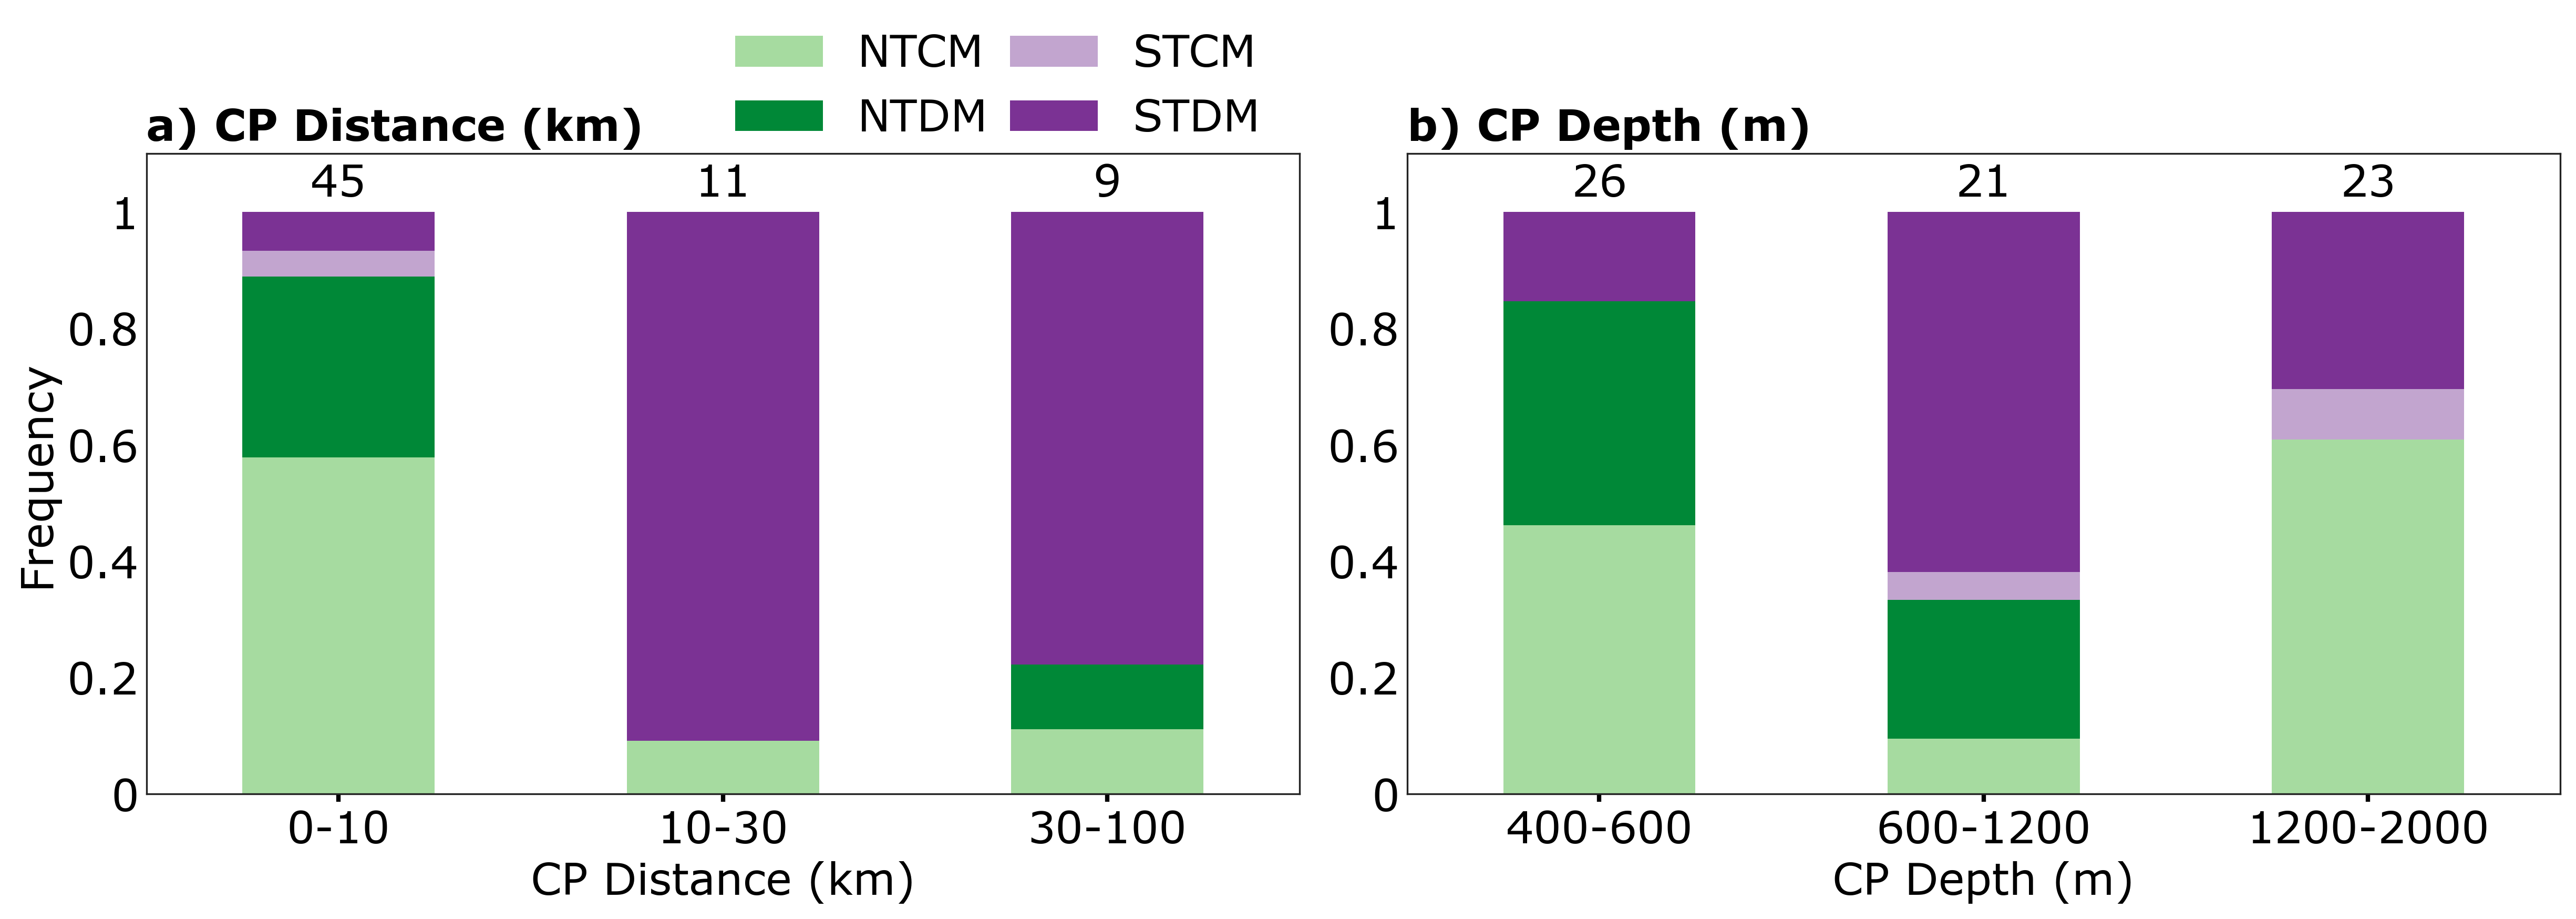

In [263]:
# fig = plt.figure(figsize=(16.5, 6))
fig = plt.figure(figsize=(16.5, 6))
gs = gridspec.GridSpec(1, 2, width_ratios = [2,2])  # 2 rows, 2 columns

ax = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cmap = cluster_cmap2
# cmap = plt.get_cmap(cluster_cmap, 4)
cmap = mcolors.ListedColormap(cluster_colors2)
bins = [0,10000,30000,100000]
labels_depths = ['0-10', '10-30','30-100']
post_CP_log["distance_bins"] = pd.cut(post_CP_log["CP_distance2"],bins, labels = labels_depths)
# df_grouped = post_CP_log.groupby("4cluster_minmax_CPonly_mode1_zonly2_labels")["depth_bins"].value_counts(normalize=True).unstack("depth_bins")
df_grouped = post_CP_log.groupby("distance_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("distance_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("distance_bins").sum().iloc[i].sum())

# for p in ax.patches:
#     ax.annotate(str(p.get_height()), # (p.get_x() * 1.005, p.get_height() * 1.005))
cmap = YGB_cmap_r2
cmap = cluster_cmap2
df_grouped.plot.bar(stacked=True, cmap = cmap, ax=ax)
ax.bar_label(ax.containers[-1], padding=3, labels = counts, fontsize = 20)
# ax.legend().remove()
ax.legend(bbox_to_anchor=(1., 1.25),ncols = 2,columnspacing = 0.5, fontsize = 20)

ax.set_xlabel("")
ax.tick_params(axis='x', labelrotation= 0)
# ax1.set_xticklabels(["NTCM","NTDM", "STCM", "STDM"], fontsize = 20)
ax.set_xticklabels(labels_depths, fontsize = 20)
# for xtick, color in zip(ax1.get_xticklabels(), cluster_colors2):
# for xtick, color in zip(ax1.get_xticklabels(), YGB_cmap_r2):
#     xtick.set_color(color)
# ax4.set_ylabel("Frequency")
ax.set_title("a) CP Distance (km)", fontsize = 20)
ax.set_xlabel("CP Distance (km)", fontsize = 20)
ax.set_ylabel("Frequency", fontsize =20)
ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1], fontsize = 20)
# fig.subplots_adjust(wspace=0.0, hspace=0.0)
ax.set_ylim(0,1.1)
# norm = plt.Normalize(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly"].min(), post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2"].max())
# scatter = ax.scatter(post_CP_log2["CP_distance2"], post_CP_log2["CP_id"], c = post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2"], cmap = cmap, s = 70)#, vmin = 1, vmax = 4)
# ## ax.set_xlim(datetime.datetime(2022,5,29,13,00), datetime.datetime(2022,5,29,16,15))
# # sm = ScalarMappable(norm = norm, cmap = cmap)
# # sm.set_array([])
# cbar = fig.colorbar(scatter, ax =ax, ticks = np.arange(1.4,4,0.75),pad = 0.01)
# cbar.ax.set_yticklabels(["NTCM","NTDM", "STCM", "STDM"], fontsize = 20)
# cbar.ax.invert_yaxis()
# cbar.ax.set_title("Cluster", fontsize = 20)
# leg_label_list = []
# prev_temp_iop = 0
# for i in range(post_CP_log2["CP_id"].max()+1):
#     df_temp = post_CP_log2[post_CP_log2["CP_id"] == i]
#     if len(df_temp)== 0:
#         leg_label_list.append(" ")
#     else:
#         df_temp=df_temp.iloc[0]
#         iop_temp =  df_temp["IOP"]
#         if iop_temp != prev_temp_iop:
#             count = 1
#         else:
#             count+=1
#         ## leg_label_list.append("CP: "+str(df_temp["CP_id"]+1)+ " IOP: " + str(df_temp["IOP"]))
#         leg_label_list.append("IOP" + str(df_temp["IOP"]) + " CP" +str(count))
#         prev_temp_iop = iop_temp
# # ax.legend(*scatter.legend_elements(), title = "Cluster")
# ax.set_title("a) Cluster Type vs. Distance from CP Edge", fontsize = 20)
# one_minute = 1e9 * 60 
# # ax.set_xticks(one_minute * np.arange(0, 126, 10), labels = np.arange(0, 126, 10))
# ax.set_xticks(np.arange(0,100001,10000), labels = np.arange(0,101,10), fontsize = 20)
# ax.set_xlabel("Distance from CP edge (km)", fontsize = 20)
# ax.set_yticks(np.arange(0,19),labels = leg_label_list, fontsize = 20)
# ax.grid(alpha = 0.5)

# grid = ax.get_ygridlines()
# gridx = ax.get_xgridlines()
# clr_freq = 3
# for i in range(0,len(gridx),clr_freq):
#     b = gridx[i]
#     if i ==0:
#         b.set_linewidth(1.5)
#         b.set_alpha(1)
#     b.set_color('black')

# for i in range(0,len(grid),clr_freq):
#     b = grid[i]
#     b.set_color('black')

# ax1 = axes[1]
bins = [400,600,1200,2000]
labels_depths = ['400-600', '600-1200','1200-2000']
post_CP_log["depth_bins"] = pd.cut(post_CP_log["CP_depth"],bins, labels = labels_depths)
# df_grouped = post_CP_log.groupby("4cluster_minmax_CPonly_mode1_zonly2_labels")["depth_bins"].value_counts(normalize=True).unstack("depth_bins")
df_grouped = post_CP_log.groupby("depth_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("depth_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("depth_bins").sum().iloc[i].sum())
cmap = YGB_cmap_r2
cmap = cluster_cmap2
df_grouped.plot.bar(stacked=True, cmap = cmap, ax=ax1)
ax1.bar_label(ax.containers[-1], padding=3, labels = counts, fontsize = 20)
# ax1.legend(bbox_to_anchor=(0.9, -0.12),ncols = 2, fontsize = 20,columnspacing = 0.5, fancybox = False)
ax1.legend().remove()
ax1.set_xlabel("")
ax1.tick_params(axis='x', labelrotation= 0)
# ax1.set_xticklabels(["NTCM","NTDM", "STCM", "STDM"], fontsize = 20)
ax1.set_xticklabels(labels_depths, fontsize = 20)
# for xtick, color in zip(ax1.get_xticklabels(), cluster_colors2):
# for xtick, color in zip(ax1.get_xticklabels(), YGB_cmap_r2):
#     xtick.set_color(color)
# ax4.set_ylabel("Frequency")
ax1.set_title("b) CP Depth (m)", fontsize = 20)
ax1.set_xlabel("CP Depth (m)", fontsize = 20)
# ax1.set_ylabel("Frequency", fontsize =20)
ax1.set_yticklabels([0,0.2,0.4,0.6,0.8,1], fontsize = 20)
fig.subplots_adjust(wspace=0.0, hspace=0.0)
ax1.set_ylim(0,1.1)
fig.savefig(f"{figPath}figure4_part3_v11_inverse_08192026")

### Code for Plotting Figure 7

<>:96: SyntaxWarning: invalid escape sequence '\D'
<>:96: SyntaxWarning: invalid escape sequence '\D'
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/2994163077.py:96: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel("|$\Delta$$T_{surface}$| ($\degree C$)", fontsize = fsize)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/2994163077.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = post_CP_log.groupby("dT2_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/2994163077.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

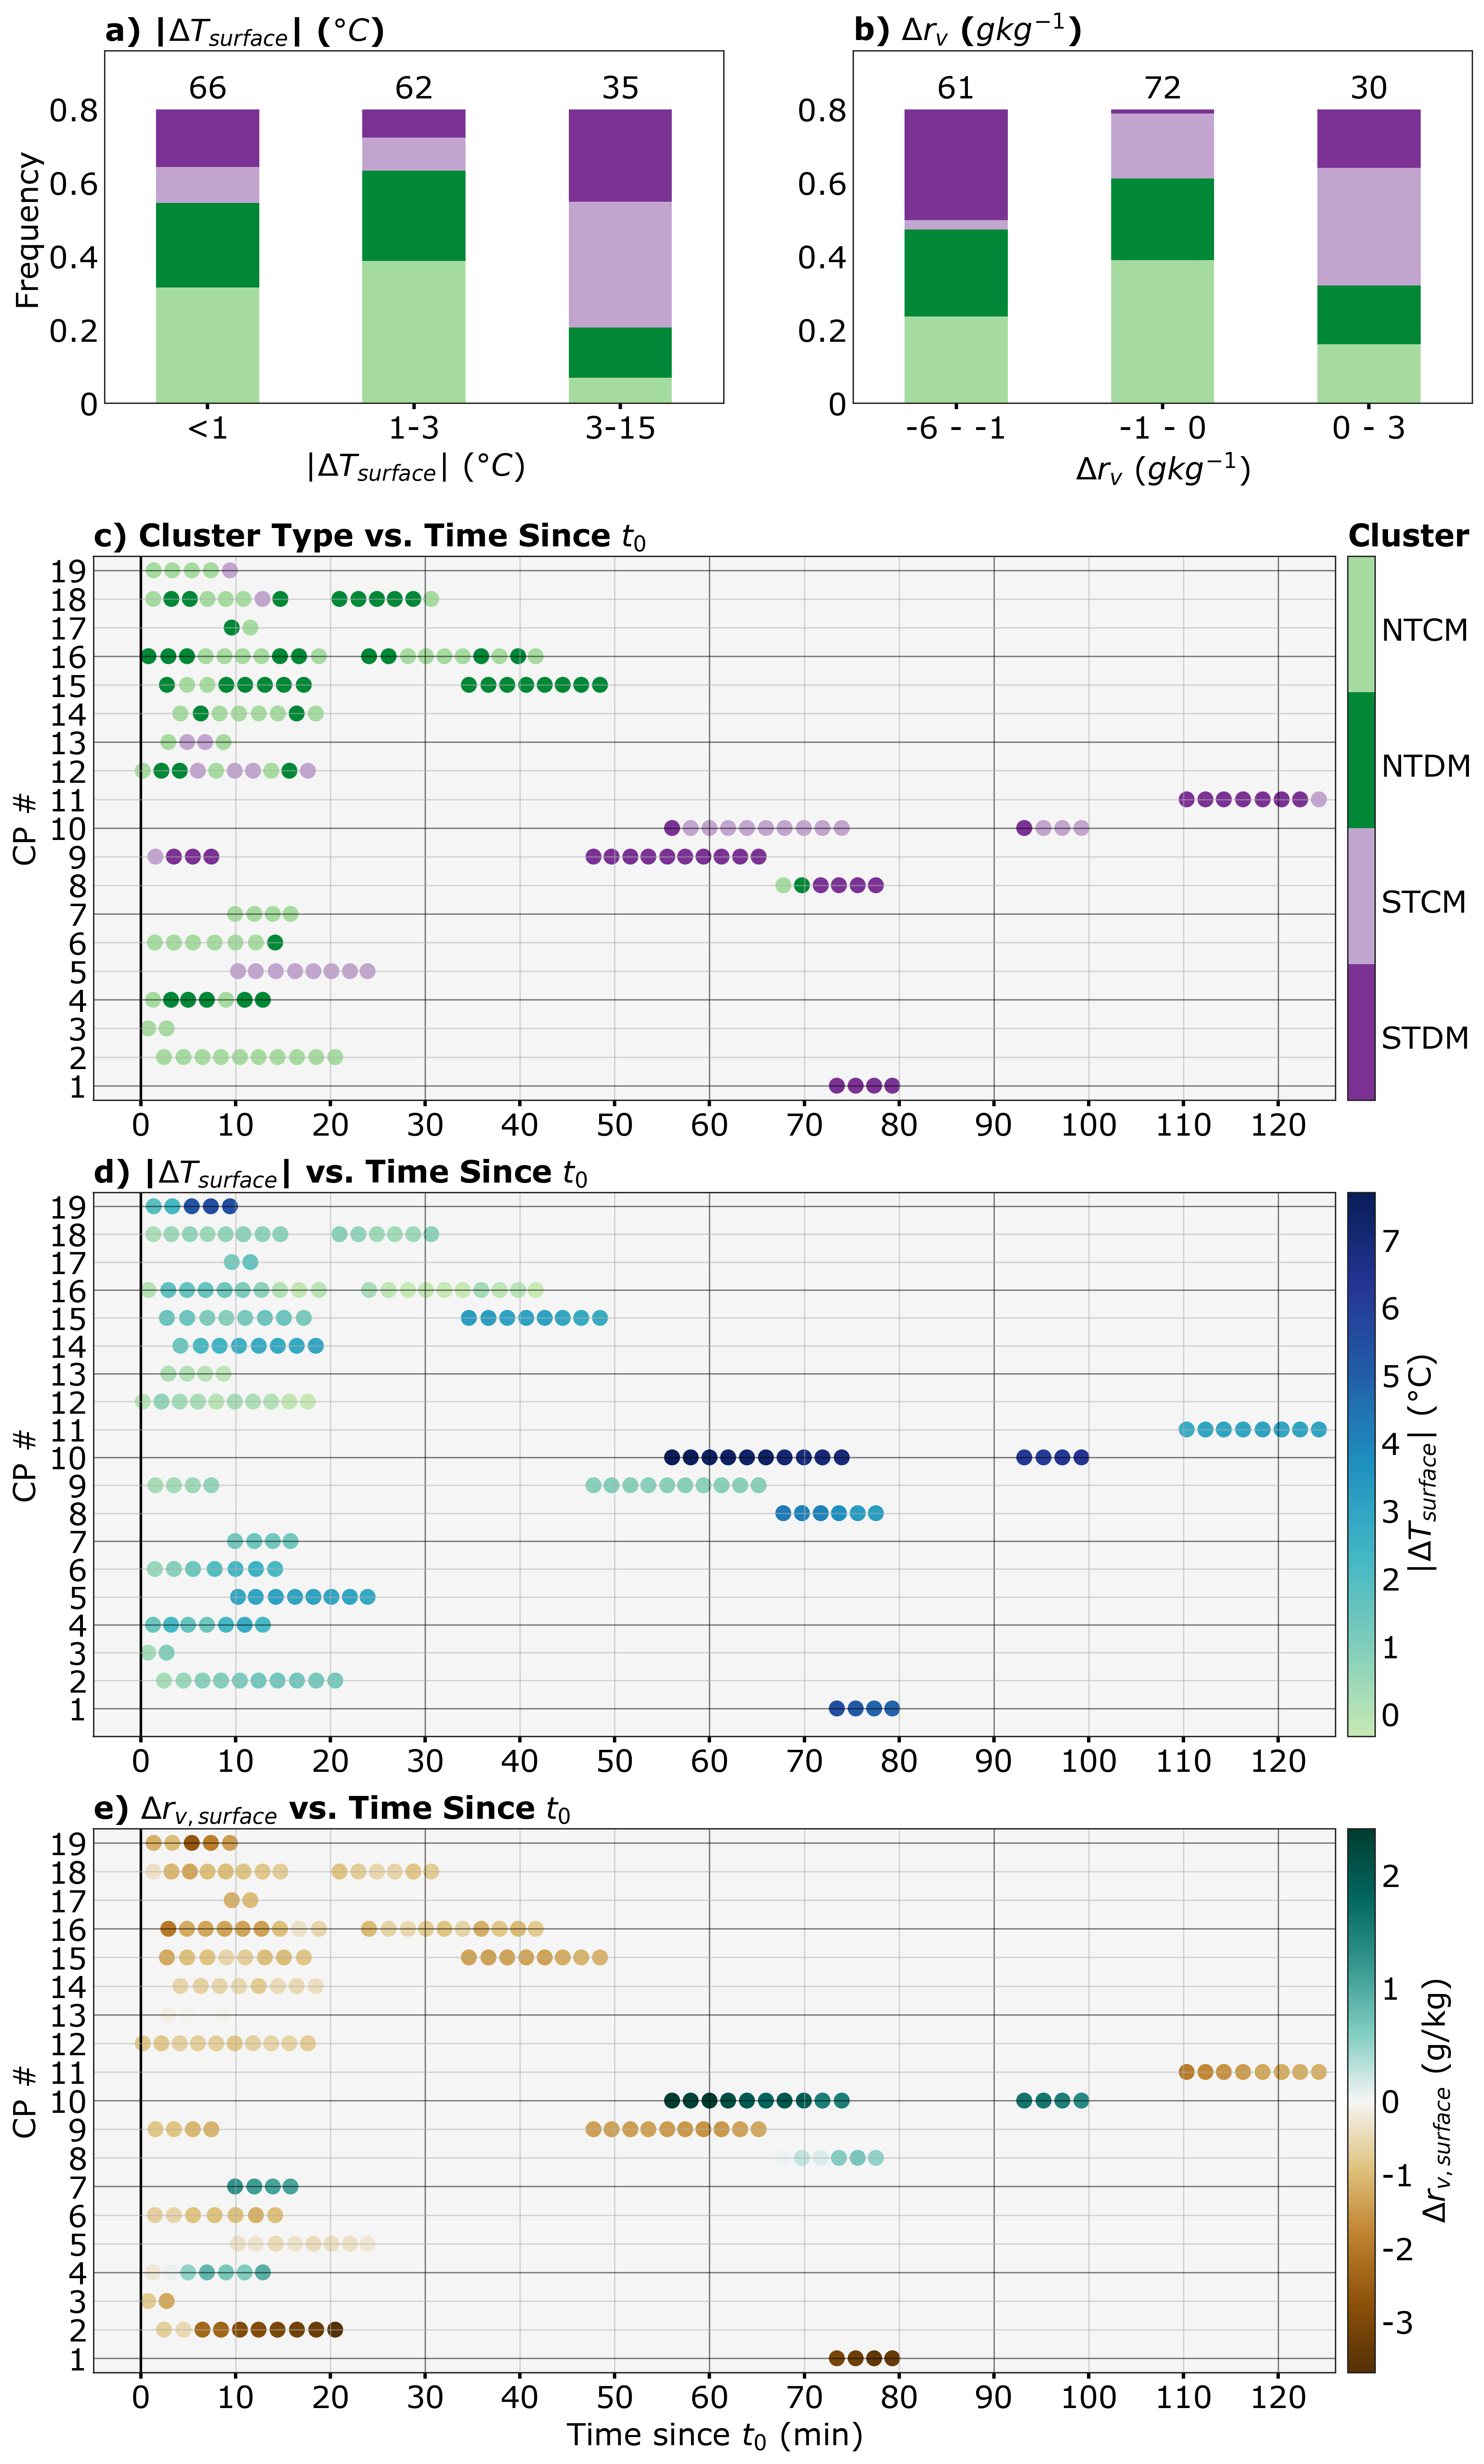

In [289]:
# fig = plt.figure(figsize=(16.5, 6))
fsize = 18
matplotlib.rc('xtick', labelsize=fsize) 
matplotlib.rc('ytick', labelsize=fsize)
fig = plt.figure(figsize=(12, 20), constrained_layout = True)
# gs = gridspec.GridSpec(1, 3, width_ratios = [2,2,2])  # 2 rows, 2 columns
# gs = gridspec.GridSpec(4, 3, wspace=0.2, hspace=0.3) 
# master_gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 3], hspace=0.4)
master_gs = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[1, 0.05,4], hspace=0.3)
# 3. Add the top subplot (Row 1)
# ax0 = fig.add_subplot(master_gs[0])
# ax1.set_title("Row 1 (Separated)")

# 4. Nested layout inside the bottom slot of master_gs
# Set 'hspace=0' to eliminate the white space between Rows 2, 3, and 4
# sub_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=master_gs[1], hspace=0)
top_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=master_gs[0], wspace=0.1)
# ax0 = fig.add_subplot(top_gs[0, 0])
ax = fig.add_subplot(top_gs[0, 0])
ax_con = fig.add_subplot(top_gs[0, 1])
bottom_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=master_gs[2], hspace=0.02)
ax3 = fig.add_subplot(bottom_gs[0, 0])
ax4 = fig.add_subplot(bottom_gs[1, 0])
ax5 = fig.add_subplot(bottom_gs[2, 0])
# ax0 = fig.add_subplot(gs[0, 0])
# ax = fig.add_subplot(gs[0, 1])
# ax = fig.add_subplot(sub_gs[0])
# ax_con = fig.add_subplot(gs[0, 2])
# ax3 = fig.add_subplot(gs[1,:])
# ax4 = fig.add_subplot(gs[2,:])
# ax5 = fig.add_subplot(gs[3,:])
# cmap = cluster_cmap2
# # cmap = plt.get_cmap(cluster_cmap, 4)
# cmap = mcolors.ListedColormap(cluster_colors2)

# df_grouped = post_CP_log.groupby("dtime_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
# df_grouped_counts = post_CP_log.groupby("dtime_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
# counts = []
# for i in range(3):
#     counts.append(df_grouped_counts.groupby("dtime_bins").sum().iloc[i].sum())

# # for p in ax.patches:
# #     ax.annotate(str(p.get_height()), # (p.get_x() * 1.005, p.get_height() * 1.005))
# cmap = YGB_cmap_r2
# cmap = cluster_cmap2
# bar = df_grouped.plot.bar(stacked=True, cmap = cmap, ax=ax0)
# # for container in bar.containers:
# #     if container == bar.containers[-1]:
# #         counts2 = ['' if i == 0 else counts[i] for i, v in enumerate(counts)]
# #         ax0.bar_label(container, padding=3, labels = counts2, fontsize = 15)
# #     elif container == bar.containers[-2]:
# #         counts2 = [counts[i] if i == 0 else '' for i, v in enumerate(counts)]
# #         ax0.bar_label(container, padding=3, labels = counts2, fontsize = 15)
# ax0.bar_label(bar.containers[-1], padding=3, labels = counts, fontsize = 15)
# # ax1.legend(bbox_to_anchor=(0.9, -0.12),ncols = 2, fontsize = 20,columnspacing = 0.5, fancybox = False)
# ax0.legend().remove()
# ax0.set_xlabel("")
# ax0.tick_params(axis='x', labelrotation= 0)

# ax0.set_title(r"a) Time since $t_0$ (min)", fontsize = 15)
# ax0.set_xlabel("Time since $t_0$ (min)", fontsize = 15)
# ax0.set_ylabel("Frequency", fontsize =15)
# ax0.set_yticklabels([0,0.2,0.4,0.6,0.8,1], fontsize = 15)
# # fig.subplots_adjust(wspace=0.0, hspace=0.0)
# ax0.set_ylim(0,1.2)



df_grouped = post_CP_log.groupby("dT2_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("dT2_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("dT2_bins").sum().iloc[i].sum())

# for p in ax.patches:
#     ax.annotate(str(p.get_height()), # (p.get_x() * 1.005, p.get_height() * 1.005))
cmap = YGB_cmap_r2
cmap = cluster_cmap2
bar = df_grouped.plot.bar(stacked=True, cmap = cmap, ax=ax)
ax.bar_label(ax.containers[-1], padding=3, labels = counts, fontsize = fsize)
# for container in bar.containers:
#     if container == bar.containers[-1]:
#         counts2 = ['' if i == 0 else counts[i] for i, v in enumerate(counts)]
#         ax.bar_label(container, padding=3, labels = counts2, fontsize = 15)
#     elif container == bar.containers[-2]:
#         counts2 = [counts[i] if i == 0 else '' for i, v in enumerate(counts)]
#         ax.bar_label(container, padding=3, labels = counts2, fontsize = 15)
# ax.bar_label(bar, padding=3, labels = counts, fontsize = 20)
# ax1.legend(bbox_to_anchor=(0.9, -0.12),ncols = 2, fontsize = 20,columnspacing = 0.5, fancybox = False)
ax.legend().remove()
ax.set_xlabel("")
ax.tick_params(axis='x', labelrotation= 0)
ax.set_ylabel("Frequency", fontsize =fsize)

ax.set_title(r"a) |$\Delta$$T_{surface}$| ($\degree C$)", fontsize =fsize)
ax.set_xlabel("|$\Delta$$T_{surface}$| ($\degree C$)", fontsize = fsize)
# ax.set_ylabel("Frequency", fontsize =20)
ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1], fontsize = fsize)
# fig.subplots_adjust(wspace=0.0, hspace=0.0)
ax.set_ylim(0,1.2)

df_grouped = post_CP_log.groupby("dMR2_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("dMR2_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("dMR2_bins").sum().iloc[i].sum())
cmap = YGB_cmap_r2
cmap = cluster_cmap2
df_grouped.plot.bar(stacked=True, cmap = cmap, ax=ax_con)
ax_con.bar_label(ax_con.containers[-1], padding=3, labels = counts, fontsize = fsize)
# ax1.legend(bbox_to_anchor=(0.9, -0.12),ncols = 2, fontsize = 20,columnspacing = 0.5, fancybox = False)
ax_con.legend().remove()
ax_con.set_xlabel("")
ax_con.tick_params(axis='x', labelrotation= 0)
# ax1.set_xticklabels(["NTCM","NTDM", "STCM", "STDM"], fontsize = 20)
# ax1.set_xticklabels(labels_depths, fontsize = 20)
# for xtick, color in zip(ax1.get_xticklabels(), cluster_colors2):
# for xtick, color in zip(ax1.get_xticklabels(), YGB_cmap_r2):
#     xtick.set_color(color)
# ax4.set_ylabel("Frequency")
ax_con.set_title(r"b) $\Delta r_v$ ($g kg^{-1}$)", fontsize = fsize)
ax_con.set_xlabel(r"$\Delta r_v$ ($g kg^{-1}$)", fontsize = fsize)
# ax_con.set_ylabel("Frequency", fontsize =20)
ax_con.set_yticklabels([0,0.2,0.4,0.6,0.8,1], fontsize = fsize)
# fig.subplots_adjust(wspace=0.0, hspace=0.05)
ax_con.set_ylim(0,1.2)
ax_con_final = ax_con.containers[-1]
## new version
# fig, axes = plt.subplots(3,1,facecolor = "white", figsize = (11,13), constrained_layout = "False")

ax = ax3
cmap = cluster_cmap2
# cmap = plt.get_cmap(cluster_cmap, 4)
cmap = mcolors.ListedColormap(cluster_colors2)
norm = plt.Normalize(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly"].min(), post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2"].max())
scatter = ax.scatter(x_flights, post_CP_log2["CP_id"]+1, c = post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2"], cmap = cmap, s = 70)#, vmin = 1, vmax = 4)
## ax.set_xlim(datetime.datetime(2022,5,29,13,00), datetime.datetime(2022,5,29,16,15))
# sm = ScalarMappable(norm = norm, cmap = cmap)
# sm.set_array([])
# cbar = fig.colorbar(scatter, ticks = np.arange(1.4,4,0.75),ax =[ax_con,ax3], pad = 0.01)
cbar = fig.colorbar(scatter, ax =ax, ticks = np.arange(1.4,4,0.75),pad = 0.01)
cbar.ax.set_yticklabels(["NTCM","NTDM", "STCM", "STDM"], fontsize =fsize)
cbar.ax.invert_yaxis()
cbar.ax.set_title("Cluster", fontsize = fsize)
leg_label_list = []
prev_temp_iop = 0
for i in range(post_CP_log2["CP_id"].max()+1):
    df_temp = post_CP_log2[post_CP_log2["CP_id"] == i]
    if len(df_temp)== 0:
        leg_label_list.append(" ")
    else:
        df_temp=df_temp.iloc[0]
        iop_temp =  df_temp["IOP"]
        if iop_temp != prev_temp_iop:
            count = 1
        else:
            count+=1
        ## leg_label_list.append("CP: "+str(df_temp["CP_id"]+1)+ " IOP: " + str(df_temp["IOP"]))
        leg_label_list.append("IOP" + str(df_temp["IOP"]) + " CP" +str(count))
        prev_temp_iop = iop_temp



ax.set_title(r"c) Cluster Type vs. Time Since $t_0$", fontsize = fsize)
one_minute = 1e9 * 60 
# ax.set_xticks(one_minute * np.arange(0, 126, 10), labels = np.arange(0, 126, 10))
ax.set_xticks(np.arange(-30,121,10), labels = np.arange(-30,121,10), fontsize = fsize)
# ax.grid(alpha = 0.3)
ax.set_yticks(np.arange(0,19),labels = leg_label_list, fontsize = fsize)
ax.grid(alpha = 0.5)
ax.set_facecolor("whitesmoke")
ax.set_ylim(0.5,19.5)

grid = ax.get_ygridlines()
gridx = ax.get_xgridlines()
clr_freq = 3
for i in range(0,len(gridx),clr_freq):
    b = gridx[i]
    if i ==0+clr_freq:
        b.set_linewidth(1.5)
        b.set_alpha(1)
    b.set_color('black')

for i in range(0,len(grid),clr_freq):
    b = grid[i]
    b.set_color('black')

ax.set_xlim(-5,126)
ax.set_yticks(np.arange(1,20,1), labels = np.arange(1,20,1), fontsize = fsize)
ax.set_ylabel("CP #", fontsize = fsize)

ax = ax4
cmap = YGB_cmap_r
# cmap = GnBu_9_r.mpl_colormap
norm = plt.Normalize( -post_CP_log2["dT"].min(),-post_CP_log2["dT"].max())
scatter = ax.scatter(x_flights, post_CP_log2["CP_id"]+1, c = -post_CP_log2["dT"], cmap = cmap, s = 70)
sm = ScalarMappable(norm = norm, cmap = cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax =ax, pad = 0.01)
# cbar.ax.set_title(r"|$\Delta$$T_{surface}$| ($\degree$C)", fontsize = 15)
cbar.set_label(r"|$\Delta$$T_{surface}$| ($\degree$C)", fontsize = fsize, rotation = 90)
cbar.set_ticks(np.arange(0,8,1))
cbar.ax.set_yticklabels(np.arange(0,8,1), fontsize = fsize)
## ax.set_xlim(datetime.datetime(2022,5,29,13,00), datetime.datetime(2022,5,29,16,15))
ax.set_facecolor("whitesmoke")
leg_label_list = []
prev_temp_iop = 0
for i in range(post_CP_log2["CP_id"].max()+1):
    df_temp = post_CP_log2[post_CP_log2["CP_id"] == i]
    if len(df_temp)== 0:
        leg_label_list.append(" ")
    else:
        df_temp=df_temp.iloc[0]
        iop_temp =  df_temp["IOP"]
        if iop_temp != prev_temp_iop:
            count = 1
        else:
            count+=1

        leg_label_list.append("IOP" + str(df_temp["IOP"]) + " CP" +str(count))
        prev_temp_iop = iop_temp

one_minute = 1e9 * 60 
ax.set_ylim(0.5,19.5)
# ax.set_xticks(one_minute * np.arange(0, 126, 10), labels = np.arange(0, 126, 10))
ax.set_xticks(np.arange(-30,121,10), labels = np.arange(-30,121,10), fontsize =fsize)
ax.set_title(r"d) |$\Delta$$T_{surface}$| vs. Time Since $t_0$", fontsize = fsize)

ax.set_yticks(np.arange(0,19),labels = leg_label_list, fontsize = fsize)
ax.grid(alpha = 0.5)

grid = ax.get_ygridlines()
gridx = ax.get_xgridlines()

clr_freq = 3
for i in range(0,len(gridx),clr_freq):
    b = gridx[i]
    if i ==0+clr_freq:
        b.set_linewidth(1.5)
        b.set_alpha(1)
    b.set_color('black')

for i in range(0,len(grid),clr_freq):
    b = grid[i]
    b.set_color('black')
ax.set_xlim(-5,126)
ax.set_yticks(np.arange(1,20,1), labels = np.arange(1,20,1), fontsize = fsize)
ax.set_ylabel("CP #", fontsize = fsize)


ax = ax5
cmap = BrBu_cmap
divnorm = TwoSlopeNorm(vmin = post_CP_log2["dMR"].min(), vcenter = 0, vmax = post_CP_log2["dMR"].max())

norm = plt.Normalize(post_CP_log2["dMR"].min(), post_CP_log2["dMR"].max())
scatter = ax.scatter(x_flights, post_CP_log2["CP_id"]+1, c = post_CP_log2["dMR"], cmap = cmap, s = 70, norm = divnorm)
sm = ScalarMappable(norm = divnorm, cmap = cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax =ax, pad = 0.01, ticks =[-3,-2,-1,0,1,2] )
# cbar.ax.set_title(r"$\Delta$$r_{v,surface}$ ($g kg^{-1}$)", fontsize = 15)
cbar.set_label(r"$\Delta$$r_{v,surface}$ (g/kg)", rotation = 90, fontsize = fsize)
# cbar.set_ticks([-3,-2,-1,0,1,2])
cbar.ax.set_yticklabels(np.arange(-3,3,1), fontsize = fsize)
ax.set_facecolor("whitesmoke")



leg_label_list = []
prev_temp_iop = 0
for i in range(post_CP_log2["CP_id"].max()+1):
    df_temp = post_CP_log2[post_CP_log2["CP_id"] == i]
    if len(df_temp)== 0:
        leg_label_list.append(" ")
    else:
        df_temp=df_temp.iloc[0]
        iop_temp =  df_temp["IOP"]
        if iop_temp != prev_temp_iop:
            count = 1
        else:
            count+=1
        # leg_label_list.append("CP: "+str(df_temp["CP_id"]+1)+ " IOP: " + str(df_temp["IOP"]))
        leg_label_list.append("IOP" + str(df_temp["IOP"]) + " CP" +str(count))
        prev_temp_iop = iop_temp
##ax.legend(*scatter.legend_elements(),title = "delta MR (g/kg)")
one_minute = 1e9 * 60 
ax.set_xticks(np.arange(-30,121,10), labels = np.arange(-30,121,10), fontsize = fsize)
ax.set_title(r"e) $\Delta$$r_{v,surface}$ vs. Time Since $t_0$", fontsize = fsize)
ax.set_yticks(np.arange(0,19),labels = leg_label_list, fontsize = fsize)
ax.grid(alpha = 0.5)
ax.set_ylim(0.5,19.5)
grid = ax.get_ygridlines()
gridx = ax.get_xgridlines()
clr_freq = 3
for i in range(0,len(gridx),clr_freq):
    b = gridx[i]
    if i ==0+clr_freq:
        b.set_linewidth(1.5)
        b.set_alpha(1)
    b.set_color('black')

for i in range(0,len(grid),clr_freq):
    b = grid[i]
    b.set_color('black')

ax.set_xlim(-5,126)
ax.set_xlabel(r"Time since $t_0$ (min)", fontsize = fsize)
ax.set_yticks(np.arange(1,20,1), labels = np.arange(1,20,1), fontsize = fsize)

ax.set_ylabel("CP #", fontsize = fsize)
# plt.tight_layout()
# fig.savefig(f"{figPath}figure6_08142026_v4")
fig.savefig(f"{figPath}figure4_part3_v11_inverse_08242026_4")

### Code for plotting Figure 8

<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/4156048809.py:43: SyntaxWarning: invalid escape sequence '\d'
  ax2.set_xlabel(f"Max Reflectivity at 0.5$\degree$ (dBZ)", fontsize = 15)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/4156048809.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_CP_log["dBz_bins"] = pd.cut(post_CP_log["dBZ"],bins_dbz, labels = labels_dbz)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/4156048809.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current b

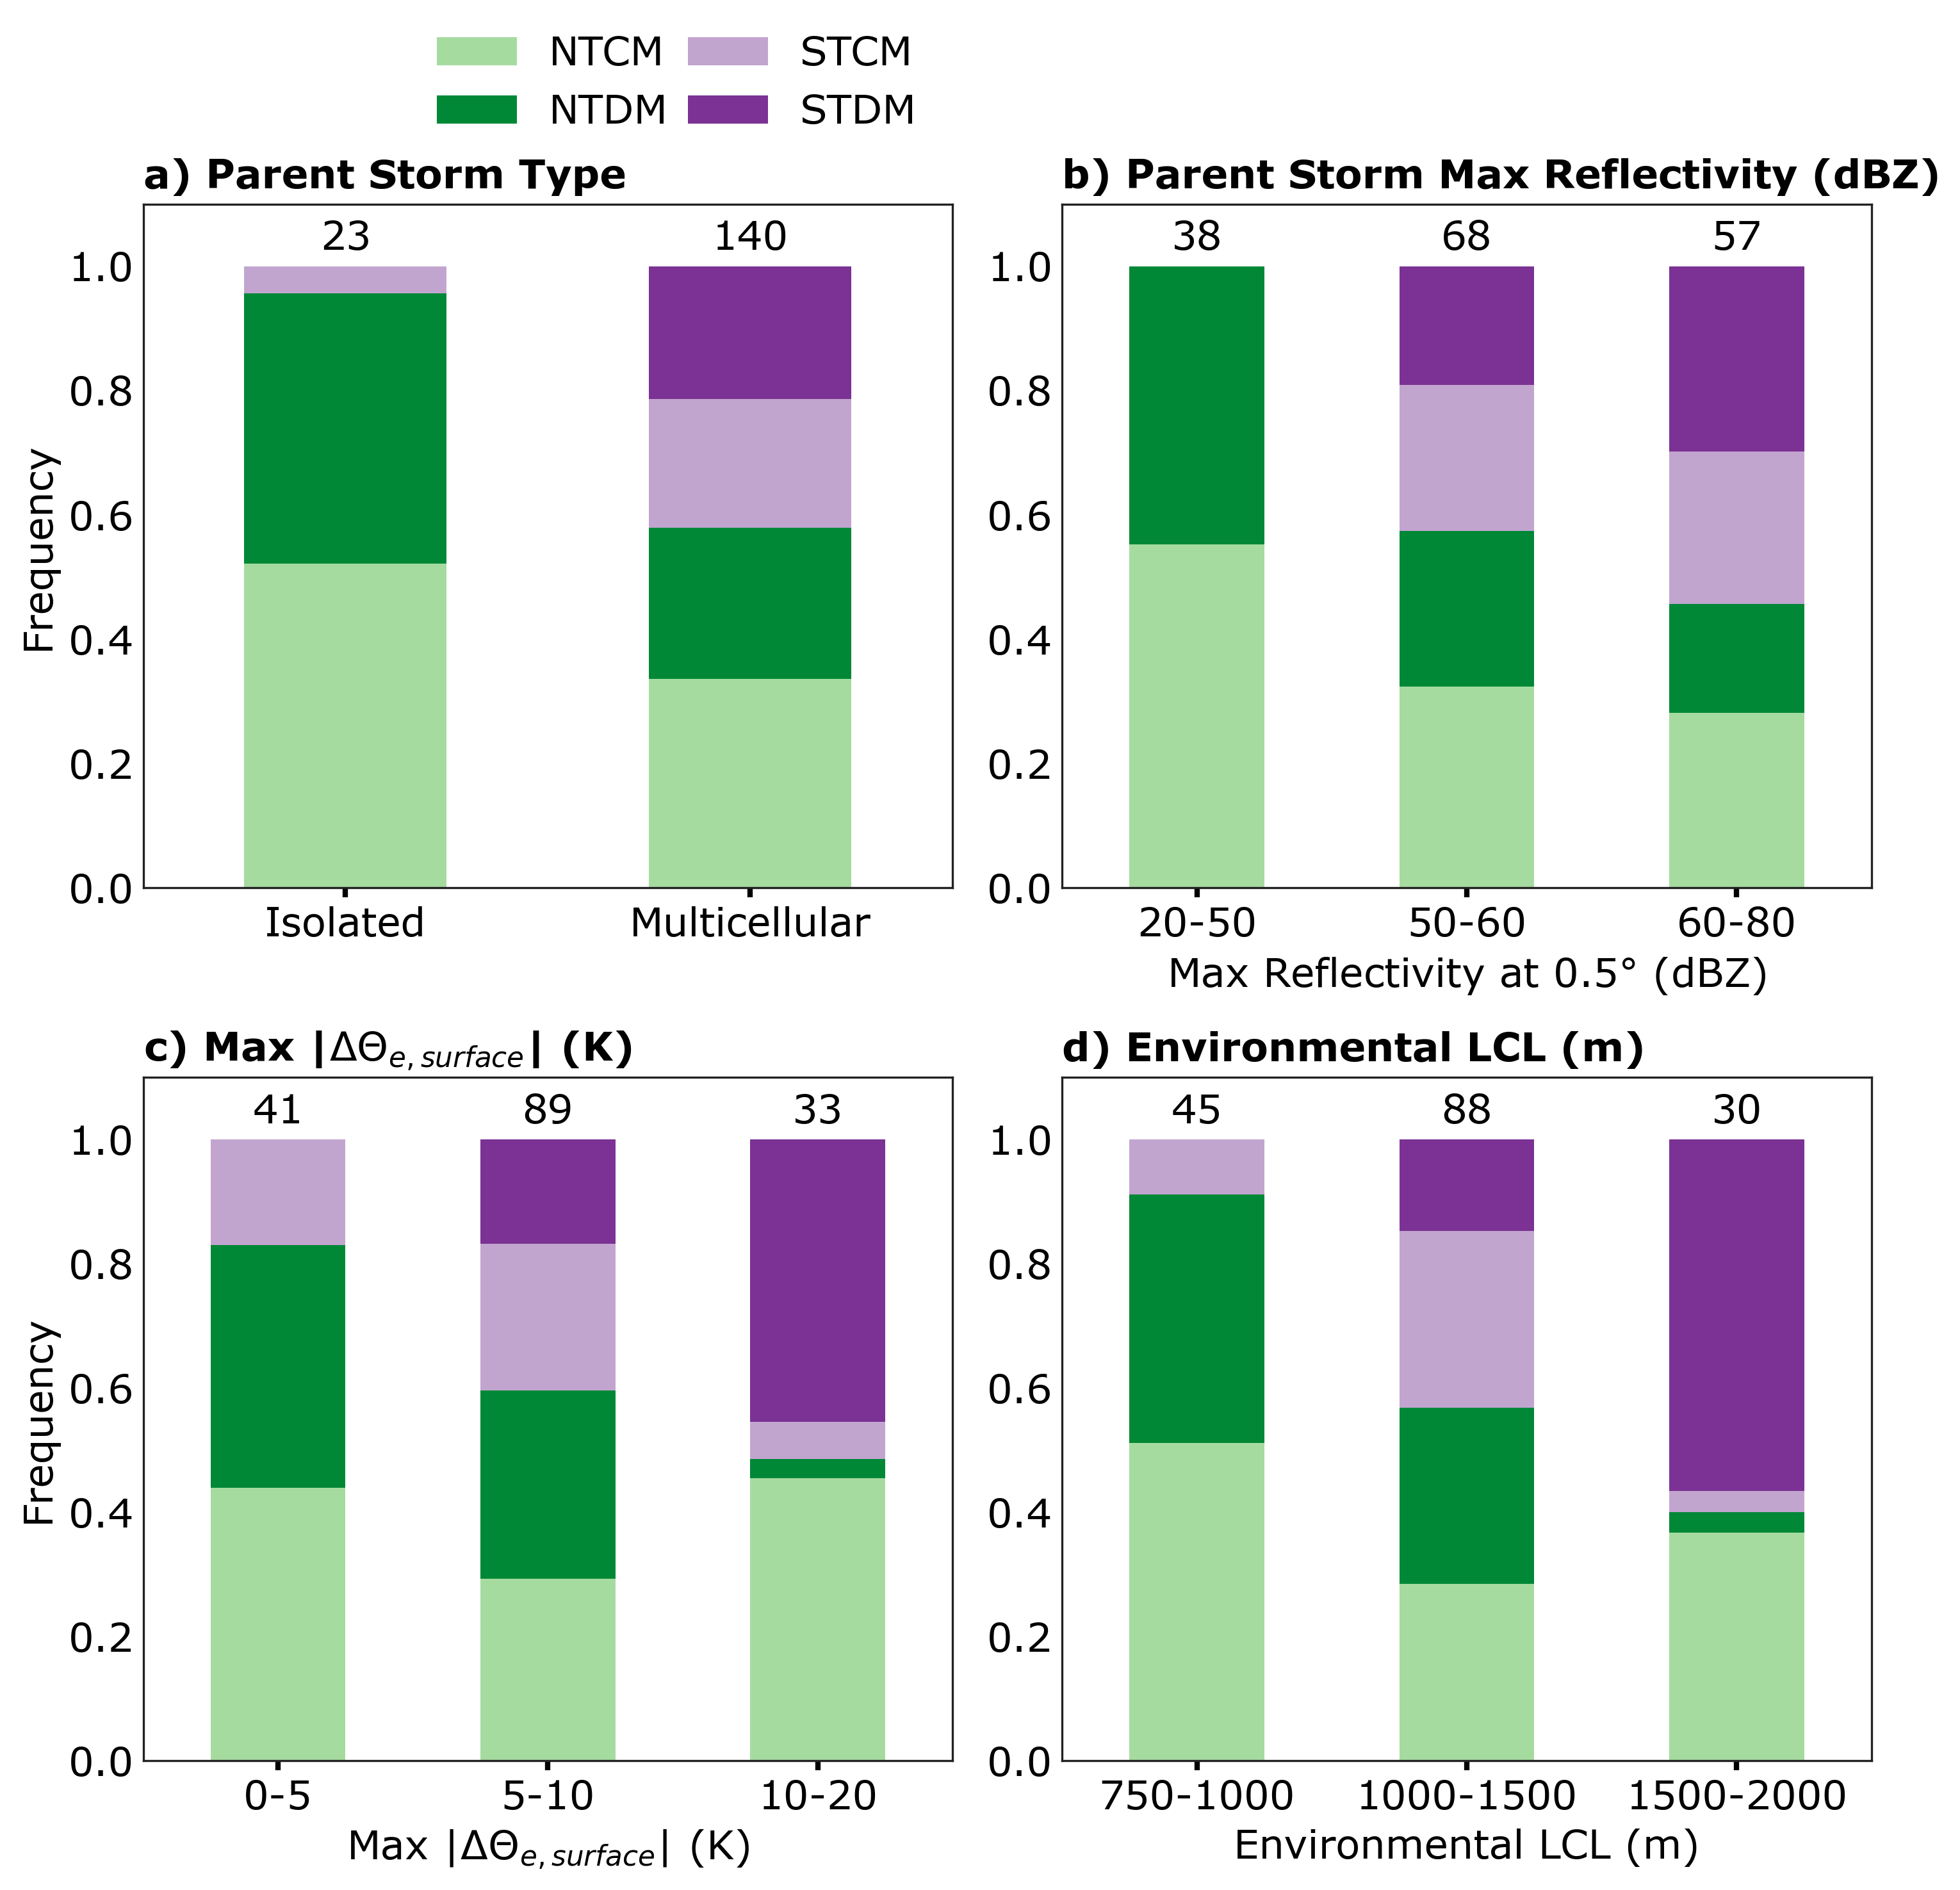

In [197]:
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12)
fig, axes = plt.subplots(2,2,figsize = (10,10))
# cmap = YGB_cmap_r2
matplotlib.rc('xtick', labelsize=15) 
matplotlib.rc('ytick', labelsize=15)
ax1 = axes[0][0]
ax2 = axes[0][1]
ax3 = axes[1][0]
ax4 = axes[1][1]
ps_types = ["Multicellular","Isolated"]
# df_grouped = post_CP_log.groupby("4cluster_minmax_CPonly_mode1_zonly2_labels")["PS"].value_counts(normalize=True).unstack("PS")
df_grouped = post_CP_log.groupby("PS")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("PS")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(2):
    counts.append(round(df_grouped_counts.groupby("PS").sum().iloc[i].sum()))
df_grouped.plot.bar(stacked=True, cmap = cluster_cmap2, ax = ax1)
ax1.bar_label(ax_con.containers[-1], padding=3, labels = counts, fontsize = 15)
ax1.legend(bbox_to_anchor=(1., 1.3),ncols = 2,columnspacing = 0.5, fontsize = 15)
# ax1.legend().remove()
ax1.set_xlabel("")
ax1.tick_params(axis='x', labelrotation= 0)
ax1.set_xticklabels(["Isolated", "Multicellular"])
# for xtick, color in zip(ax1.get_xticklabels(), cluster_colors2):
#     xtick.set_color(color)
ax1.set_ylabel("Frequency", fontsize = 15)
# ax1.set_title("a) PS Type", fontsize = 15)
ax1.set_title("a) Parent Storm Type", fontsize = 15)
ax1.set_ylim(0,1.1)

bins_dbz = [20,50,60,80]
labels_dbz = [ '20-50', '50-60', '60-80'] 
post_CP_log["dBz_bins"] = pd.cut(post_CP_log["dBZ"],bins_dbz, labels = labels_dbz)
# df_grouped = post_CP_log.groupby("4cluster_minmax_CPonly_mode1_zonly2_labels")["dBz_bins"].value_counts(normalize=True).unstack("dBz_bins")
df_grouped = post_CP_log.groupby("dBz_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("dBz_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("dBz_bins").sum().iloc[i].sum())
df_grouped.plot.bar(stacked=True,cmap = cluster_cmap2, ax = ax2)
ax2.bar_label(ax_con.containers[-1], padding=3, labels = counts, fontsize = 15)
# ax2.legend(bbox_to_anchor=(1.1, -.05),ncols = 3,columnspacing = 0.5, fontsize = 15)
ax2.set_xlabel("")
ax2.set_xlabel(f"Max Reflectivity at 0.5$\degree$ (dBZ)", fontsize = 15)
ax2.tick_params(axis='x', labelrotation= 0)
ax2.legend().remove()
# ax2.legend(bbox_to_anchor=(1., 0.6),ncols = 1,columnspacing = 0.5, fontsize = 15)
# for xtick, color in zip(ax2.get_xticklabels(), cluster_colors2):
#     xtick.set_color(color)
# ax2.set_ylabel("Frequency", fontsize = 15)
# ax2.set_title(f"b) PS Max Reflectivity at 0.5$\degree$ (dBZ)", fontsize = 15)
ax2.set_title(f"b) Parent Storm Max Reflectivity (dBZ)", fontsize = 15)
ax2.set_ylim(0,1.1)
# bins = [-20,-10, -5, 0]
# labels_dte = ['> 10', '5 - 10' ,'0 - 5']
bins = [0,5,10, 20]
labels_dte = ['0-5', '5-10' ,'10-20']
post_CP_log["dte_bins"] = pd.cut(-post_CP_log["min dte"],bins, labels = labels_dte)
# df_grouped = post_CP_log.groupby("4cluster_minmax_CPonly_mode1_zonly2_labels")["dte_bins"].value_counts(normalize=True).unstack("dte_bins")
df_grouped = post_CP_log.groupby("dte_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("dte_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("dte_bins").sum().iloc[i].sum())
c = df_grouped.plot.bar(stacked=True, cmap = cluster_cmap2, ax = ax3)
ax3.bar_label(ax_con.containers[-1], padding=3, labels = counts, fontsize = 15)
# ax3.legend(bbox_to_anchor=(0.95, -.05),ncols = 3,columnspacing = 0.5, fontsize = 15)
ax3.set_xlabel(r"Max |$\Delta\Theta_{e,surface}$| (K)", fontsize = 15)
ax3.legend().remove()
# ax3.legend(bbox_to_anchor=(2, -0.15),ncols = 4,columnspacing = 1, fontsize = 15)
ax3.tick_params(axis='x', labelrotation= 0)
# for xtick, color in zip(ax3.get_xticklabels(), cluster_colors2):
#     xtick.set_color(color)
ax3.set_ylabel("Frequency", fontsize = 15)
ax3.set_title(r"c) Max |$\Delta\Theta_{e,surface}$| (K)", fontsize = 15)
ax3.set_ylim(0,1.1)

bins = [750,1000,1500,2000]
labels_lcl = ['750-1000', '1000-1500','1500-2000']
post_CP_log["lcl_bins"] = pd.cut(post_CP_log["LCL"],bins, labels = labels_lcl)
# df_grouped = post_CP_log.groupby("4cluster_minmax_CPonly_mode1_zonly2_labels")["lcl_bins"].value_counts(normalize=True).unstack("lcl_bins")
df_grouped = post_CP_log.groupby("lcl_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=True).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
df_grouped_counts = post_CP_log.groupby("lcl_bins")["4cluster_minmax_CPonly_mode1_zonly2_labels"].value_counts(normalize=False).unstack("4cluster_minmax_CPonly_mode1_zonly2_labels")
counts = []
for i in range(3):
    counts.append(df_grouped_counts.groupby("lcl_bins").sum().iloc[i].sum())
df_grouped.plot.bar(stacked=True, cmap = cluster_cmap2, ax=ax4)
ax4.bar_label(ax_con.containers[-1], padding=3, labels = counts, fontsize = 15)
# ax4.legend(bbox_to_anchor=(1.3, -.05),ncols = 3,columnspacing = 0.5, fontsize = 15)
ax4.set_xlabel("Environmental LCL (m)", fontsize = 15)
ax4.tick_params(axis='x', labelrotation= 0)
ax4.legend().remove()
# for xtick, color in zip(ax4.get_xticklabels(), cluster_colors2):
#     xtick.set_color(color)
# ax4.set_ylabel("Frequency")
ax4.set_title("d) Environmental LCL (m)", fontsize = 15)
ax4.set_ylim(0,1.1)
fig.subplots_adjust(wspace=0.0, hspace=0.0)
# fig.legend()


fig.savefig(f"{figPath}figure5_poster_08202026", dpi = 600)

## Code for Figures 9-11

In [25]:
subset_temp = post_CP_log[["4cluster_minmax_CPonly_mode1_zonly2_labels", "dBz_bins", "lcl_bins", "dte_bins", "dT_bins", "dT2_bins", "dMR_bins", "dMR2_bins"]]
# subset_temp

In [26]:
all_bins = {"dBz_bins":labels_dbz,
            "lcl_bins":labels_lcl,
            "dte_bins":labels_dte,
            "dT_bins":labels_dT,
            "dT2_bins":labels_dt2,
           "dMR_bins": labels_MR,
           "dMR2_bins":labels_dMR}
    

In [27]:
def annotate_heatmap(im, data=None, valfmt = "{x:.0f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """
    try:
        data = data.get_array()
    except:
        pass
    if not isinstance(data, (list, np.ndarray)):
        print("test")
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)
    

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

### Code for plotting Figure 9

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/208468094.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/208468094.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/208

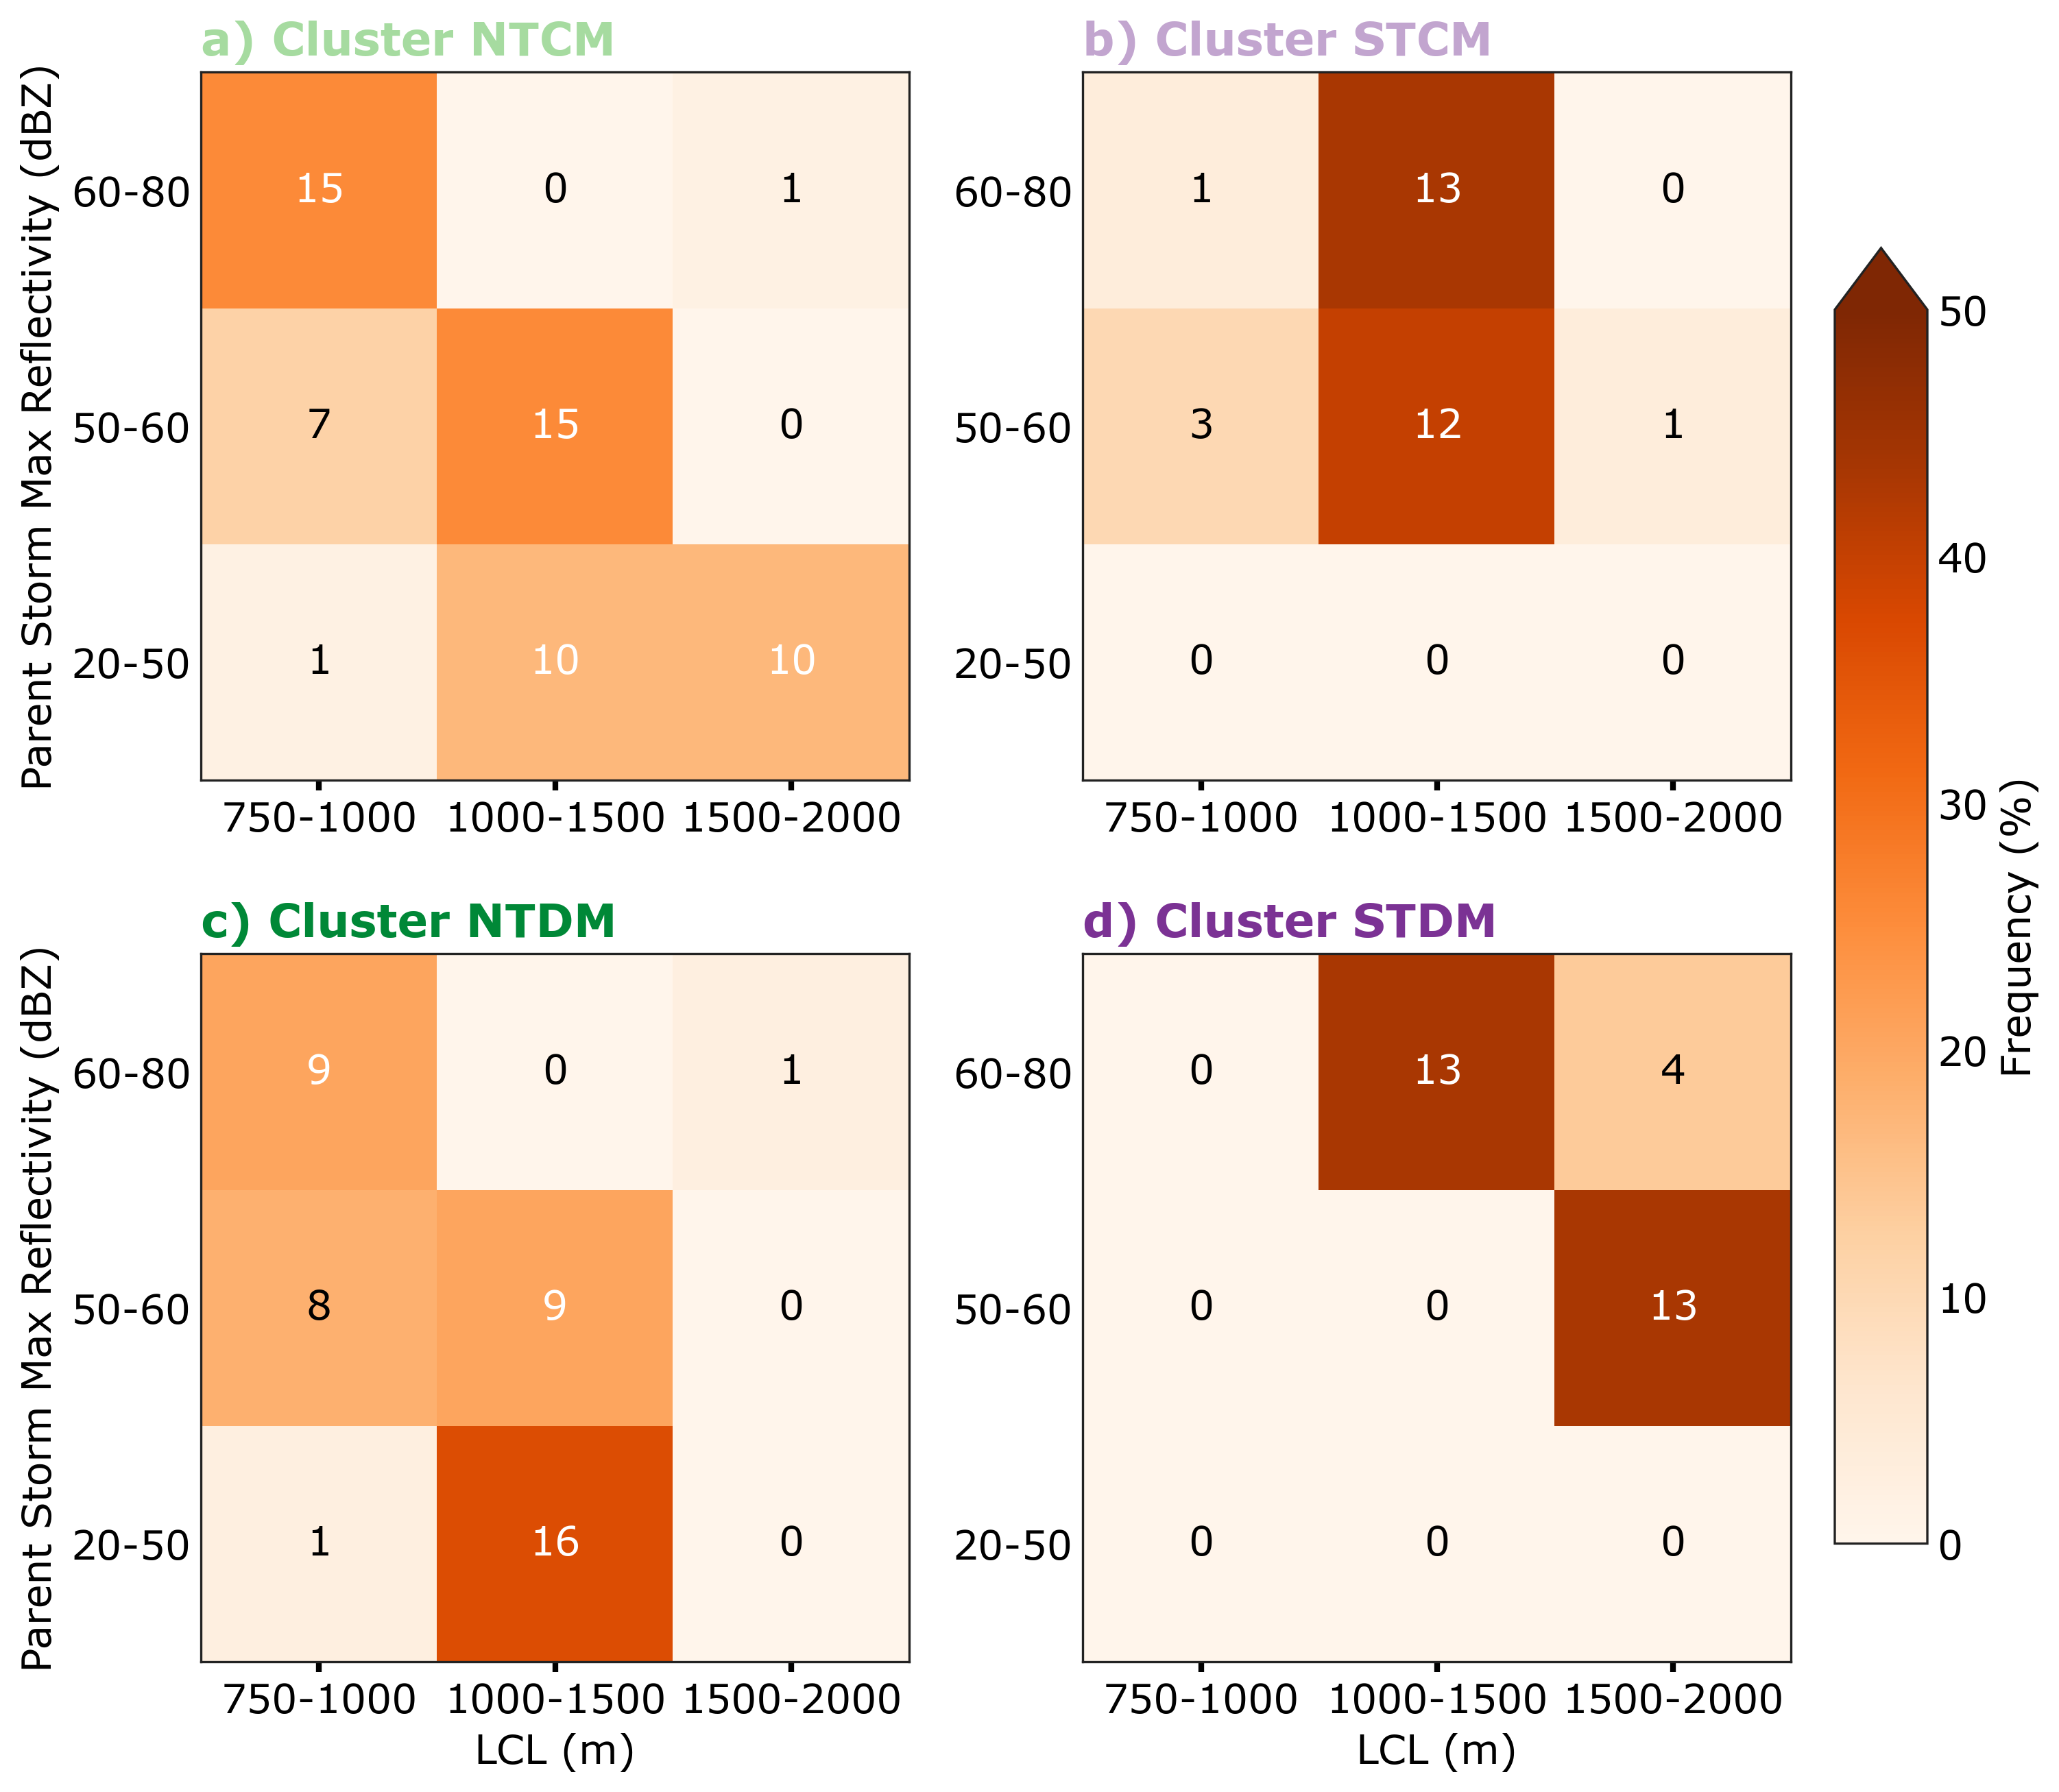

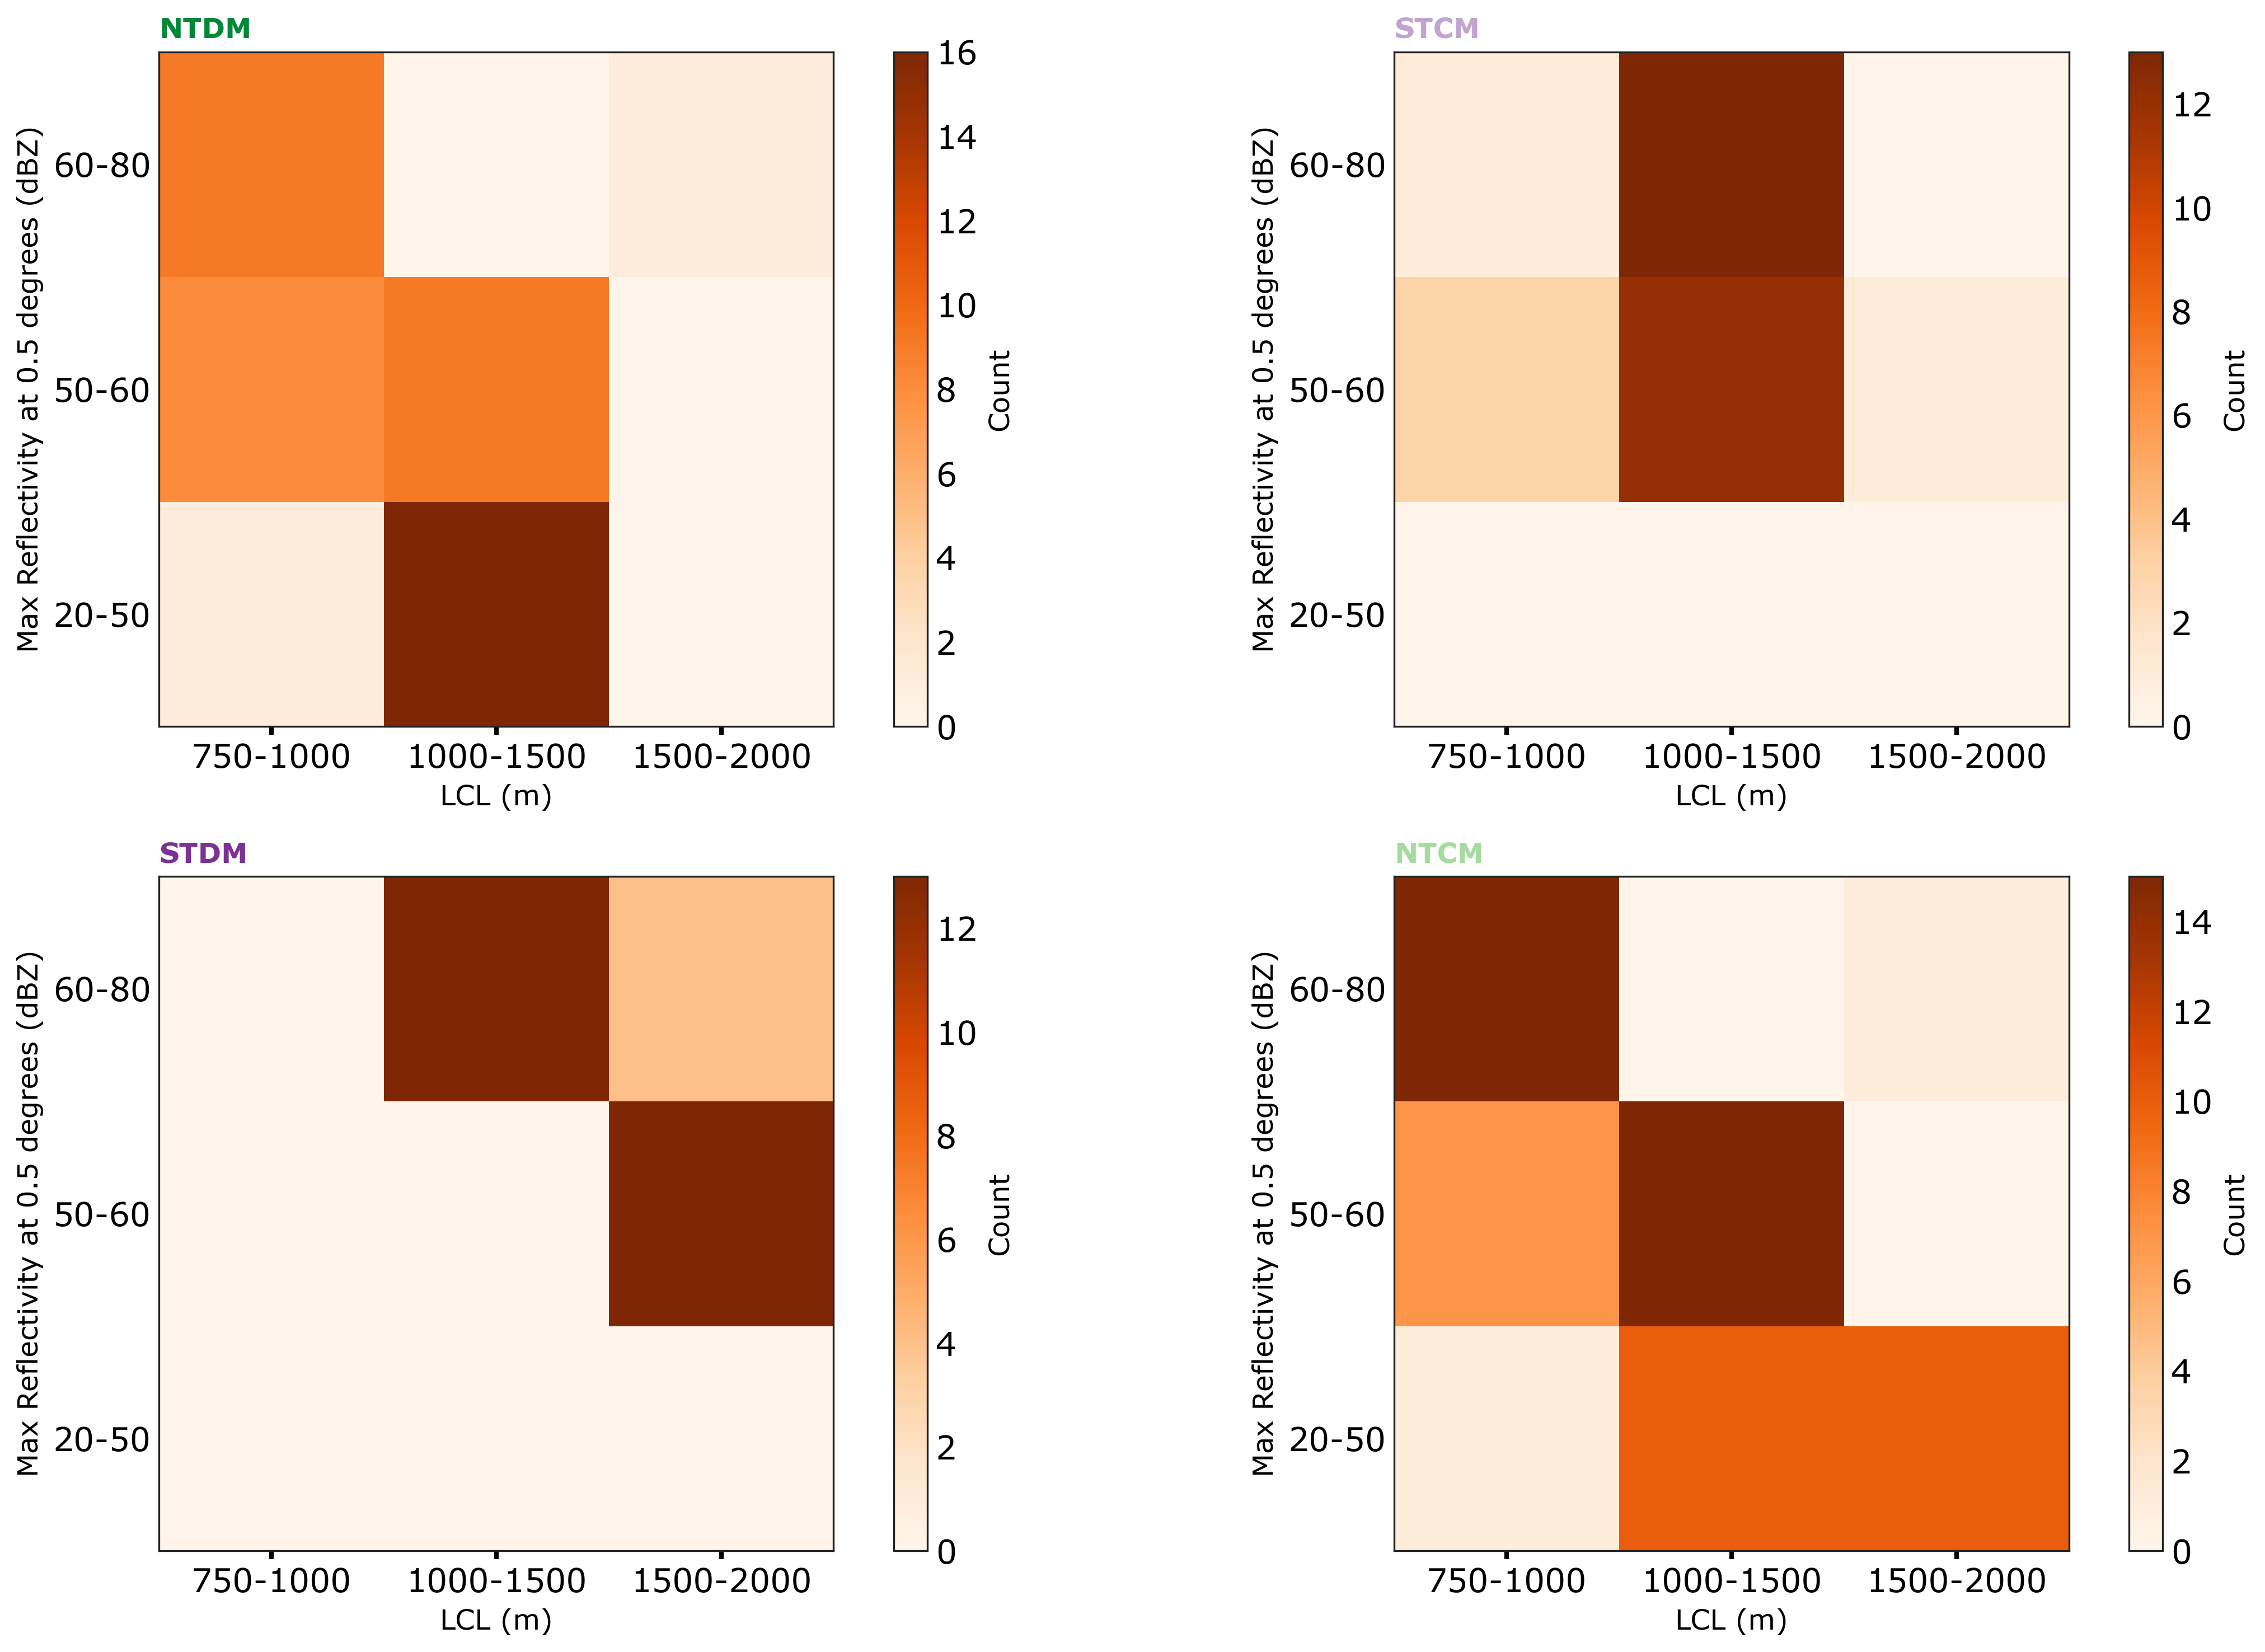

In [201]:
num_levels = 25

# 3. Create a colormap (e.g., 'viridis') and discretize it
cmap = plt.get_cmap('Oranges', num_levels)
cmap = "Oranges"
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14)
# 4. Define the boundaries for the levels
# Boundaries should be N+1 values for N levels.
# Here, boundaries are 0, 1, 2, ..., 10.
boundaries = np.linspace(0.5,50,num_levels+1 )
# norm = BoundaryNorm(boundaries, cmap.N, clip=True)
fig1, ax1 = plt.subplots(2,2, figsize = (9,9))#, layout = "constrained")
fig2, ax2 = plt.subplots(2,2)
ax1 = ax1.flatten()
ax2 = ax2.flatten()
ax_list = [ax1[0], ax1[2], ax1[1], ax1[3]]
c_list = ["NTCM", "NTDM", "STCM", "STDM"]
subp_list = ["a)", "c)", "b)", "d)"]
for index, i in enumerate(c_list):
    subset_temp_c = subset_temp[subset_temp["4cluster_minmax_CPonly_mode1_zonly2_labels"]==i]
    for variable,variable_bins in all_bins.items():
        subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
    ax = ax_list[index] #plt.subplot(2,2,i)
    axc = ax2[index-1]
    crosstab_result = pd.crosstab(subset_temp_c["dBz_bins"], subset_temp_c["lcl_bins"], dropna=False, normalize = True)
    crosstab_count = pd.crosstab(subset_temp_c["dBz_bins"], subset_temp_c["lcl_bins"], dropna=False, normalize = False)
    im1 = ax.imshow(crosstab_result*100, origin = "lower", interpolation='nearest', cmap = cmap, vmax = 50)#norm = norm)
    # cbar = ax.figure.colorbar(im1, label = "Frequency (%)", extend = "both")
    # cbar.set_ticks(np.arange(0,51,10))
    ax.set_xticks(ticks = np.arange(len(crosstab_result.columns)), labels = crosstab_result.columns) # Ensure ticks match data
    ax.set_yticks(ticks = np.arange(len(crosstab_result.index)), labels = crosstab_result.index)
    if index == 1 or index ==3:
        ax.set_xlabel("LCL (m)", fontsize = 14)
    if index == 0 or index == 1:
        ax.set_ylabel(f"Parent Storm Max Reflectivity (dBZ)", fontsize = 14)
    
    ax.set_title(subp_list[index]+" Cluster "+ str(i), color = cluster_colors2[index], fontsize = 16)
    
    im2 = axc.imshow(crosstab_count, origin = "lower", interpolation='nearest', cmap = "Oranges")
    texts = annotate_heatmap(im1, data = im2, fontsize = 14)
    axc.figure.colorbar(im2, label = "Count")
    axc.set_xticks(ticks = np.arange(len(crosstab_result.columns)), labels = crosstab_result.columns) # Ensure ticks match data
    axc.set_yticks(ticks = np.arange(len(crosstab_result.index)), labels = crosstab_result.index)
    axc.set_xlabel("LCL (m)")
    axc.set_ylabel("Max Reflectivity at 0.5 degrees (dBZ)")
    axc.set_title(i, color = cluster_colors2[index])
# constrained_layout = True
# plt.tight_layout()
fig1.subplots_adjust(right=0.8)
cbar_ax = fig1.add_axes([1.0, 0.15, 0.05, 0.7])
# cbar = fig1.colorbar(im1, label = "Frequency (%)", extend = "max", ax = [ax1[1], ax1[3]], fraction = 0.2)
cbar = fig1.colorbar(im1, label = "Frequency (%)", extend = "max", cax = cbar_ax)
cbar.set_label("Frequency (%)", fontsize = 14)
cbar.set_ticks(np.arange(0,51,10))
fig1.subplots_adjust(wspace=0.0, hspace=0.0)

# fig1.savefig(f"{figPath}figure6_v5")
# fig2.closefig()
plt.show()
plt.close()
    # print(df_grouped)

### Code for plotting Figure 10

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/499110888.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/499110888.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/499

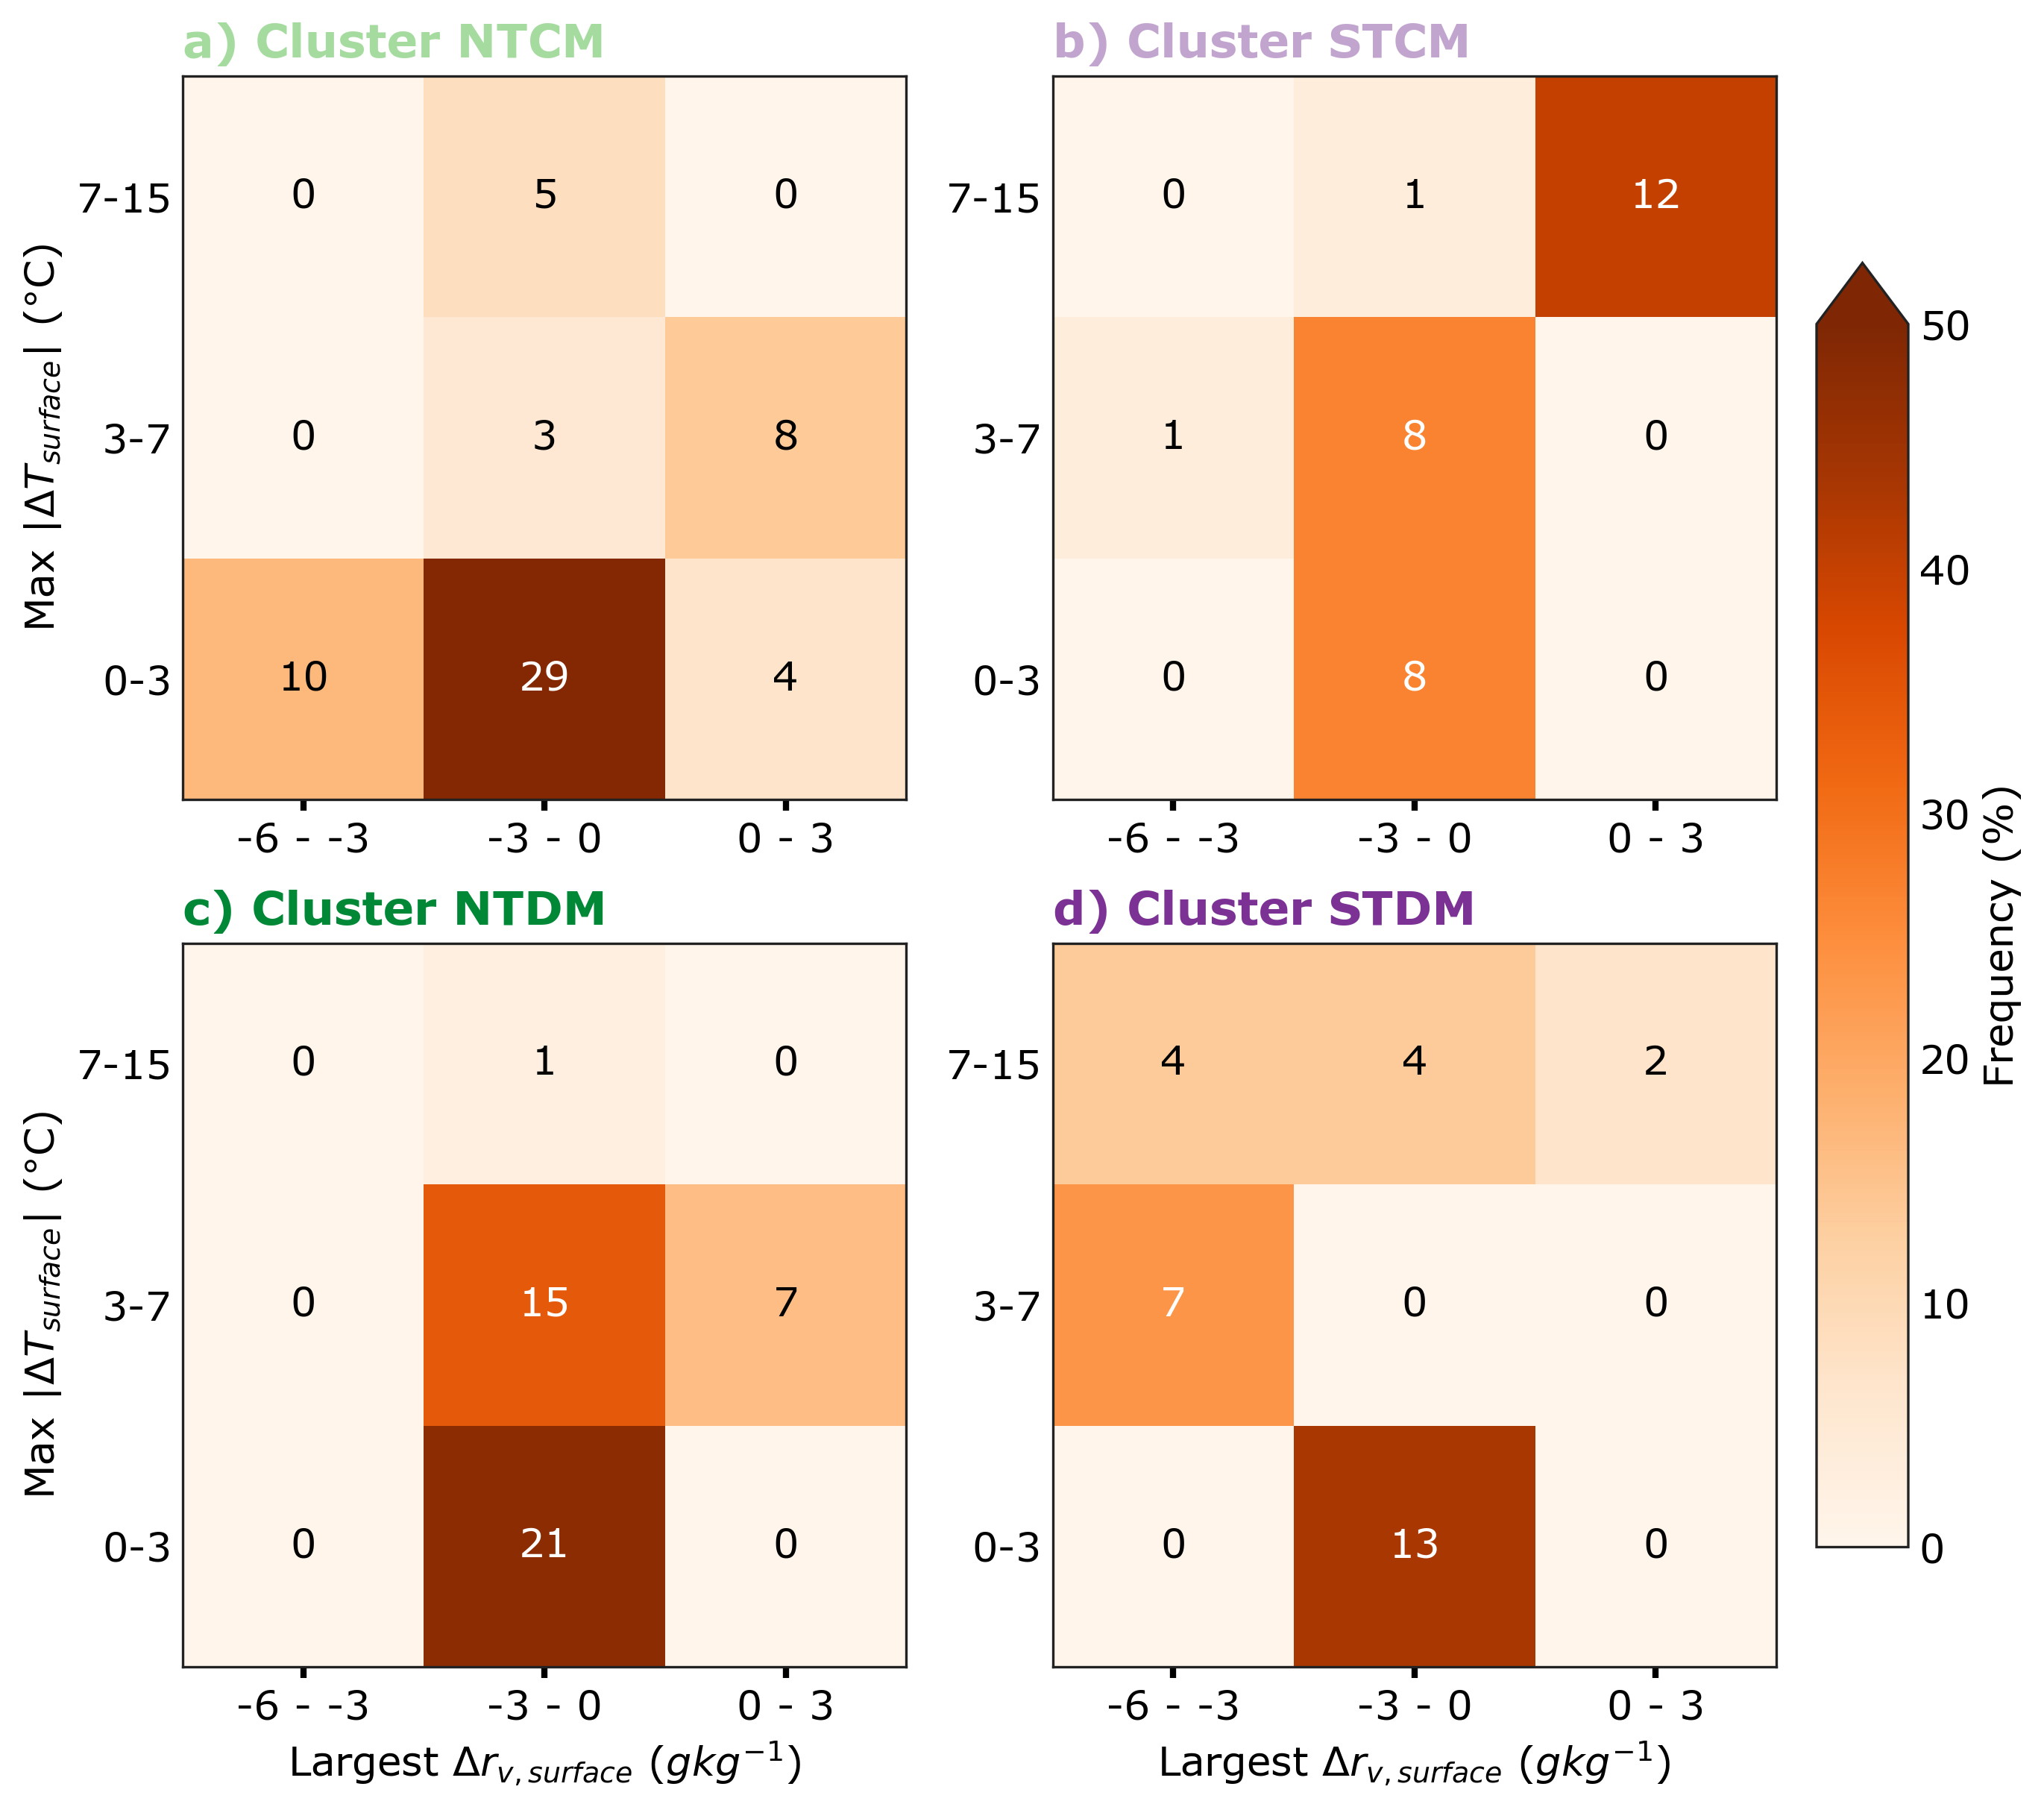

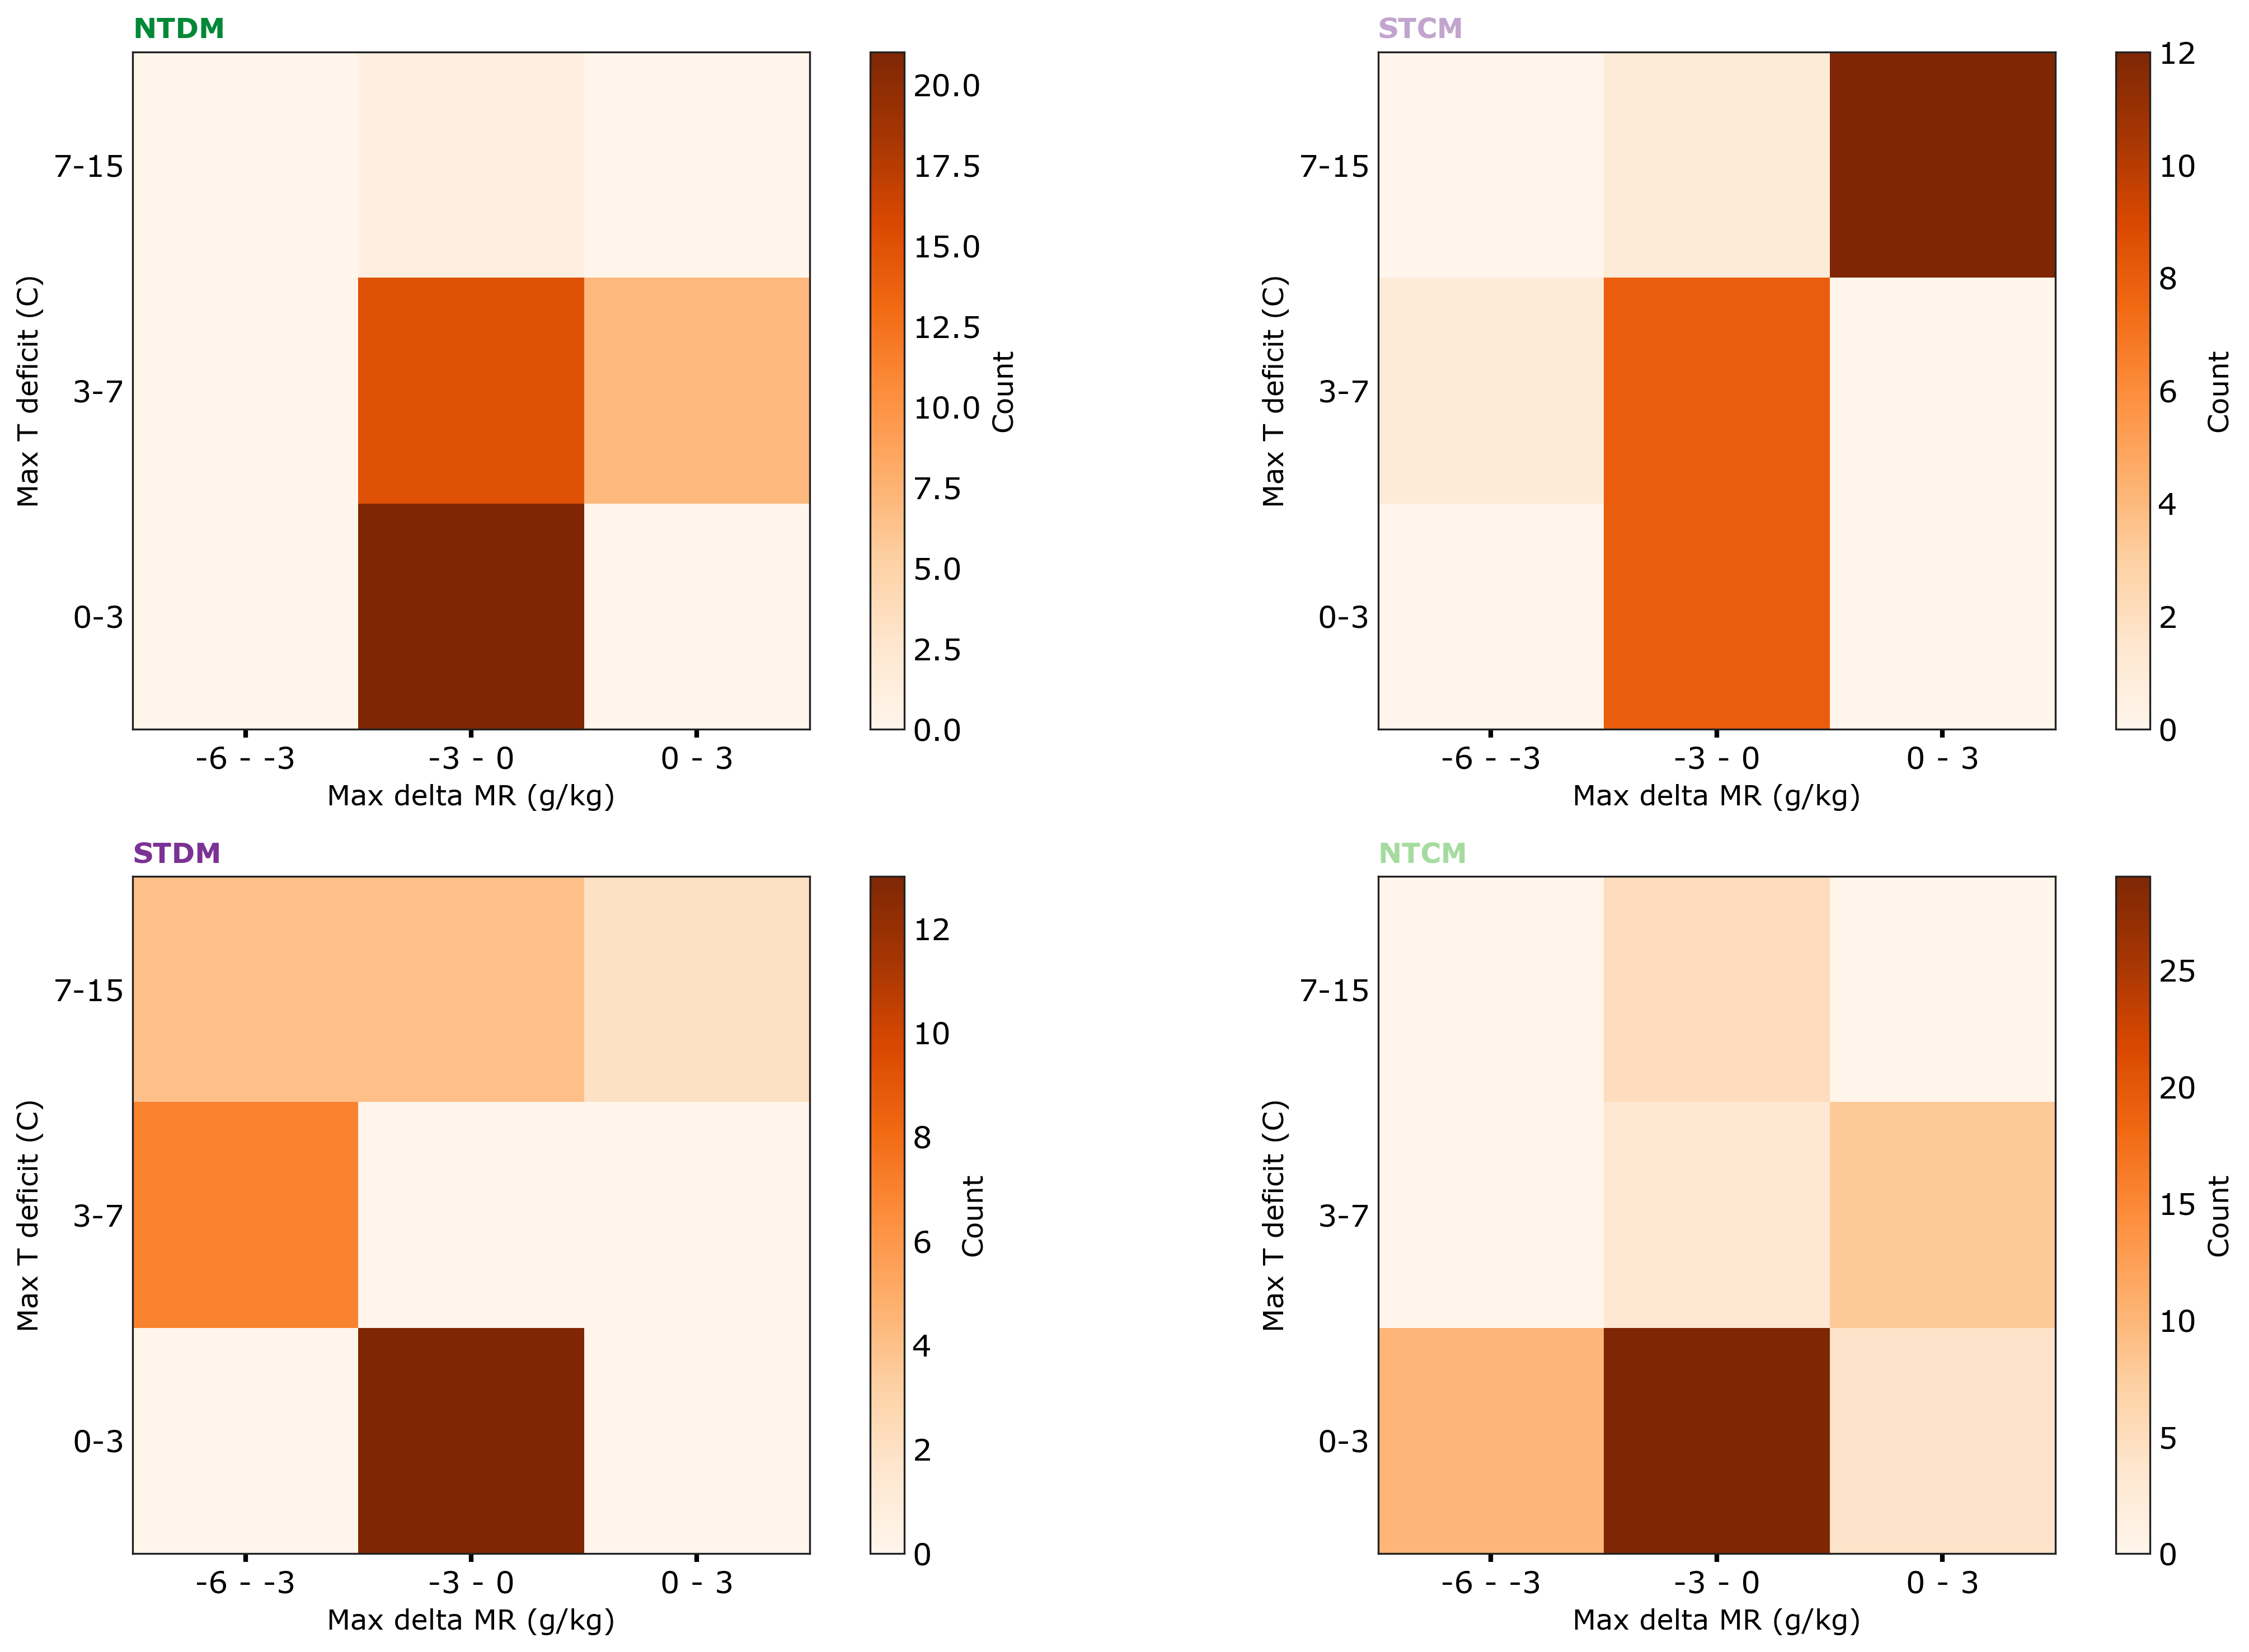

In [209]:
num_levels = 30


cmap = "Oranges"
matplotlib.rc('xtick', labelsize=13) 
matplotlib.rc('ytick', labelsize=13)
# 4. Define the boundaries for the levels
# Boundaries should be N+1 values for N levels.
# Here, boundaries are 0, 1, 2, ..., 10.
boundaries = np.linspace(0.5,50,num_levels+1 )
# norm = BoundaryNorm(boundaries, cmap.N, clip=True)
fig1, ax1 = plt.subplots(2,2, figsize = (8.2,8.2))#, constrained_layout = True)
fig2, ax2 = plt.subplots(2,2)
ax1 = ax1.flatten()
ax2 = ax2.flatten()
ax_list = [ax1[0], ax1[2], ax1[1], ax1[3]]
# c_list = ["NC", "ND", "SC", "SD"]
subp_list = ["a)", "c)", "b)", "d)"]
for index, i in enumerate(c_list):
    subset_temp_c = subset_temp[subset_temp["4cluster_minmax_CPonly_mode1_zonly2_labels"]==i]
    for variable,variable_bins in all_bins.items():
        
        subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
    ax = ax_list[index] #plt.subplot(2,2,i)
    axc = ax2[index-1]
    crosstab_result = pd.crosstab(subset_temp_c["dT_bins"], subset_temp_c["dMR_bins"], dropna=False, normalize = True)
    crosstab_count = pd.crosstab(subset_temp_c["dT_bins"], subset_temp_c["dMR_bins"], dropna=False, normalize = False)
    im1 = ax.imshow(crosstab_result*100, origin = "lower", interpolation='nearest', cmap = cmap, vmax = 50)#norm = norm)

    ax.set_xticks(ticks = np.arange(len(crosstab_result.columns)), labels = crosstab_result.columns) # Ensure ticks match data
    ax.set_yticks(ticks = np.arange(len(crosstab_result.index)), labels = crosstab_result.index)
    if index == 1 or index ==3:
        ax.set_xlabel(r"Largest $\Delta$$r_{v,surface}$ ($g kg^{-1}$)", fontsize = 13)
    if index ==0 or index ==1:
        ax.set_ylabel(r"Max |$\Delta$$T_{surface}$| ($\degree$C)", fontsize = 13)
    
    ax.set_title(subp_list[index]+" Cluster "+ str(i), color = cluster_colors2[index], fontsize = 15 )
    
    im2 = axc.imshow(crosstab_count, origin = "lower", interpolation='nearest', cmap = "Oranges")
    texts = annotate_heatmap(im1, data = im2, fontsize = 13)
    axc.figure.colorbar(im2, label = "Count")
    axc.set_xticks(ticks = np.arange(len(crosstab_result.columns)), labels = crosstab_result.columns) # Ensure ticks match data
    axc.set_yticks(ticks = np.arange(len(crosstab_result.index)), labels = crosstab_result.index)
    axc.set_xlabel("Max delta MR (g/kg)")
    axc.set_ylabel("Max T deficit (C)")
    axc.set_title(i, color = cluster_colors2[index])
    
#
fig1.subplots_adjust(right=0.8)
cbar_ax = fig1.add_axes([1.0, 0.15, 0.05, 0.7])
cbar = ax.figure.colorbar(im1, label = "Frequency (%)", extend = "max", cax = cbar_ax)
cbar.set_label("Frequency (%)", fontsize = 13)
cbar.set_ticks(np.arange(0,51,10))
fig1.subplots_adjust(wspace=0.0, hspace=0.0)
fig1.savefig(f"{figPath}figure9_v7_08242026")
plt.show()
plt.close()



### Code for plotting Figure 11

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/2041268539.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/2041268539.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_84899/2

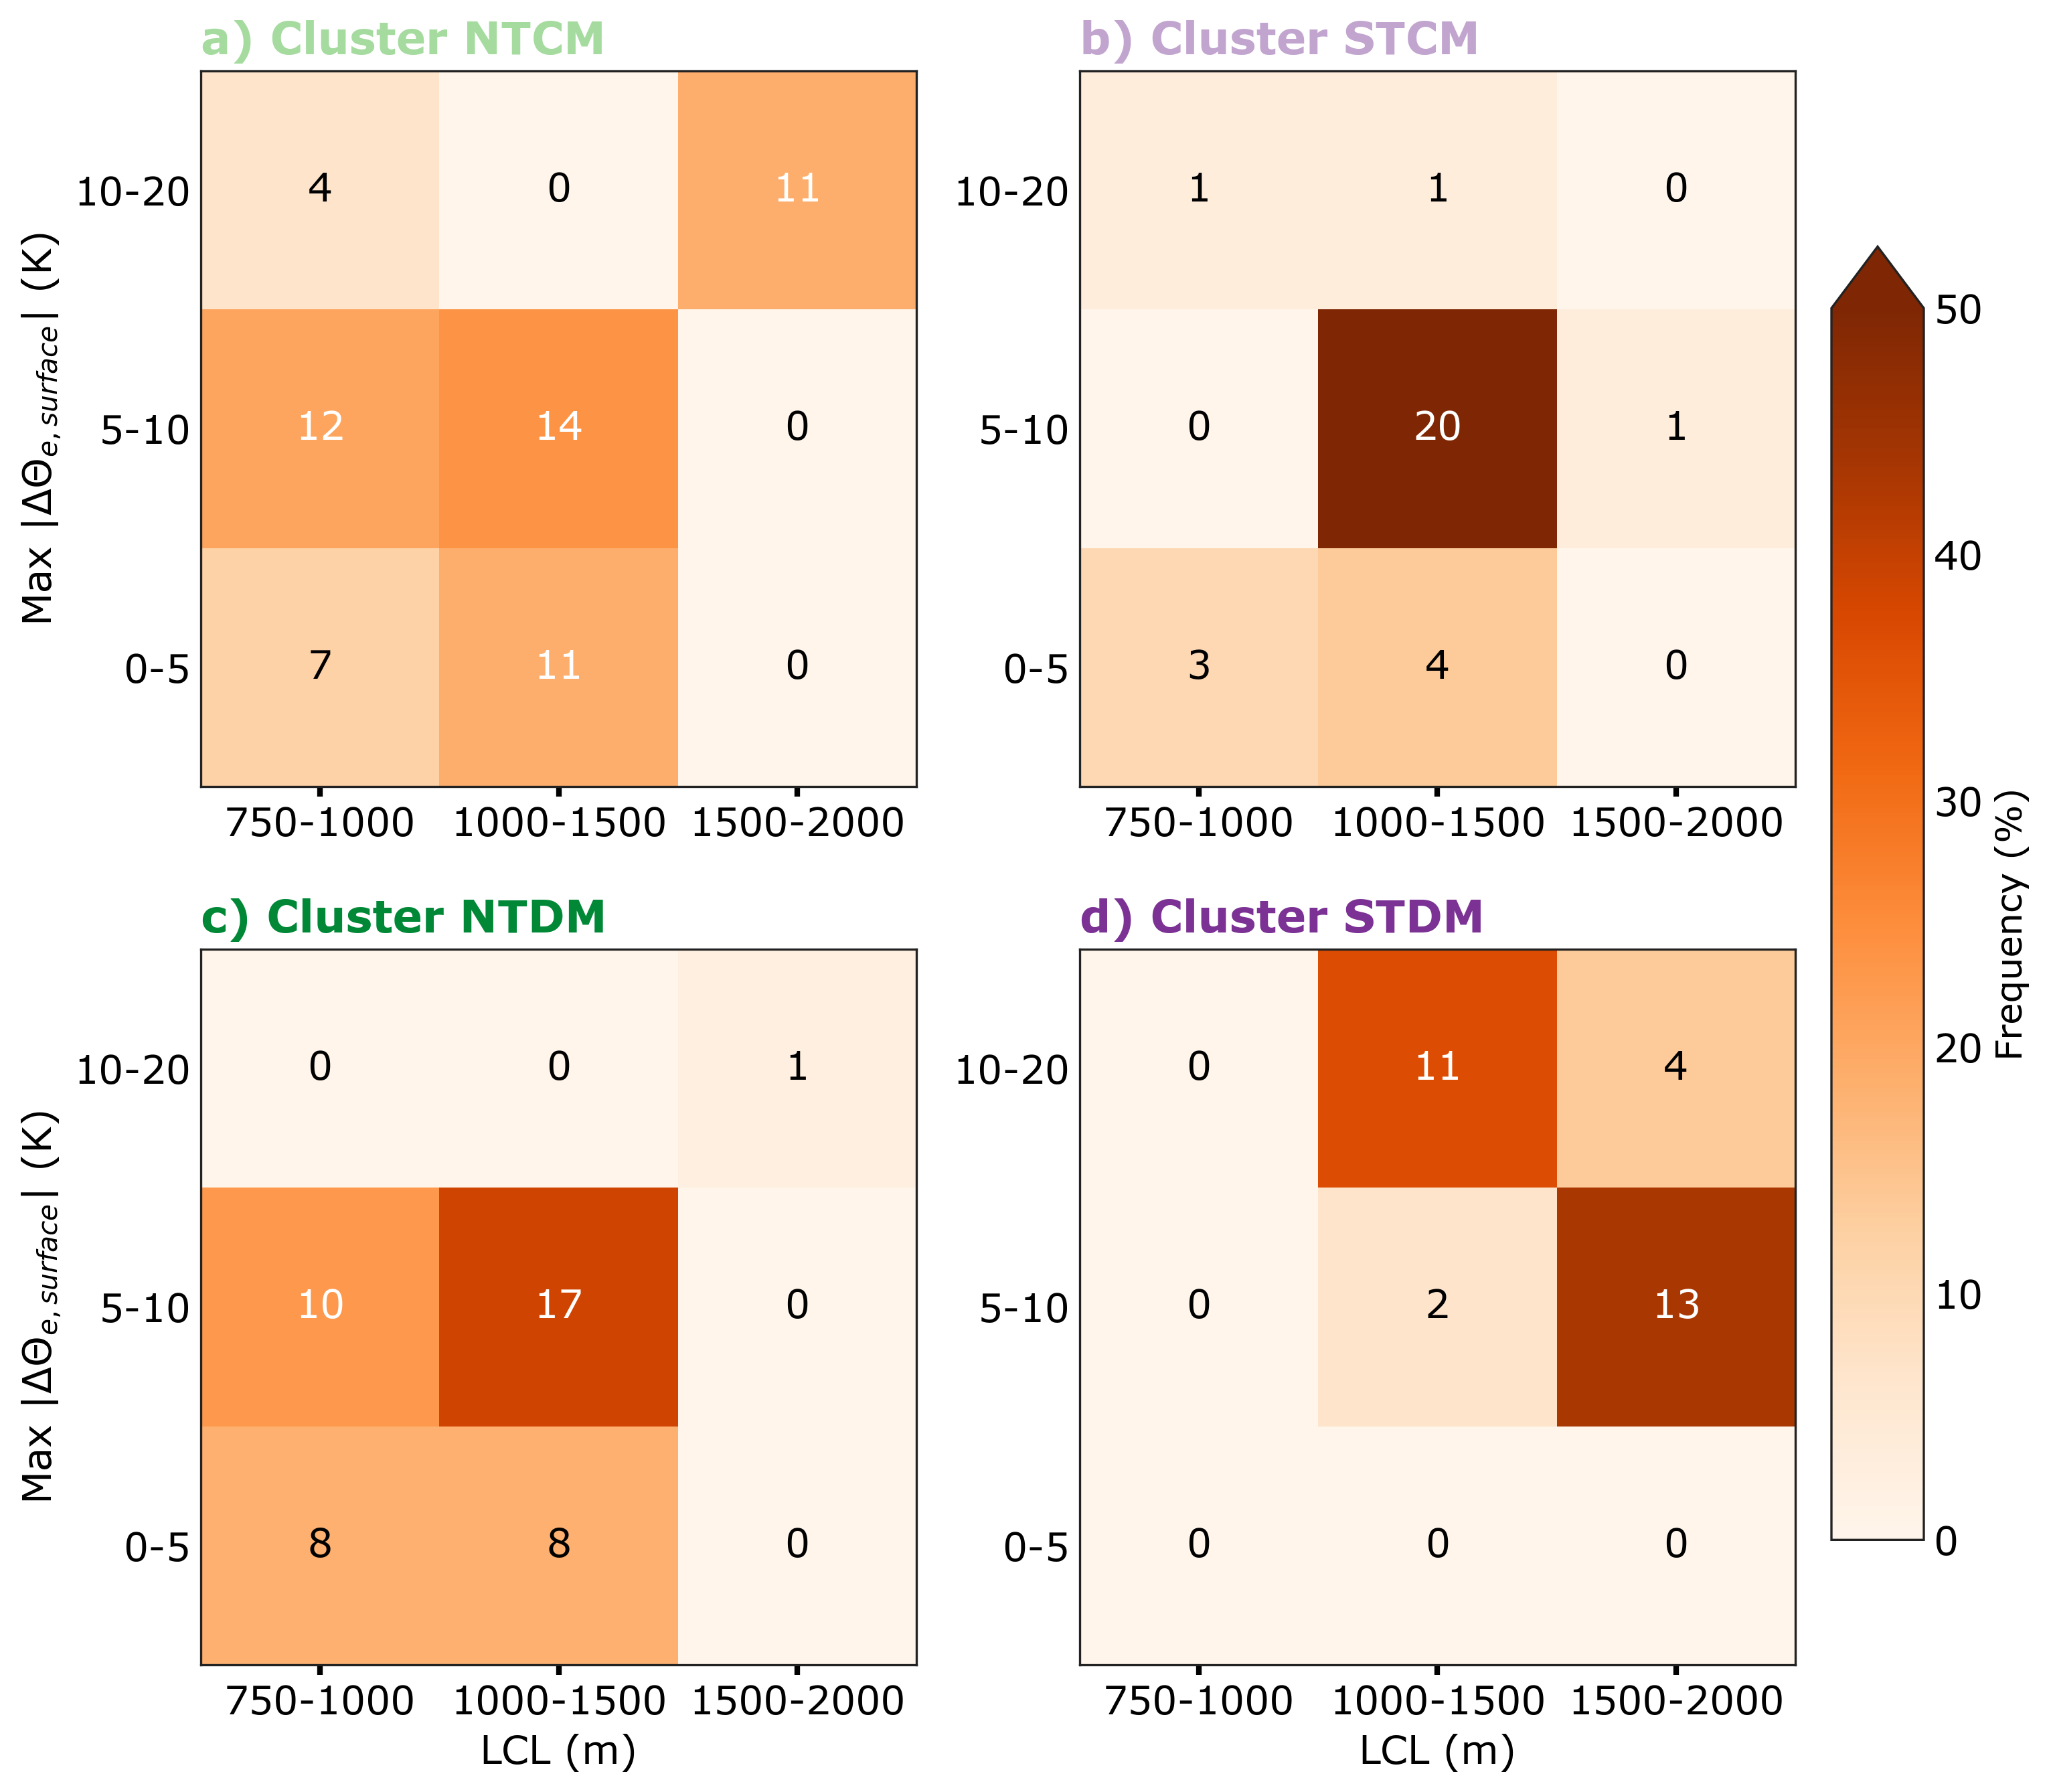

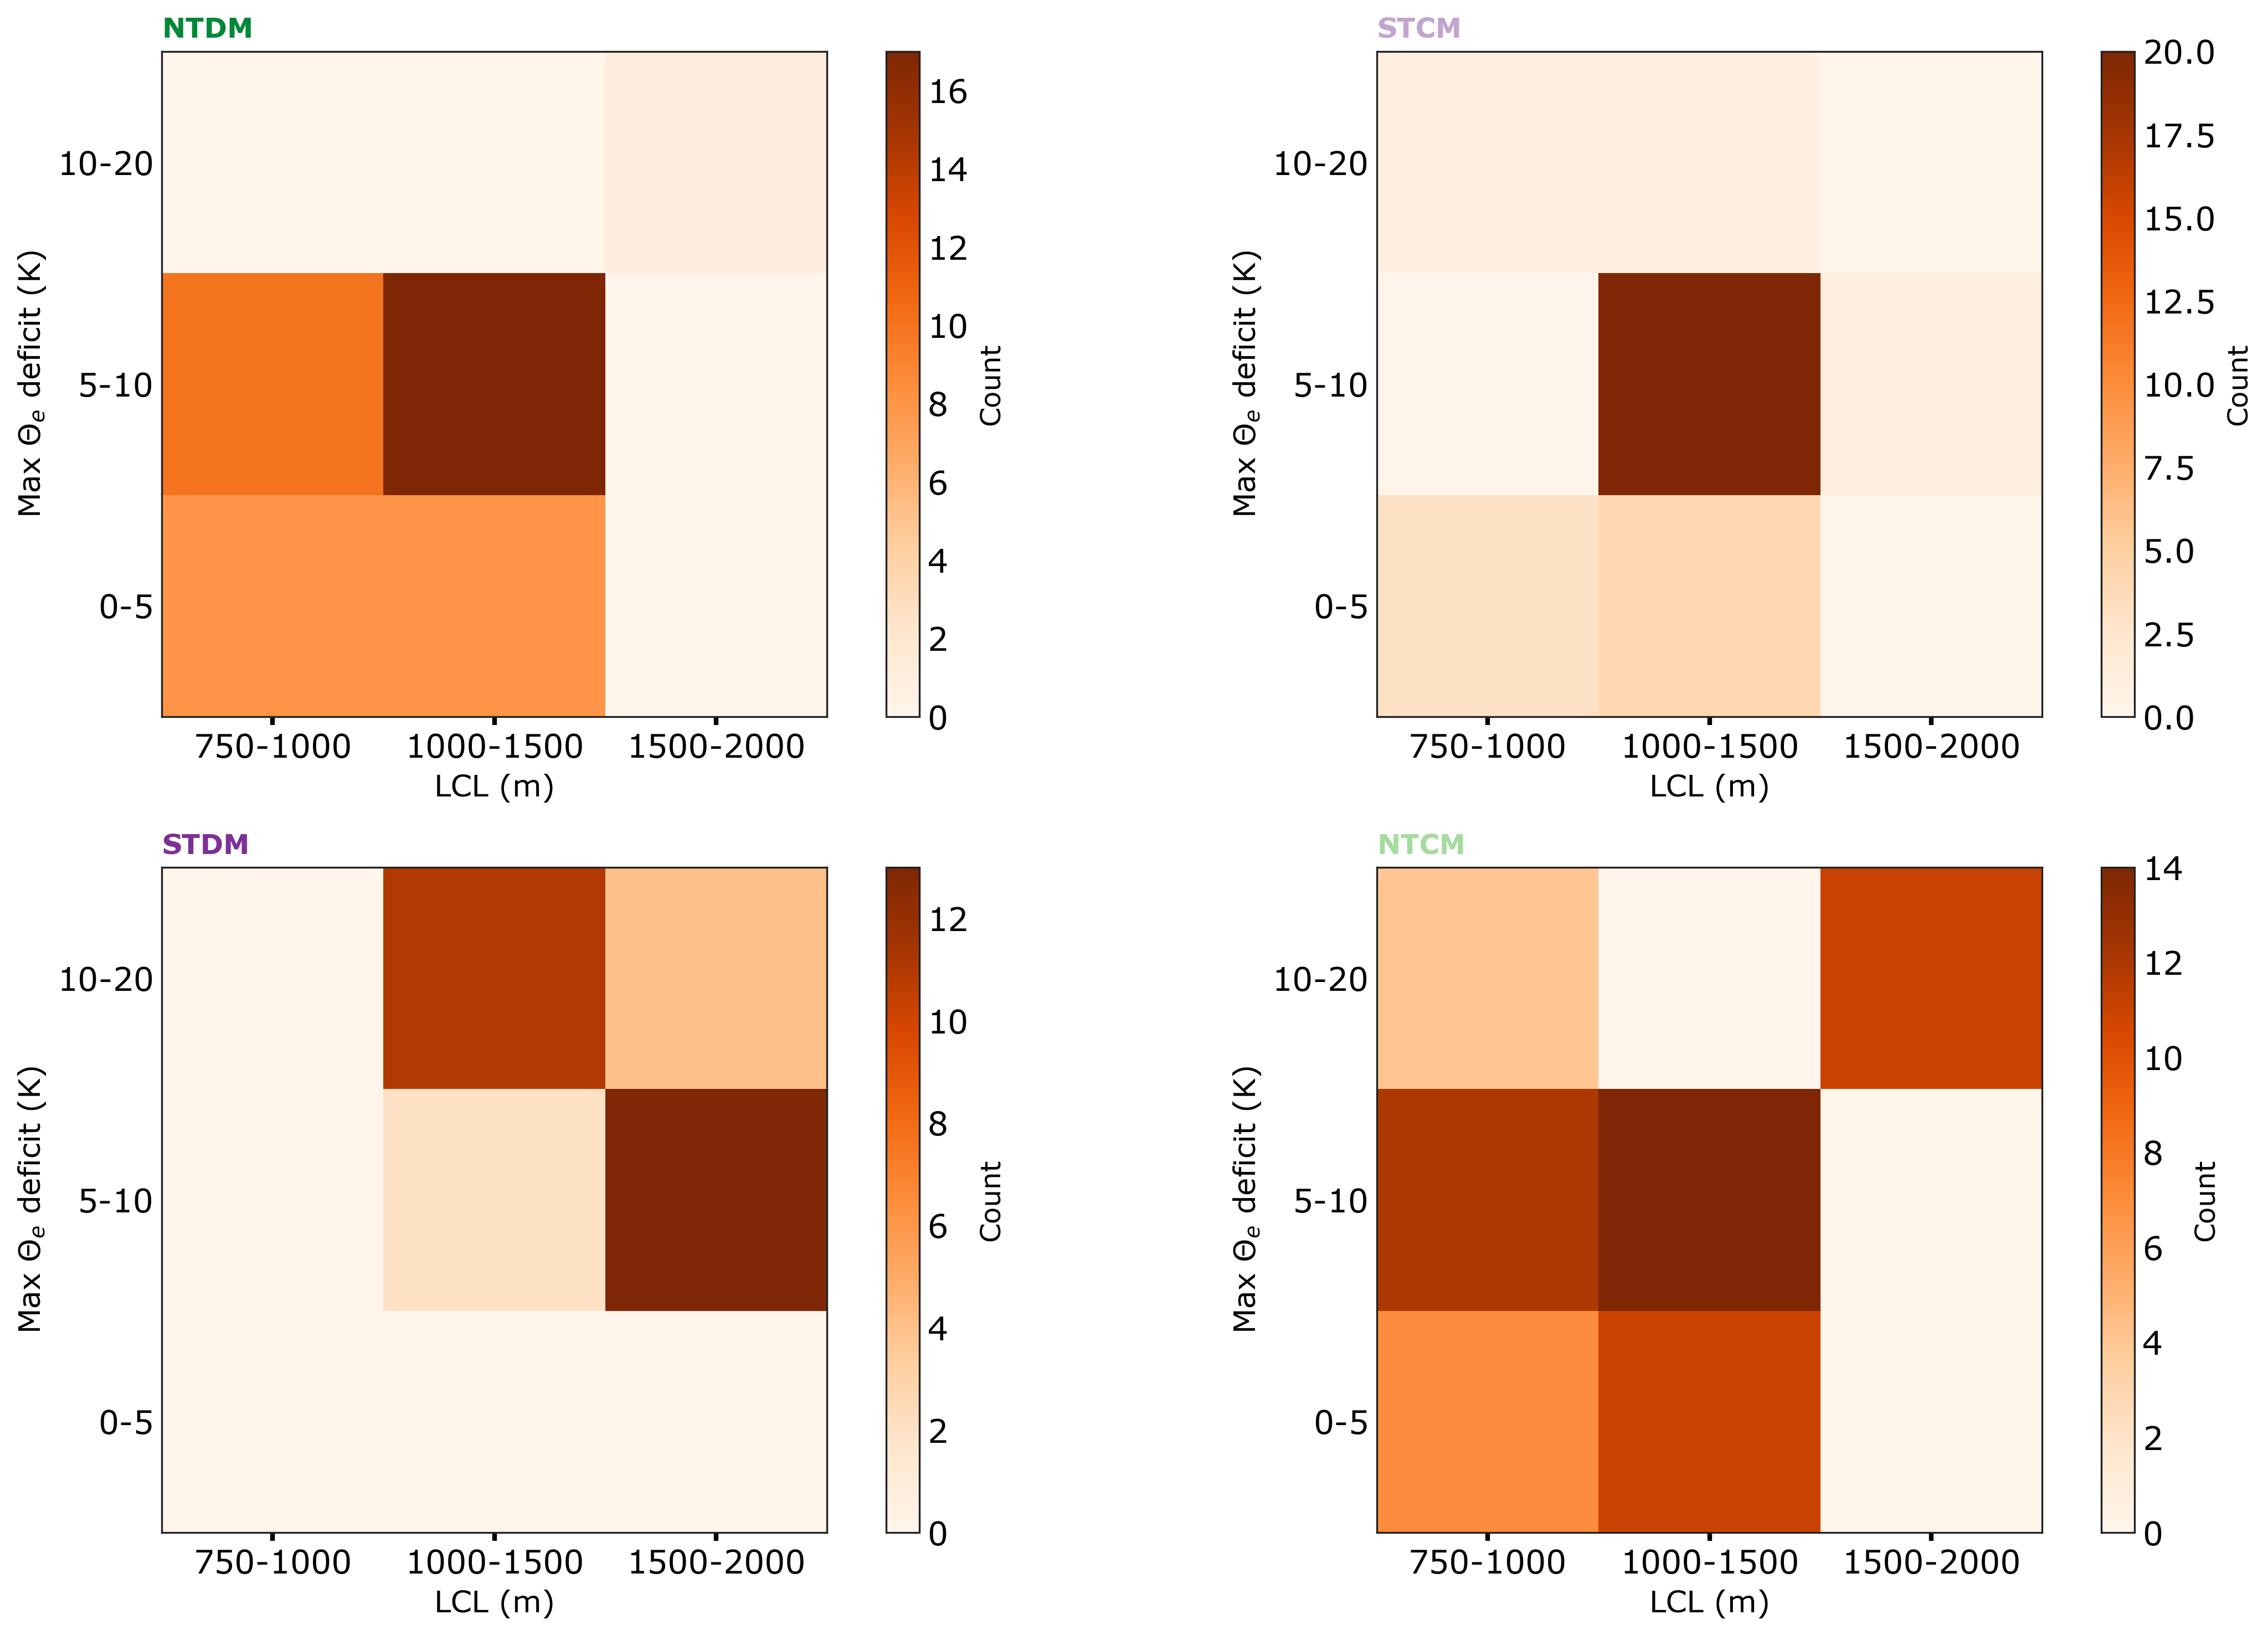

In [208]:


# 3. Create a colormap (e.g., 'viridis') and discretize it
# cmap = plt.get_cmap('Oranges', num_levels)
cmap = "Oranges"

# 4. Define the boundaries for the levels
# Boundaries should be N+1 values for N levels.
# Here, boundaries are 0, 1, 2, ..., 10.
boundaries = np.linspace(0.5,50,num_levels+1 )
# norm = BoundaryNorm(boundaries, cmap.N, clip=True)
fig1, ax1 = plt.subplots(2,2, figsize = (9.2,9.2))
fig2, ax2 = plt.subplots(2,2)
ax1 = ax1.flatten()
ax2 = ax2.flatten()
ax_list = [ax1[0], ax1[2], ax1[1], ax1[3]]
# c_list = ["NC", "ND", "SC", "SD"]
subp_list = ["a)", "c)", "b)", "d)"]
for index, i in enumerate(c_list):
    subset_temp_c = subset_temp[subset_temp["4cluster_minmax_CPonly_mode1_zonly2_labels"]==i]
    for variable,variable_bins in all_bins.items():
        subset_temp_c[variable] = pd.Categorical(subset_temp_c[variable], categories = variable_bins)
    ax = ax_list[index] #plt.subplot(2,2,i)
    axc = ax2[index-1]
    crosstab_result = pd.crosstab(subset_temp_c["dte_bins"], subset_temp_c["lcl_bins"], dropna=False, normalize = True)
    crosstab_count = pd.crosstab(subset_temp_c["dte_bins"], subset_temp_c["lcl_bins"], dropna=False, normalize = False)
    im1 = ax.imshow(crosstab_result*100, origin = "lower", interpolation='nearest', cmap = cmap, vmax = 50)#norm = norm)
    ax.set_xticks(ticks = np.arange(len(crosstab_result.columns)), labels = crosstab_result.columns) # Ensure ticks match data
    ax.set_yticks(ticks = np.arange(len(crosstab_result.index)), labels = crosstab_result.index)
    if index == 0 or index == 1:
        ax.set_ylabel(r"Max |$\Delta$$\Theta_{e,surface}$| (K)", fontsize = 14)
    if index == 1 or index == 3:
        ax.set_xlabel("LCL (m)", fontsize = 14)
    
    ax.set_title(subp_list[index]+" Cluster "+ str(i), color = cluster_colors2[index], fontsize = 16)
    
    im2 = axc.imshow(crosstab_count, origin = "lower", interpolation='nearest', cmap = "Oranges")
    texts = annotate_heatmap(im1, data = im2, fontsize = 14)
    axc.figure.colorbar(im2, label = "Count")
    axc.set_xticks(ticks = np.arange(len(crosstab_result.columns)), labels = crosstab_result.columns) # Ensure ticks match data
    axc.set_yticks(ticks = np.arange(len(crosstab_result.index)), labels = crosstab_result.index)
    axc.set_ylabel(r"Max $\Theta_e$ deficit (K)", fontsize = 13)
    axc.set_xlabel("LCL (m)", fontsize = 13)
    axc.set_title(i, color = cluster_colors2[index])

fig1.subplots_adjust(right=0.8)
cbar_ax = fig1.add_axes([1.0, 0.15, 0.05, 0.7])
cbar = ax.figure.colorbar(im1, label = "Frequency (%)", extend = "max", cax = cbar_ax)
cbar.set_label("Frequency (%)", fontsize = 13)
cbar.set_ticks(np.arange(0,51,10))
fig1.subplots_adjust(wspace=0.0, hspace=0.0)
fig1.savefig(f"{figPath}figure10_v6_08242026")
plt.show()
plt.close()


## Bootstrapping test

In [239]:
P_N = np.empty(10000)
P_N2 = np.empty(10000)
P_S2 = np.empty(10000)
P_S = np.empty(10000)
P_all = np.empty(10000)
# P_N = np.empty(2500)
# P_S = np.empty(2500)
P_diff = np.empty(10000)
sample_len_N = len(post_CP_log2[(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="NTCM")|(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="NTDM")])
sample_len_S = len(post_CP_log2[(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="STCM")| (post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="STDM")])

for j, val in enumerate(P_N):
    sample_N = post_CP_log2.sample(n = sample_len_N, replace = True)
    sample_S = post_CP_log2.sample(n = sample_len_S, replace = True)
    sample_all = post_CP_log2.sample(n = 163, replace = True)
    len_N = (len(sample_N.loc[sample_N.delta_time < datetime.timedelta(minutes = 30)])/sample_len_N)*100
    len_S = (len(sample_S.loc[sample_S.delta_time > datetime.timedelta(minutes = 30)])/sample_len_S)*100
    len_N2 = (len(sample_all.loc[(sample_all["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="NTCM")|(sample_all["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="NTDM")])/163)*100
    len_S2 = 100-len_N2
    # len_N_all =     len_S = (len(sample_S.loc[sample_S.delta_time > datetime.timedelta(minutes = 30)])/163)*100
    P_N[j] = len_N
    P_S[j] = len_S
    P_N2[j] = len_N2
    P_S2[j] = len_S2
    P_diff[j] = len_N-len_S
    
    

In [148]:
N = post_CP_log2[(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="NTCM")|(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="NTDM")]
S = post_CP_log2[(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="STCM")|(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="STDM")]



In [152]:
N_occurance = len(N.loc[N.delta_time < datetime.timedelta(minutes = 30)])/len(N)*100
S_occurance = len(S.loc[S.delta_time > datetime.timedelta(minutes = 30)])/len(S)*100

In [ ]:
len(N.loc[sample_N.delta_time < datetime.timedelta(minutes = 30)]

In [243]:
sample_N_all = sample_len_N/163*100
sample_S_all = sample_len_S/163*100

In [214]:
sample_N_all

63.190184049079754

0.539
63.23104294478528


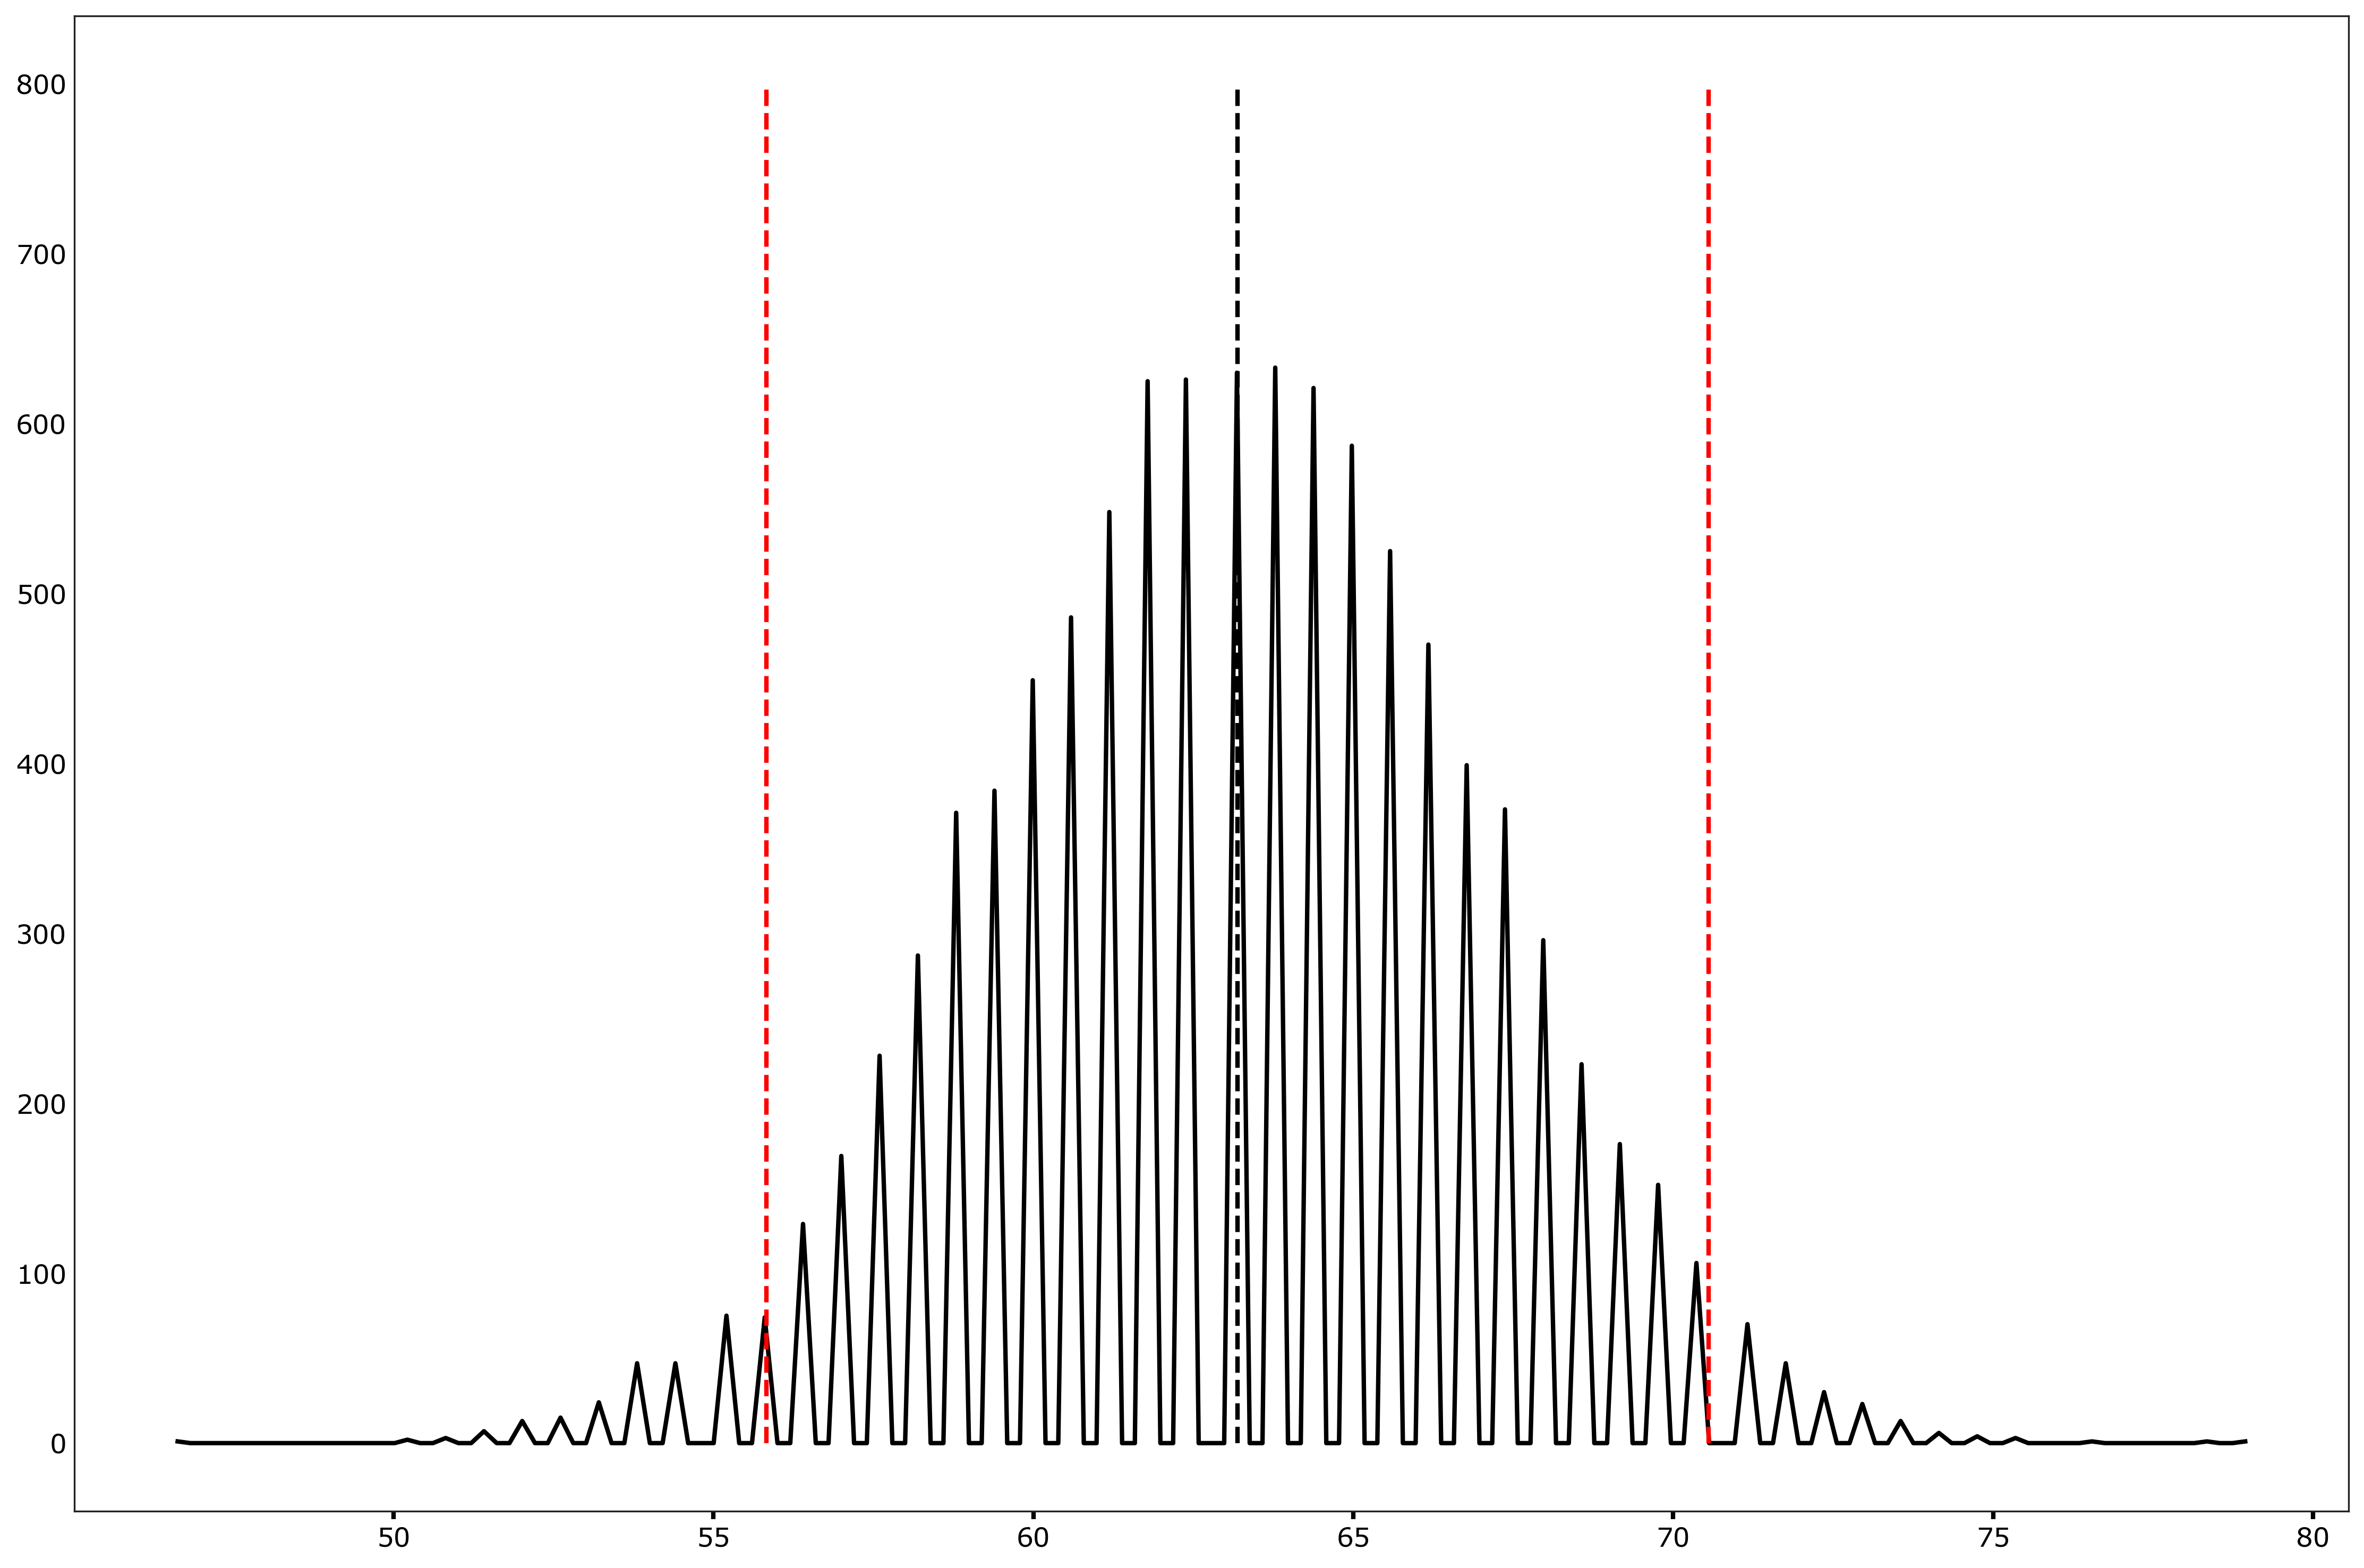

In [240]:
mp = 0
plt.figure()
h, bins = np.histogram(P_N2-mp,163)
plt.plot(bins[:-1], h, color = 'k')
a1 = np.percentile(P_N2-mp, 2.5)
a2 = np.percentile(P_N2-mp, 100-2.5)
plt.vlines(a1,0,800, 'r', linestyle = '--')
plt.vlines(a2,0,800, 'r', linestyle = '--')
plt.vlines(sample_N_all,0,800,'k', linestyle = '--')
p_val = (len(np.where(P_N2>=sample_N_all)[0]))/(10000)
print(p_val)
print(np.mean(P_N2))

0.524
36.76895705521472


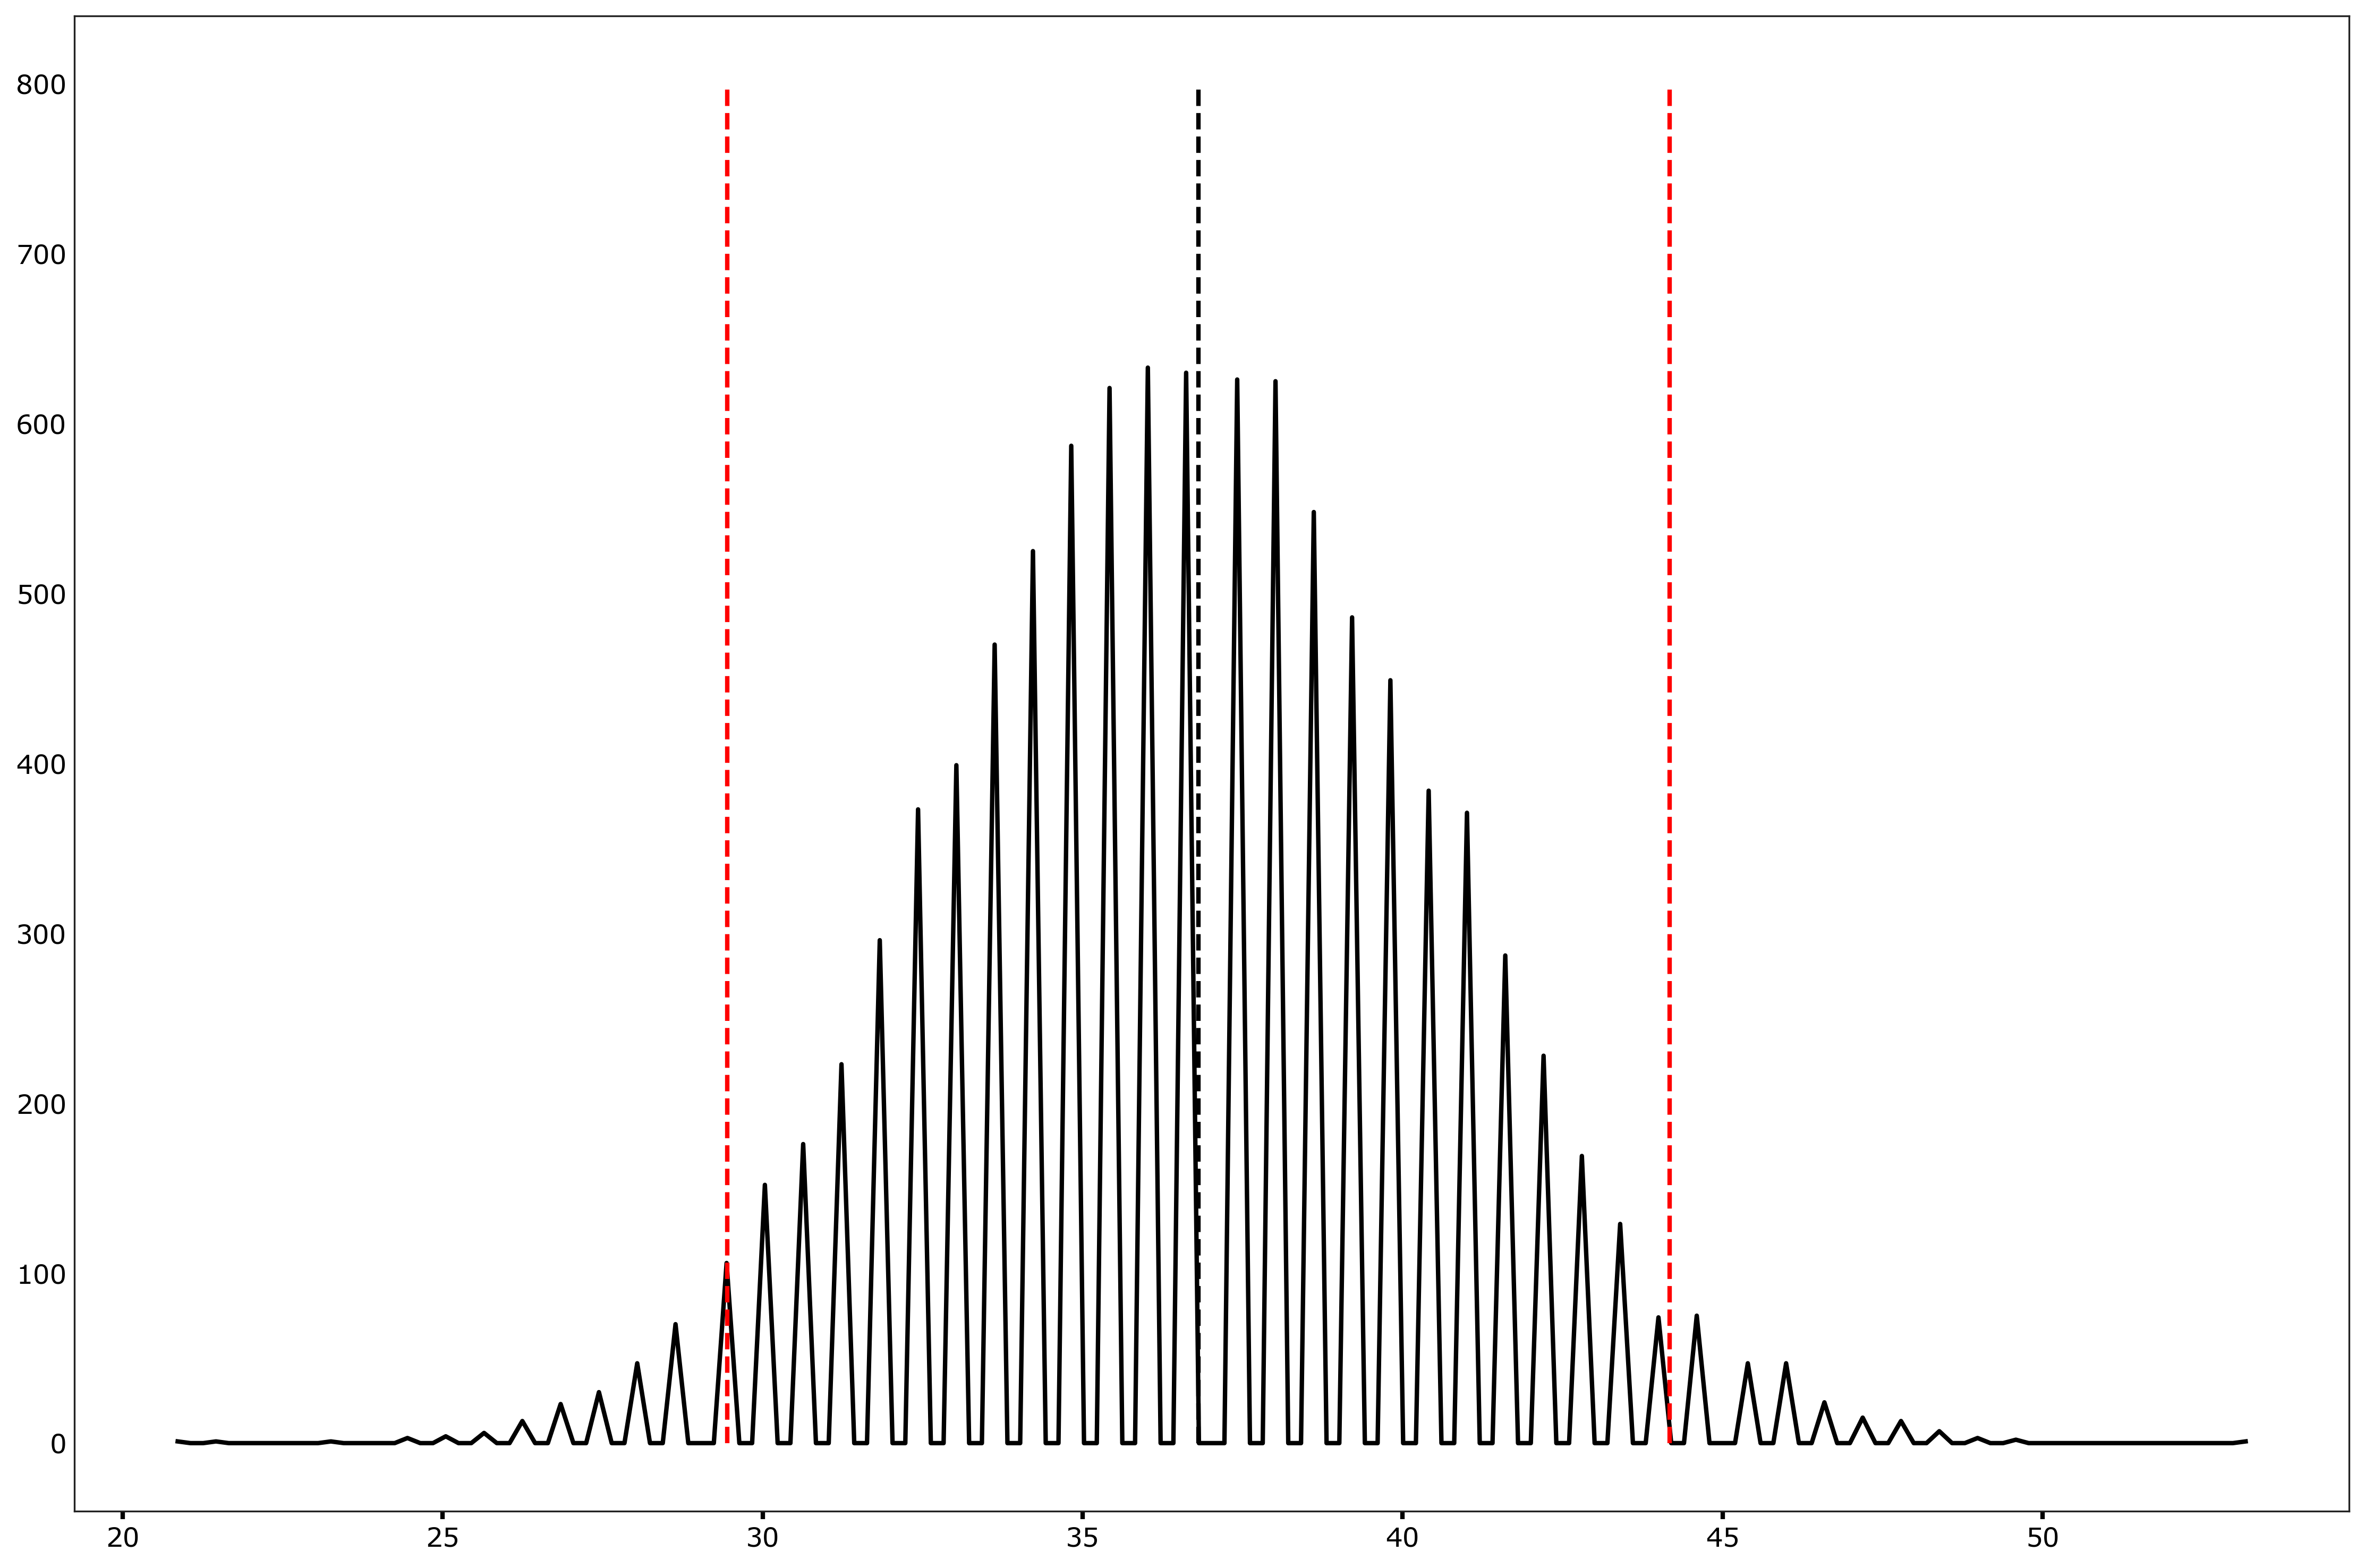

In [244]:
plt.figure()
h, bins = np.histogram(P_S2-mp,163)
plt.plot(bins[:-1], h, color = 'k')
a1 = np.percentile(P_S2-mp, 2.5)
a2 = np.percentile(P_S2-mp, 100-2.5)
plt.vlines(a1,0,800, 'r', linestyle = '--')
plt.vlines(a2,0,800, 'r', linestyle = '--')
plt.vlines(sample_S_all,0,800,'k', linestyle = '--')
p_val = (len(np.where(P_S2>=sample_S_all)[0]))/(10000)
print(p_val)
print(np.mean(P_S2))

In [229]:
len(np.where(P_N2>=sample_N_all)[0])

0

In [231]:
len(np.where(P_S>=S_occurance)[0])

0

0.0001
64.3626213592233


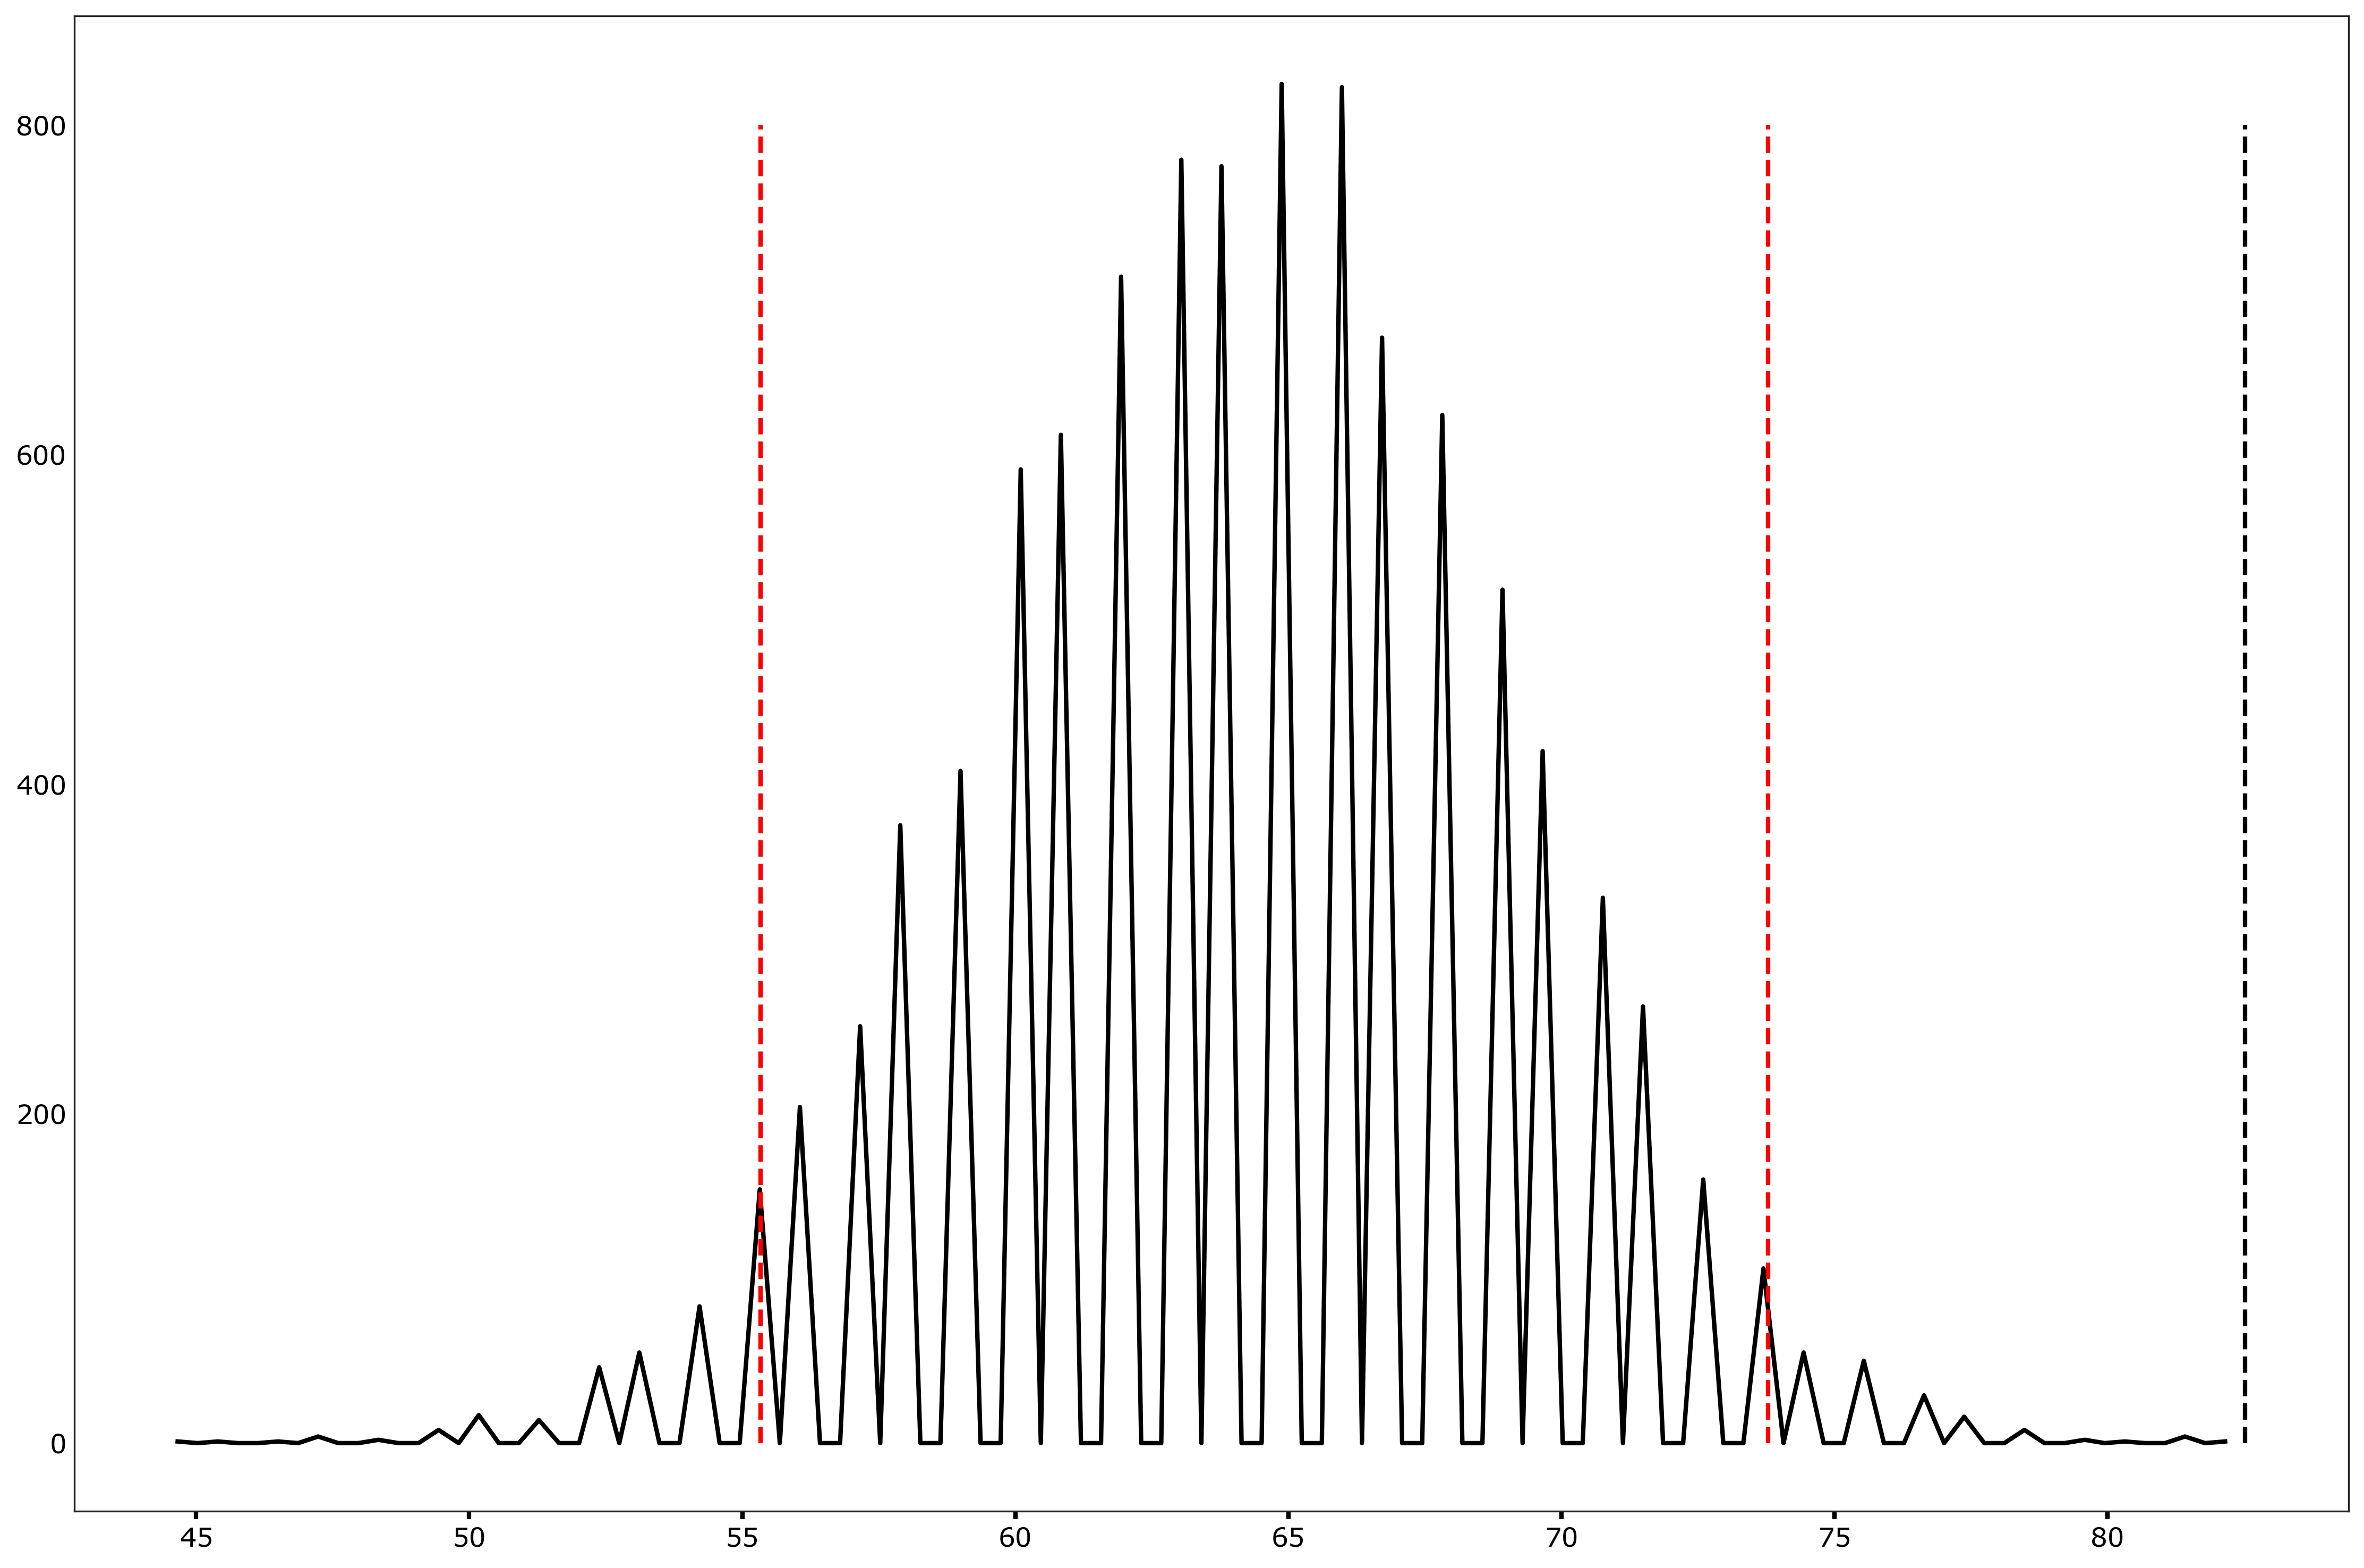

In [232]:
mp = 0
plt.figure()
h, bins = np.histogram(P_N-mp,sample_len_N)
plt.plot(bins[:-1], h, color = 'k')
a1 = np.percentile(P_N-mp, 2.5)
a2 = np.percentile(P_N-mp, 100-2.5)
plt.vlines(a1,0,800, 'r', linestyle = '--')
plt.vlines(a2,0,800, 'r', linestyle = '--')
plt.vlines(N_occurance,0,800,'k', linestyle = '--')
p_val = (len(np.where(P_N>=N_occurance)[0]))/10000
print(p_val)
print(np.mean(P_N))
         
# plt.vlines
# plt.plot((a1,a2),(0,800), '--', color = 'red')

In [178]:
np.where(P_S>=67)

(array([], dtype=int64),)

In [176]:
S_occurance

66.66666666666666

66.66666666666666
0.0
35.6455


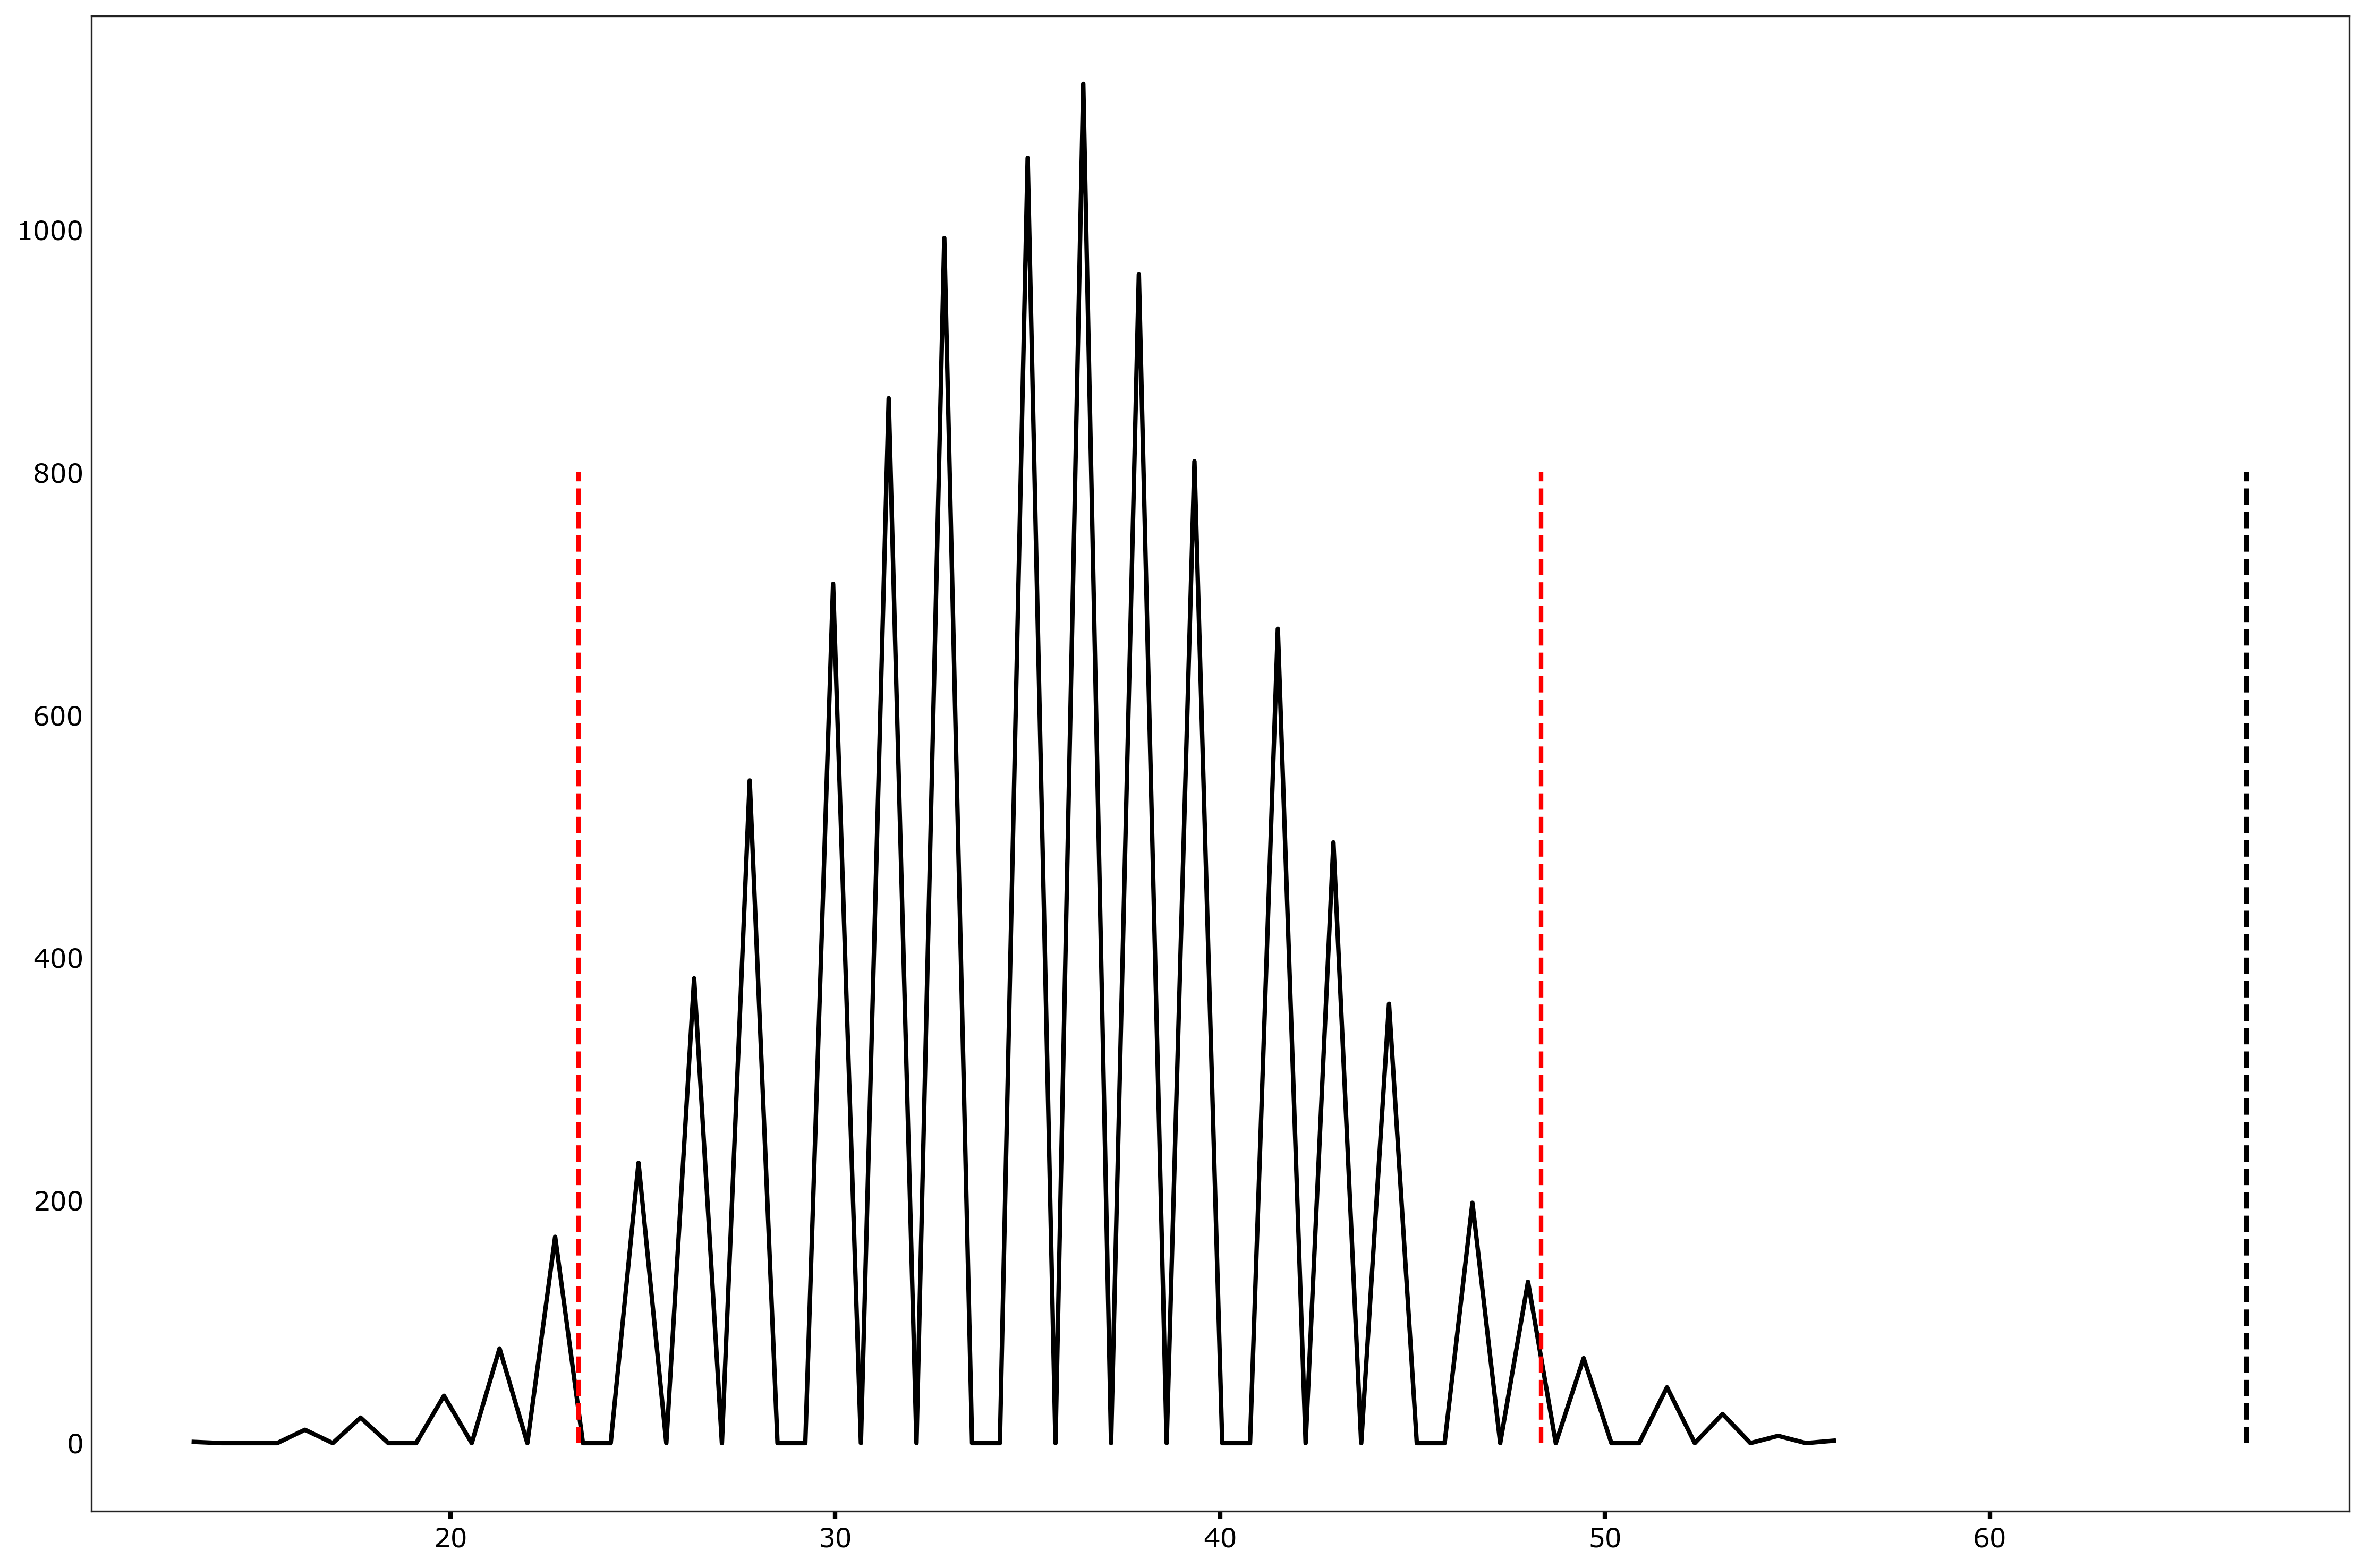

In [234]:
mp = 0
plt.figure()
h, bins = np.histogram(P_S-mp,sample_len_S)
plt.plot(bins[:-1], h, color = 'k')
a1 = np.percentile(P_S-mp, 2.5)
a2 = np.percentile(P_S-mp, 100-2.5)
plt.vlines(a1,0,800, 'r', linestyle = '--')
plt.vlines(a2,0,800, 'r', linestyle = '--')
print(S_occurance)
plt.vlines(S_occurance,0,800,'k', linestyle = '--')
p_val = (len(np.where(P_S>=S_occurance)[0]))/(len(P_S))
print(p_val)
print(np.mean(P_S))

In [245]:
# np.where(P_S>=S_occurance)

(array([], dtype=int64),)

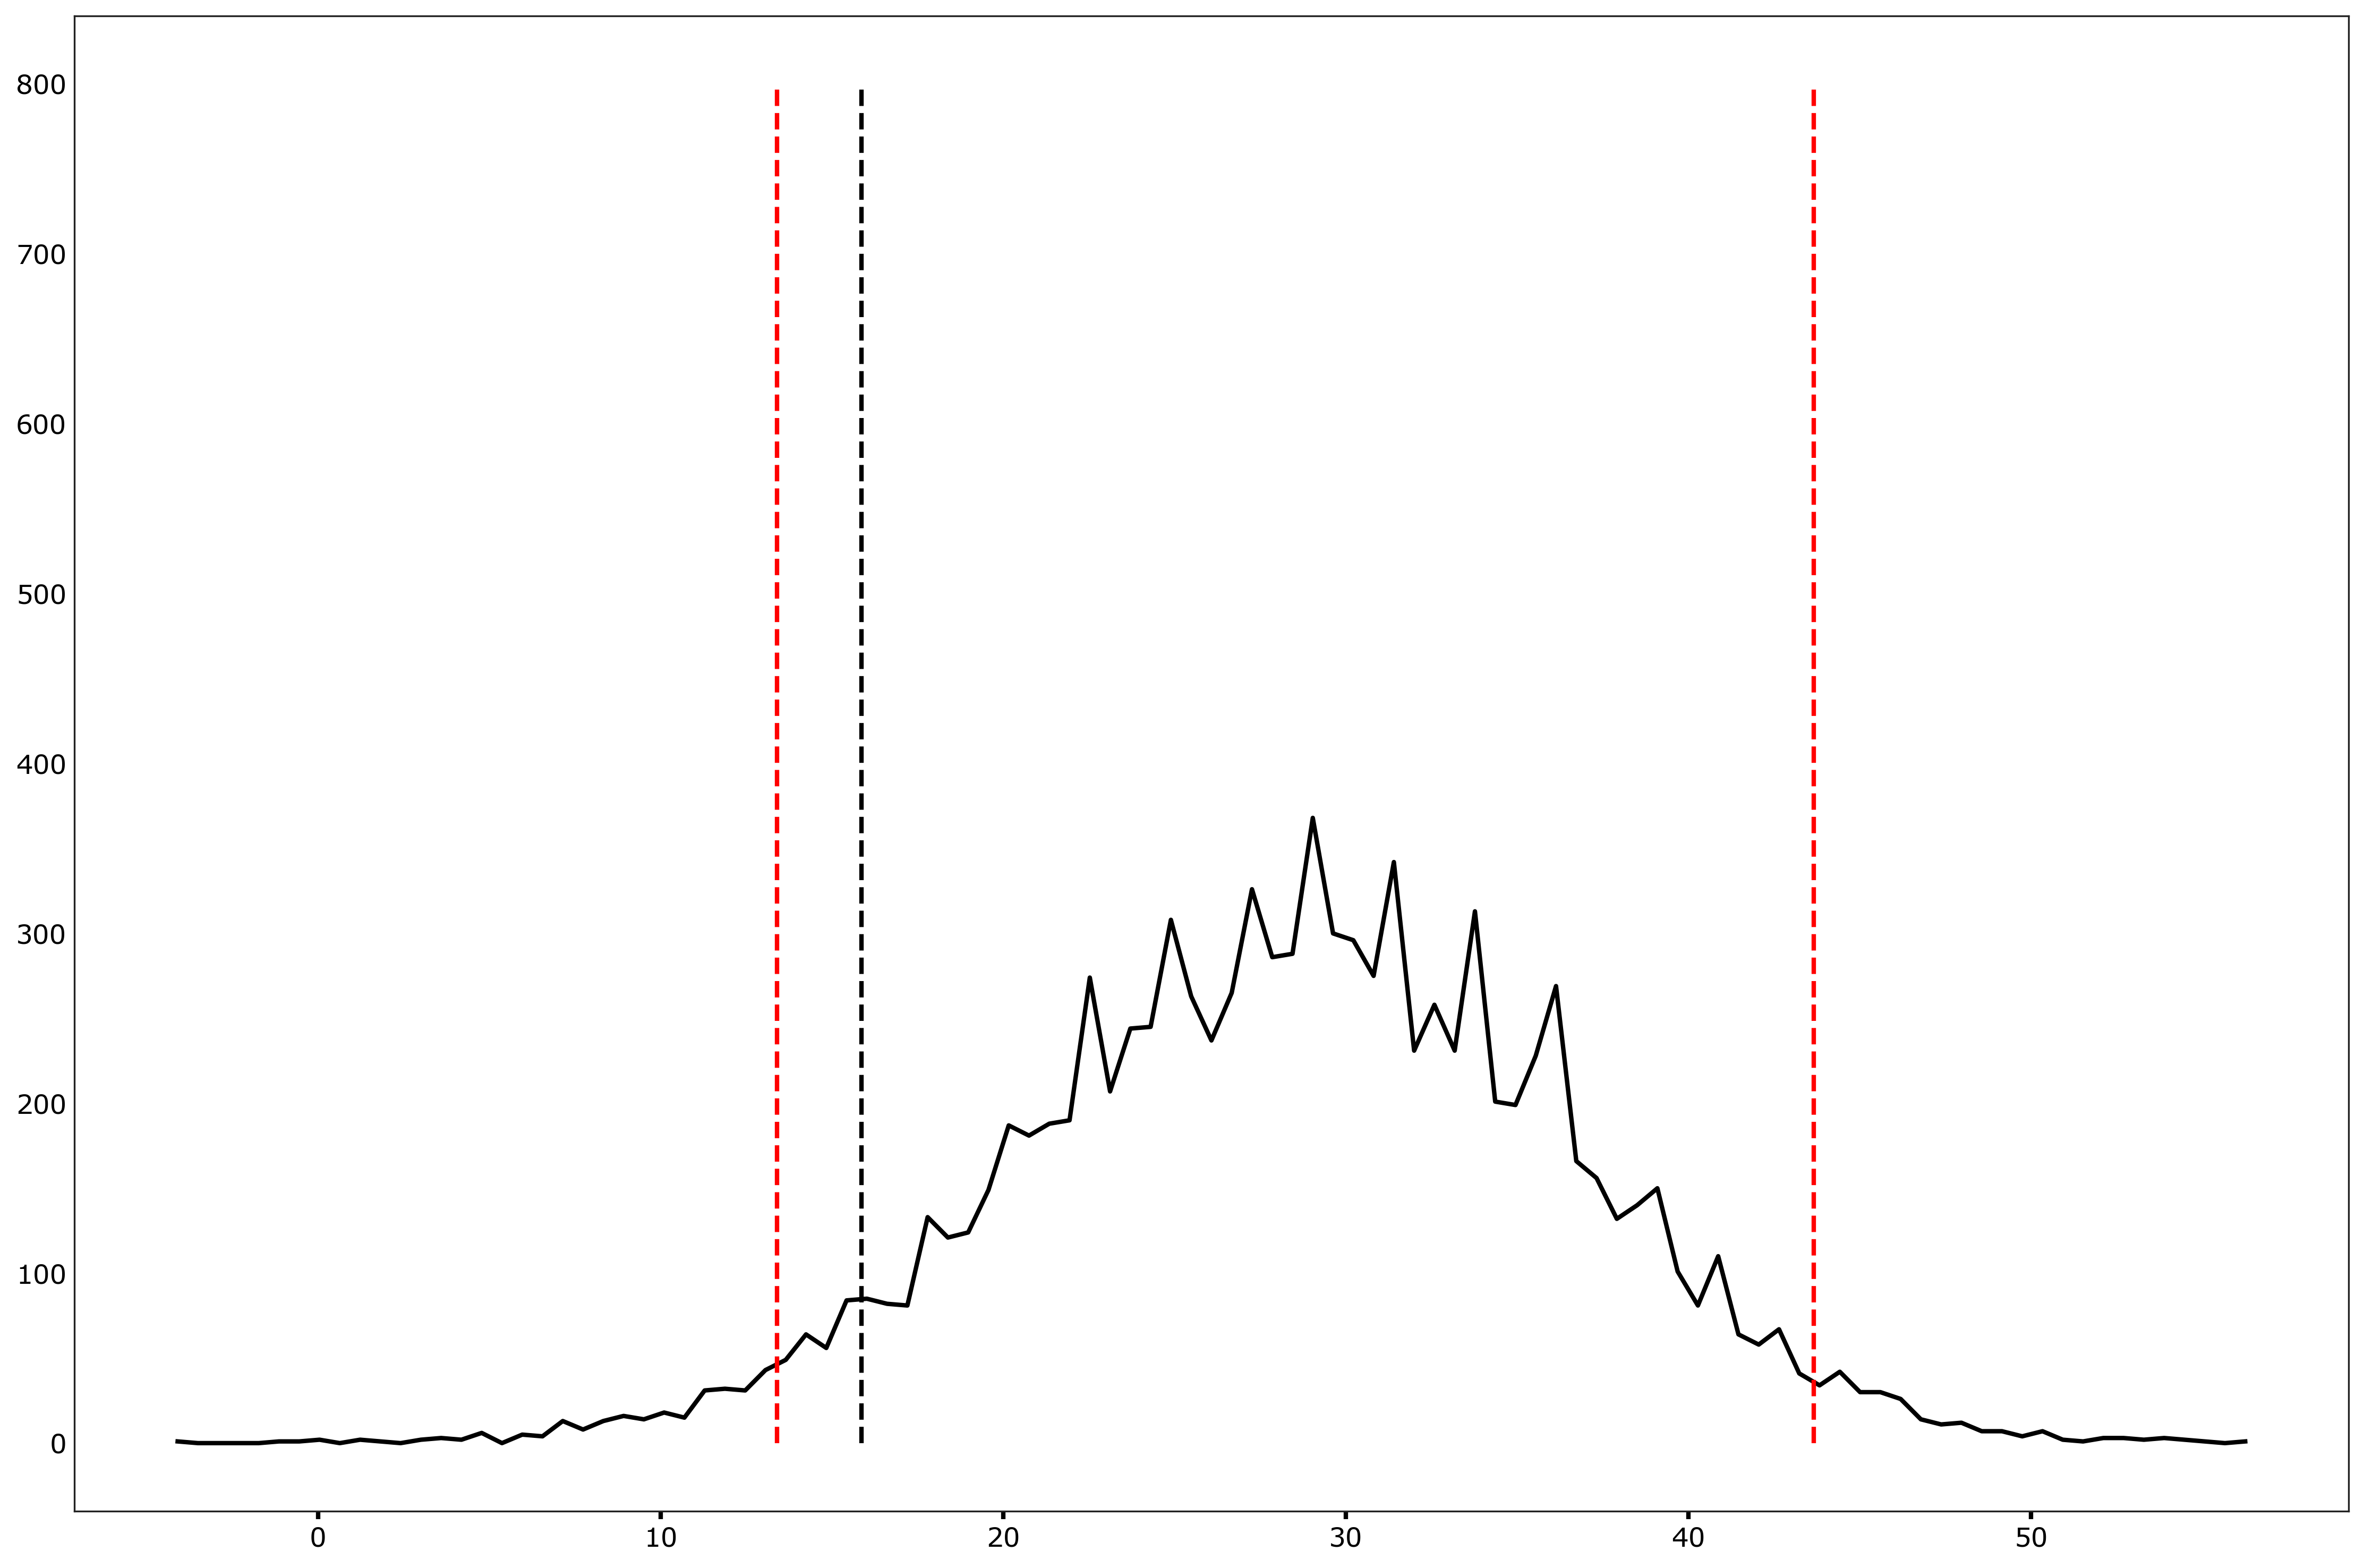

In [173]:
mp = 0
plt.figure()
h, bins = np.histogram(P_diff-mp,sample_len_N)
plt.plot(bins[:-1], h, color = 'k')
a1 = np.percentile(P_diff-mp, 2.5)
a2 = np.percentile(P_diff-mp, 100-2.5)
plt.vlines(a1,0,800, 'r', linestyle = '--')
plt.vlines(a2,0,800, 'r', linestyle = '--')
plt.vlines(N_occurance-S_occurance,0,800,'k', linestyle = '--')


In [195]:
np.where(P_S>=S_occurance)

(array([8426]),)

In [201]:
np.argwhere(P_S>=S_occurance)

array([[8426]])

In [197]:
np.mean(P_S)

35.516000000000005

In [192]:
len(P_S)

10000

In [113]:

# sample_len_N = len(post_CP_log2[(post_CP_log2["4cluster_minmax_CPonly_mode1_zonly2_labels"]=="NTCM")])

In [126]:
post_CP_log2.loc[post_CP_log2.delta_time < datetime.timedelta(minutes = 30)]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,index,Date,IOP,Type,Flight,profid,starttime,...,4cluster_minmax_CPonly_mode1_zonly2,4cluster_minmax_CPonly_mode1_zonly2_labels,dT_bins,dT2_bins,dMR_bins,dMR2_bins,dBz_bins,dte_bins,lcl_bins,dT2_bins_c
4,48,48,48,0,2023-05-30,18,ascending,3,0.0,2023-05-30 22:57:27,...,1.0,NTCM,0-3,-1<$\Delta$T<0,-6 - -3,-3<$\Delta$MR<0,20-50,10-20,1500-2000,-1
5,49,49,49,1,2023-05-30,18,ascending,3,1.0,2023-05-30 23:01:31,...,1.0,NTCM,0-3,-1<$\Delta$T<0,-6 - -3,-3<$\Delta$MR<0,20-50,10-20,1500-2000,-1
6,50,50,50,2,2023-05-30,18,ascending,3,2.0,2023-05-30 23:05:28,...,1.0,NTCM,0-3,-5<$\Delta$T<-1,-6 - -3,-3<$\Delta$MR<0,20-50,10-20,1500-2000,-5
7,51,51,51,3,2023-05-30,18,ascending,3,3.0,2023-05-30 23:09:26,...,1.0,NTCM,0-3,-5<$\Delta$T<-1,-6 - -3,-6<$\Delta$MR<-3,20-50,10-20,1500-2000,-5
8,52,52,52,4,2023-05-30,18,ascending,3,4.0,2023-05-30 23:13:31,...,1.0,NTCM,0-3,-5<$\Delta$T<-1,-6 - -3,-6<$\Delta$MR<-3,20-50,10-20,1500-2000,-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,370,370,370,1,2023-06-21,27,ascending,2,1.0,2023-06-21 22:08:20,...,1.0,NTCM,7-15,-5<$\Delta$T<-1,-3 - 0,-3<$\Delta$MR<0,60-80,10-20,750-1000,-5
197,371,371,371,2,2023-06-21,27,ascending,2,2.0,2023-06-21 22:12:24,...,1.0,NTCM,7-15,-10<$\Delta$T<-5,-3 - 0,-3<$\Delta$MR<0,60-80,10-20,750-1000,-10
199,373,373,373,0,2023-06-21,27,descending,2,0.0,2023-06-21 22:06:22,...,1.0,NTCM,7-15,-5<$\Delta$T<-1,-3 - 0,-3<$\Delta$MR<0,60-80,10-20,750-1000,-5
200,374,374,374,1,2023-06-21,27,descending,2,1.0,2023-06-21 22:10:23,...,1.0,NTCM,7-15,-10<$\Delta$T<-5,-3 - 0,-3<$\Delta$MR<0,60-80,10-20,750-1000,-10


In [104]:
len(post_CP_log2.CP_id.unique())

19